# GSE Foreclosure Disposition Analysis — National

**Predicting whether a foreclosed loan will sell at auction (3rd-party sale) or revert to the bank as REO.**

This notebook is the technical pipeline. For full reasoning, methodology justifications, and recommendations, see the companion whitepaper.

## Pipeline structure

| Block | Purpose |
|---|---|
| 0 | Setup, paths, API keys, session recovery |
| 1A / 1B | Resumable Fannie / Freddie ingestion |
| 1C | Combine GSE sources → unified master |
| 1D | Original 10 external data sources (FRED, FHFA, ACS, BLS, Zillow, etc.) |
| 1.5 A–H | 30 extended data sources organized by category |
| Fixes | Targeted patches: Fannie OLTV detector, FRED distress, ZHVF as static |
| Harmonize | Unify Fannie + Freddie column conventions |
| 2 | Core feature engineering |
| 2.5 | Extended feature engineering with zip3-aware joins |
| 3 | EDA |
| 4 | Modeling (LightGBM + Logistic baseline) |
| 5 | SHAP, counterfactual, executive summary |
| A–E | Dollar impact, subgroup performance, calibration, lead-lag, case study |

**Final dataset:** 18,871 GSE liquidations (2016-2024 dispositions), Fannie + Freddie, 57 features.
**Final model:** LightGBM, ROC-AUC 0.8008 (random split), 0.7365 (time-aware).


## Block 0 — Environment Setup

Installs dependencies, mounts Google Drive, sets up paths, loads API keys for FRED and Census.

In [2]:
# --- Install required packages ---
!pip install -q fredapi census us pygris lightgbm shap requests-cache tqdm \
    pandas numpy scikit-learn matplotlib seaborn pyarrow

# --- Standard imports ---
import os, sys, json, time, zipfile, io, re, warnings, pathlib
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# --- Mount Google Drive for persistent storage ---
from google.colab import drive
drive.mount('/content/drive')

# --- Set up project directory structure on Drive ---
PROJECT_ROOT = '/content/drive/MyDrive/ServiceLink_Foreclosure_Analysis'
RAW_DIR      = f'{PROJECT_ROOT}/raw'
PROCESSED    = f'{PROJECT_ROOT}/processed'
MODELS_DIR   = f'{PROJECT_ROOT}/models'
OUTPUT_DIR   = f'{PROJECT_ROOT}/outputs'
GSE_DIR      = f'{RAW_DIR}/gse_loan_performance'   # put Fannie/Freddie CSVs here

for d in [PROJECT_ROOT, RAW_DIR, PROCESSED, MODELS_DIR, OUTPUT_DIR, GSE_DIR]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

# =============================================================================
# API KEY REGISTRATION GUIDE
# =============================================================================
# You need THREE free registrations. Do these once, then save keys to Drive.
#
# 1) FRED API KEY
#    Go to: https://fred.stlouisfed.org/docs/api/api_key.html
#    Click "Request API Key" (need a free account). Takes ~30 seconds.
#    Paste the key below when prompted.
#
# 2) CENSUS API KEY
#    Go to: https://api.census.gov/data/key_signup.html
#    Fill form, get key emailed in ~1 minute.
#
# 3) Fannie Mae Data Dynamics (for loan performance CSVs)
#    Go to: https://capitalmarkets.fanniemae.com/tools-applications/data-dynamics
#    Click "Register" and create a free account.
#    (We use this manually in Block 1 — no API key needed in code.)
#
# 4) Freddie Mac Single-Family Loan-Level Dataset
#    Go to: https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset
#    Register for free access.
# =============================================================================

KEYS_FILE = f'{PROJECT_ROOT}/api_keys.json'

if os.path.exists(KEYS_FILE):
    with open(KEYS_FILE, 'r') as f:
        keys = json.load(f)
    print("Loaded existing API keys from Drive.")
else:
    keys = {}
    keys['FRED_API_KEY']   = input("Paste your FRED API key: ").strip()
    keys['CENSUS_API_KEY'] = input("Paste your Census API key: ").strip()
    with open(KEYS_FILE, 'w') as f:
        json.dump(keys, f)
    print(f"Saved keys to {KEYS_FILE}")

FRED_API_KEY   = keys['FRED_API_KEY']
CENSUS_API_KEY = keys['CENSUS_API_KEY']

# --- Analysis window ---
ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2024-12-31'  # most free data has a lag; adjust as needed

print(f"\nAnalysis window: {ANALYSIS_START} to {ANALYSIS_END}")
print("Setup complete. Proceed to Block 1.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis
Loaded existing API keys from Drive.

Analysis window: 2016-01-01 to 2024-12-31
Setup complete. Proceed to Block 1.


### Session recovery

Reloads cached parquets after a Colab runtime restart. Skip if running for the first time.

In [3]:
# =============================================================================
# SESSION RECOVERY — rebuild state from cached parquets
# =============================================================================
# Run this after a Colab restart to get back to where you were.
# No downloads; just reads from Drive caches.
# =============================================================================

import os, io, re, time, gc, shutil, zipfile, json, pathlib
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
fred = Fred(api_key=FRED_API_KEY)

print("Reloading cached parquets...")

# Block 1C output
gse_data = pd.read_parquet(f'{PROCESSED}/gse_foreclosures.parquet')
print(f"  gse_data: {gse_data.shape}")

# Block 1D outputs
fred_df    = pd.read_parquet(f'{PROCESSED}/fred_series.parquet')
fhfa_df    = pd.read_parquet(f'{PROCESSED}/fhfa_hpi.parquet')
acs_df     = pd.read_parquet(f'{PROCESSED}/acs_zcta_2022.parquet')
bls_df     = pd.read_parquet(f'{PROCESSED}/bls_laus_county.parquet')
zillow_df  = pd.read_parquet(f'{PROCESSED}/zillow_zip.parquet')
state_channel_map = pd.read_parquet(f'{PROCESSED}/state_channel_map.parquet')
fema_df = pd.DataFrame()      # was empty in Block 1D
hmda_df = pd.DataFrame()      # was empty
hud_reo_df = pd.DataFrame()   # was empty
print(f"  fred_df: {fred_df.shape}")
print(f"  fhfa_df: {fhfa_df.shape}")
print(f"  acs_df: {acs_df.shape}")
print(f"  bls_df: {bls_df.shape}")
print(f"  zillow_df: {zillow_df.shape}")

# Block 1.5A outputs (if cached)
zori_df = pd.read_parquet(f'{PROCESSED}/zillow_zori_zip.parquet') if os.path.exists(f'{PROCESSED}/zillow_zori_zip.parquet') else pd.DataFrame()
zhvf_df = pd.read_parquet(f'{PROCESSED}/zillow_zhvf_zip.parquet') if os.path.exists(f'{PROCESSED}/zillow_zhvf_zip.parquet') else pd.DataFrame()
print(f"  zori_df: {zori_df.shape}")
print(f"  zhvf_df: {zhvf_df.shape}")

# Block 1.5B outputs
realtor_df     = pd.read_parquet(f'{PROCESSED}/realtor_inventory_metro.parquet')
fred_supply_df = pd.read_parquet(f'{PROCESSED}/fred_supply.parquet')
print(f"  realtor_df: {realtor_df.shape}")
print(f"  fred_supply_df: {fred_supply_df.shape}")

# Block 1.5C outputs
fred_buyer_df = pd.read_parquet(f'{PROCESSED}/fred_buyer.parquet')
print(f"  fred_buyer_df: {fred_buyer_df.shape}")

print("\n✓ Session recovered. You can now continue with 1.5D (corrected version below).")
gc.collect()

Reloading cached parquets...
  gse_data: (19691, 74)
  fred_df: (562, 9)
  fhfa_df: (2040, 3)
  acs_df: (33774, 9)
  bls_df: (418681, 5)
  zillow_df: (3232809, 4)
  zori_df: (417246, 3)
  zhvf_df: (60413, 3)
  realtor_df: (108225, 6)
  fred_supply_df: (108, 6)
  fred_buyer_df: (108, 4)

✓ Session recovered. You can now continue with 1.5D (corrected version below).


0

## Block 1A — Fannie Mae Ingestion (Resumable)

Reads each Fannie quarterly ZIP, detects column positions by content pattern, filters to liquidation events (ZBC 02 = sold, 09 = REO). Each file caches independently so reruns after disconnects pick up where they stopped.

In [9]:
# =============================================================================
# BLOCK 1A: FANNIE MAE INGESTION (RESUMABLE, MEMORY-SAFE)
# =============================================================================
# Processes each Fannie quarterly ZIP independently → its own parquet cache.
# Safe to re-run anytime. Already-cached files are skipped.
# =============================================================================

from fredapi import Fred
fred = Fred(api_key=FRED_API_KEY)

import gc, shutil, time

# -----------------------------------------------------------------------------
# Cache paths (Fannie-specific subdirectory)
# -----------------------------------------------------------------------------
FANNIE_CACHE_DIR = f'{PROCESSED}/gse_per_file/fannie'
os.makedirs(FANNIE_CACHE_DIR, exist_ok=True)

SCRATCH_DIR = '/tmp/gse_scratch'
os.makedirs(SCRATCH_DIR, exist_ok=True)


def detect_fannie_columns(sample_df):
    """Identify Fannie columns by content pattern — handles schema drift across years."""
    import re as _re
    detected = {}
    n_cols = sample_df.shape[1]

    US_STATES_RE = _re.compile(
        r'^(AL|AK|AZ|AR|CA|CO|CT|DE|DC|FL|GA|HI|ID|IL|IN|IA|KS|KY|LA|ME|MD|MA|'
        r'MI|MN|MS|MO|MT|NE|NV|NH|NJ|NM|NY|NC|ND|OH|OK|OR|PA|RI|SC|SD|TN|TX|'
        r'UT|VT|VA|WA|WV|WI|WY|PR|VI|GU|AS|MP)$')

    # Pass 1: categorical detection
    for i in range(n_cols):
        col = sample_df.iloc[:, i].dropna().astype(str)
        if len(col) == 0:
            continue
        sample = col.head(5000)

        zbc_vals = {'01','02','03','06','09','15','16'}
        if (sample.str.match(r'^\d{1,2}$').mean() > 0.9 and
            sample.isin(zbc_vals).mean() > 0.3 and
            'Zero_Bal_Code' not in detected):
            detected['Zero_Bal_Code'] = i
            continue
        if (sample.str.match(r'^\d{10,12}$').mean() > 0.95 and 'LOAN_ID' not in detected):
            detected['LOAN_ID'] = i
            continue
        if (sample.str.match(US_STATES_RE).mean() > 0.9 and 'STATE' not in detected):
            detected['STATE'] = i
            continue
        if (sample.isin(['P','S','I','U','2']).mean() > 0.95 and 'OCC_STAT' not in detected):
            detected['OCC_STAT'] = i
            continue
        if (sample.isin(['SF','CO','CP','MH','PU','LH']).mean() > 0.9 and 'PROP' not in detected):
            detected['PROP'] = i
            continue
        if (sample.str.match(r'^\d{3}$|^\d{5}$').mean() > 0.9 and 'ZIP' not in detected):
            detected['ZIP'] = i
            continue
        # MSA is a 5-digit numeric code
        if (sample.str.match(r'^\d{5}$').mean() > 0.85 and
            'ZIP' in detected and
            'MSA' not in detected and
            sample.astype(float).between(10000, 99999).mean() > 0.9):
            # Only accept if it's genuinely different from ZIP
            if i != detected.get('ZIP'):
                detected['MSA'] = i
                continue

    # Pass 2: MMYYYY dates positionally
    mmyyyy_re = _re.compile(r'^(0[1-9]|1[0-2])\d{4}$')
    date_positions = []
    for i in range(n_cols):
        if i in detected.values():
            continue
        col = sample_df.iloc[:, i].dropna().astype(str).head(5000)
        if len(col) > 0 and col.str.match(mmyyyy_re).mean() > 0.85:
            date_positions.append(i)

    date_slots = ['ACT_PERIOD','ORIG_DATE','FIRST_PAY','MATR_DT',
                  'ZB_DTE','LAST_PAID_INSTALLMENT_DATE',
                  'FORECLOSURE_DATE','DISPOSITION_DATE']
    for slot, pos in zip(date_slots, date_positions):
        detected[slot] = pos

    # Pass 3: numeric columns by value range
    for i in range(n_cols):
        if i in detected.values():
            continue
        num = pd.to_numeric(sample_df.iloc[:, i], errors='coerce')
        n_valid = num.notna().sum()
        if n_valid < 100:
            continue
        if ('ORIG_UPB' not in detected and
            num.between(50_000, 2_500_000).mean() > 0.85 and
            n_valid / len(sample_df) > 0.9):
            detected['ORIG_UPB'] = i
            continue
        if ('ORIG_RATE' not in detected and
            num.between(0.5, 15.0).mean() > 0.85 and
            n_valid / len(sample_df) > 0.9):
            detected['ORIG_RATE'] = i
            continue
        if ('OLTV' not in detected and
            num.between(1, 100).mean() > 0.85 and
            n_valid / len(sample_df) > 0.5):
            detected['OLTV'] = i
            continue
        if ('DTI' not in detected and 'OLTV' in detected and
            num.between(1, 65).mean() > 0.85 and
            n_valid / len(sample_df) > 0.5):
            detected['DTI'] = i
            continue
        if ('CSCORE_B' not in detected and
            num.between(300, 850).mean() > 0.85 and
            n_valid / len(sample_df) > 0.7):
            detected['CSCORE_B'] = i
            continue

    # LAST_UPB right after Zero_Bal_Code
    if 'Zero_Bal_Code' in detected:
        zbc_pos = detected['Zero_Bal_Code']
        for i in range(zbc_pos + 1, min(zbc_pos + 8, n_cols)):
            if i in detected.values():
                continue
            num = pd.to_numeric(sample_df.iloc[:, i], errors='coerce')
            if (num.between(0, 2_500_000).mean() > 0.5 and
                num.notna().sum() > 50 and
                'LAST_UPB' not in detected):
                detected['LAST_UPB'] = i
                break

    # NET_SALES_PROCEEDS after LAST_UPB
    if 'LAST_UPB' in detected:
        start = detected['LAST_UPB'] + 1
        for i in range(start, min(start + 15, n_cols)):
            if i in detected.values():
                continue
            num = pd.to_numeric(sample_df.iloc[:, i], errors='coerce')
            if (num.between(0, 2_500_000).mean() > 0.3 and
                num.notna().sum() > 20 and
                'NET_SALES_PROCEEDS' not in detected):
                detected['NET_SALES_PROCEEDS'] = i
                break

    if 'NET_SALES_PROCEEDS' in detected:
        start = detected['NET_SALES_PROCEEDS'] + 1
        for i in range(start, min(start + 10, n_cols)):
            if i in detected.values():
                continue
            num = pd.to_numeric(sample_df.iloc[:, i], errors='coerce')
            if num.notna().sum() > 10:
                if 'CREDIT_ENHANCEMENT_PROCEEDS' not in detected:
                    detected['CREDIT_ENHANCEMENT_PROCEEDS'] = i
                elif 'FORECLOSURE_COSTS' not in detected:
                    detected['FORECLOSURE_COSTS'] = i
                    break

    # MI type
    for i in range(n_cols):
        if i in detected.values():
            continue
        col = sample_df.iloc[:, i].dropna().astype(str).head(2000)
        if (col.str.match(r'^\d$').mean() > 0.8 and
            col.isin(['0','1','2','3']).mean() > 0.9 and
            'MORTGAGE_INSURANCE_TYPE' not in detected):
            detected['MORTGAGE_INSURANCE_TYPE'] = i
            break

    return detected


def load_fannie_quarter_to_parquet(zip_path, output_parquet):
    """Load one Fannie quarter → parquet. Streams in chunks, filters to liquidations only."""
    with zipfile.ZipFile(zip_path) as z:
        csv_name = [n for n in z.namelist()
                    if n.endswith('.csv') or n.endswith('.txt')][0]

        with z.open(csv_name) as f:
            first_line = f.readline().decode('utf-8', errors='replace').rstrip('\n')
        n_fields = len(first_line.split('|'))

        positional_names = [f'col_{i:03d}' for i in range(n_fields)]
        with z.open(csv_name) as f:
            sample = pd.read_csv(
                f, sep='|', names=positional_names, header=None,
                nrows=500_000, low_memory=False, dtype=str,
                on_bad_lines='skip',
            )

        detected = detect_fannie_columns(sample)
        del sample
        gc.collect()

        if 'Zero_Bal_Code' not in detected:
            print(f"    ⚠ Could not detect Zero_Bal_Code in {os.path.basename(zip_path)}")
            return 0

        pos_to_name = {v: k for k, v in detected.items()}
        final_col_names = [pos_to_name.get(i, f'col_{i:03d}') for i in range(n_fields)]
        keep_cols = list(detected.keys())

        chunks = []
        with z.open(csv_name) as f:
            reader = pd.read_csv(
                f, sep='|', names=final_col_names, header=None,
                usecols=keep_cols, chunksize=500_000,
                low_memory=False, dtype=str, on_bad_lines='skip',
            )
            for chunk in reader:
                chunk = chunk[chunk['Zero_Bal_Code'].isin(['02','09'])]
                if len(chunk) > 0:
                    chunks.append(chunk)

        if not chunks:
            return 0

        result = pd.concat(chunks, ignore_index=True)
        del chunks
        gc.collect()

        result['SOURCE'] = 'fannie'
        result['VINTAGE'] = os.path.basename(zip_path).replace('.zip','')
        result.to_parquet(output_parquet, index=False)
        n_rows = len(result)
        del result
        gc.collect()
        return n_rows


def ingest_fannie_resumable():
    """Process all Fannie ZIPs in GSE_DIR. Skip already-cached files. Safe to rerun."""
    fannie_zips = sorted([
        f for f in os.listdir(GSE_DIR)
        if f.endswith('.zip') and not f.lower().startswith('freddie')
    ])
    if not fannie_zips:
        print("⚠ No Fannie ZIPs found.")
        return

    print(f"Fannie ingestion — {len(fannie_zips)} files to check")
    print(f"Cache dir: {FANNIE_CACHE_DIR}\n")

    for idx, zf in enumerate(fannie_zips):
        per_file_cache = f'{FANNIE_CACHE_DIR}/{zf.replace(".zip",".parquet")}'
        if os.path.exists(per_file_cache):
            try:
                cached = pd.read_parquet(per_file_cache)
                print(f"[{idx+1:>2}/{len(fannie_zips)}] ✓ SKIP {zf:<30} ({len(cached):>7,} rows cached)")
                del cached
                continue
            except Exception as e:
                print(f"[{idx+1:>2}/{len(fannie_zips)}] ⚠ Stale cache, reprocessing: {e}")
                os.remove(per_file_cache)

        src_path = os.path.join(GSE_DIR, zf)
        size_gb = os.path.getsize(src_path) / (1024**3)

        # Copy to fast local disk for processing
        scratch_path = os.path.join(SCRATCH_DIR, zf)
        try:
            t_copy = time.time()
            shutil.copy2(src_path, scratch_path)
            print(f"[{idx+1:>2}/{len(fannie_zips)}] ⇣ {zf:<30} ({size_gb:.1f}GB, copy {time.time()-t_copy:.0f}s)", flush=True)
        except Exception as e:
            print(f"[{idx+1:>2}/{len(fannie_zips)}] ⚠ Copy failed: {e}. Using Drive direct.")
            scratch_path = src_path

        try:
            t0 = time.time()
            n_rows = load_fannie_quarter_to_parquet(scratch_path, per_file_cache)
            print(f"[{idx+1:>2}/{len(fannie_zips)}] ✓ {zf:<30} → {n_rows:>7,} liquidations ({time.time()-t0:.0f}s)")
        except Exception as e:
            print(f"[{idx+1:>2}/{len(fannie_zips)}] ✗ ERROR on {zf}: {e}")

        if scratch_path != src_path and os.path.exists(scratch_path):
            os.remove(scratch_path)
        gc.collect()

    print("\nFannie ingestion complete. Run Block 1B next.")


# Execute
ingest_fannie_resumable()

Fannie ingestion — 39 files to check
Cache dir: /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis/processed/gse_per_file/fannie

[ 1/39] ✓ SKIP 2016Q1.zip                     (    564 rows cached)
[ 2/39] ✓ SKIP 2016Q2.zip                     (    625 rows cached)
[ 3/39] ✓ SKIP 2016Q3.zip                     (    706 rows cached)
[ 4/39] ✓ SKIP 2016Q4.zip                     (    670 rows cached)
[ 5/39] ✓ SKIP 2017Q1.zip                     (    610 rows cached)
[ 6/39] ✓ SKIP 2017Q2.zip                     (    683 rows cached)
[ 7/39] ✓ SKIP 2017Q3.zip                     (    814 rows cached)
[ 8/39] ✓ SKIP 2017Q4.zip                     (    721 rows cached)
[ 9/39] ✓ SKIP 2018Q1.zip                     (    698 rows cached)
[10/39] ✓ SKIP 2018Q2.zip                     (    669 rows cached)
[11/39] ✓ SKIP 2018Q3.zip                     (    715 rows cached)
[12/39] ✓ SKIP 2018Q4.zip                     (    553 rows cached)
[13/39] ✓ SKIP 2019Q1.zip                     (  

### Fix 1 — Re-read Fannie OLTV from raw ZIPs

Block 1A's content-based detector misidentified Fannie's OLTV column as the interest rate column (values 2-8) instead of LTV (values 15-97). This patches the per-file caches by re-reading just the correct OLTV column and merging it back. Without this, `orig_ltv` coverage is 36% (Freddie only); with it, 100%.

In [10]:
# =============================================================================
# FIX 1: Re-read Fannie OLTV from raw ZIPs
# =============================================================================
# The detector in Block 1A picked up interest rate (values 2-8) instead of
# OLTV (values 15-97) for many Fannie files. We fix this by:
#   1. Opening each Fannie ZIP
#   2. Finding the REAL OLTV column using a stricter detection (values must
#      be whole numbers in 15-97 and median near 75-80)
#   3. Appending a corrected OLTV_FIXED column to the per-file parquet
#
# Skip-logic: if per-file cache already has a 'OLTV_FIXED' column with
# sensible values, skip that file.
# =============================================================================

import gc, shutil, time, zipfile

def detect_fannie_oltv_strictly(zip_path):
    """Open a Fannie ZIP and find the REAL OLTV column.

    Fannie OLTV characteristics:
    - Integer values (no decimals) — this is the key distinguishing feature
    - Range 1-97 with median ~75-80 (typical conforming loans)
    - High coverage (>85% of rows)
    - Position is AFTER ORIG_RATE in the schema

    Returns: column position (int) or None if not found
    """
    with zipfile.ZipFile(zip_path) as z:
        csv_name = [n for n in z.namelist()
                    if n.endswith('.csv') or n.endswith('.txt')][0]

        # Sample first 200k rows
        with z.open(csv_name) as f:
            first_line = f.readline().decode('utf-8', errors='replace').rstrip('\n')
        n_fields = len(first_line.split('|'))

        with z.open(csv_name) as f:
            sample = pd.read_csv(
                f, sep='|', header=None,
                names=[f'col_{i:03d}' for i in range(n_fields)],
                nrows=200_000, low_memory=False, dtype=str,
                on_bad_lines='skip',
            )

    best_candidate = None
    best_score = 0

    for i in range(n_fields):
        col_raw = sample.iloc[:, i]
        num = pd.to_numeric(col_raw, errors='coerce')
        n_valid = num.notna().sum()

        if n_valid < 10_000:  # Need reasonable coverage
            continue

        # KEY CHECK: OLTV values should be whole numbers
        # Interest rates have fractional values like 4.375, 3.99
        # LTVs are stored as integers like 75, 80, 95

        # Only look at non-null values
        valid_values = num.dropna()

        # Percentage of values that are whole numbers (no fractional part)
        whole_number_pct = (valid_values == valid_values.round()).mean()

        # Percentage in OLTV range (1-97)
        in_ltv_range_pct = valid_values.between(1, 97).mean()

        # Median should be around 75-85 for typical portfolios
        median_val = valid_values.median()
        median_in_range = 60 <= median_val <= 90

        if (whole_number_pct > 0.95 and
            in_ltv_range_pct > 0.95 and
            median_in_range):
            # Score this candidate
            coverage = n_valid / len(sample)
            score = coverage * in_ltv_range_pct
            if score > best_score:
                best_score = score
                best_candidate = i

    return best_candidate


def reload_fannie_oltv(zip_path, per_file_cache):
    """Read the correct OLTV column from a Fannie ZIP and merge into its cache."""
    # Detect correct OLTV position
    oltv_pos = detect_fannie_oltv_strictly(zip_path)
    if oltv_pos is None:
        print(f"    ⚠ Could not find real OLTV in {os.path.basename(zip_path)}")
        return False

    # Read the ZIP, keeping LOAN_ID + OLTV columns
    with zipfile.ZipFile(zip_path) as z:
        csv_name = [n for n in z.namelist()
                    if n.endswith('.csv') or n.endswith('.txt')][0]
        with z.open(csv_name) as f:
            first_line = f.readline().decode('utf-8', errors='replace').rstrip('\n')
        n_fields = len(first_line.split('|'))

        # Need to also grab LOAN_ID - detect its position from the existing cache
        cache_df = pd.read_parquet(per_file_cache)
        if 'LOAN_ID' not in cache_df.columns:
            return False

        # Read the detected OLTV column + scan for LOAN_ID column
        positional_names = [f'col_{i:03d}' for i in range(n_fields)]
        with z.open(csv_name) as f:
            sample = pd.read_csv(f, sep='|', names=positional_names,
                                 header=None, nrows=5000, low_memory=False,
                                 dtype=str, on_bad_lines='skip')

        # Find LOAN_ID by 10-12 digit pattern
        loan_id_pos = None
        for i in range(n_fields):
            col = sample.iloc[:, i].dropna().astype(str).head(2000)
            if col.str.match(r'^\d{10,12}$').mean() > 0.95:
                loan_id_pos = i
                break

        if loan_id_pos is None:
            print(f"    ⚠ Couldn't find LOAN_ID position in {os.path.basename(zip_path)}")
            return False

        # Stream through the file, keep only LOAN_ID + OLTV, filter to loans in cache
        cache_loan_ids = set(cache_df['LOAN_ID'].astype(str))
        keep_cols_pos = [loan_id_pos, oltv_pos]
        keep_names = ['LOAN_ID_raw', 'OLTV_FIXED']
        col_name_map = {positional_names[loan_id_pos]: 'LOAN_ID_raw',
                        positional_names[oltv_pos]: 'OLTV_FIXED'}

        chunks = []
        with z.open(csv_name) as f:
            for chunk in pd.read_csv(f, sep='|', names=positional_names,
                                     header=None, usecols=[positional_names[p] for p in keep_cols_pos],
                                     chunksize=500_000, low_memory=False,
                                     dtype=str, on_bad_lines='skip'):
                chunk = chunk.rename(columns=col_name_map)
                # Filter to only loans in our liquidations cache
                chunk = chunk[chunk['LOAN_ID_raw'].isin(cache_loan_ids)]
                if len(chunk) > 0:
                    chunks.append(chunk)

        if not chunks:
            print(f"    ⚠ No matching LOAN_IDs found")
            return False

        oltv_df = pd.concat(chunks, ignore_index=True)
        oltv_df['OLTV_FIXED'] = pd.to_numeric(oltv_df['OLTV_FIXED'], errors='coerce')
        oltv_df = oltv_df.rename(columns={'LOAN_ID_raw': 'LOAN_ID'})
        oltv_df = oltv_df.drop_duplicates('LOAN_ID')

    # Merge fixed OLTV into cache, replacing the old bad OLTV column
    cache_df = cache_df.drop(columns=['OLTV'], errors='ignore')
    cache_df = cache_df.merge(oltv_df[['LOAN_ID','OLTV_FIXED']], on='LOAN_ID', how='left')
    cache_df = cache_df.rename(columns={'OLTV_FIXED': 'OLTV'})

    # Write back
    cache_df.to_parquet(per_file_cache, index=False)

    valid_oltv = cache_df['OLTV'].between(15, 97).sum()
    return valid_oltv


print("="*78)
print("FIX 1: Re-reading Fannie OLTV from raw ZIPs")
print("="*78)

FANNIE_CACHE_DIR = f'{PROCESSED}/gse_per_file/fannie'
SCRATCH_DIR = '/tmp/gse_scratch'
os.makedirs(SCRATCH_DIR, exist_ok=True)

fannie_zips = sorted([f for f in os.listdir(GSE_DIR)
                      if f.endswith('.zip') and not f.lower().startswith('freddie')])

for idx, zf in enumerate(fannie_zips):
    cache_path = f'{FANNIE_CACHE_DIR}/{zf.replace(".zip",".parquet")}'
    if not os.path.exists(cache_path):
        continue

    # Skip if OLTV already looks healthy
    existing = pd.read_parquet(cache_path)
    if 'OLTV' in existing.columns:
        oltv_num = pd.to_numeric(existing['OLTV'], errors='coerce')
        in_ltv_range = oltv_num.between(15, 97).mean() if oltv_num.notna().sum() > 0 else 0
        if in_ltv_range > 0.80:
            print(f"[{idx+1:>2}/{len(fannie_zips)}] ✓ SKIP {zf:<30} (OLTV already good: {in_ltv_range*100:.0f}% in range)")
            continue
    del existing

    src_path = os.path.join(GSE_DIR, zf)
    scratch_path = os.path.join(SCRATCH_DIR, zf)

    try:
        t_copy = time.time()
        shutil.copy2(src_path, scratch_path)
        print(f"[{idx+1:>2}/{len(fannie_zips)}] ⇣ {zf} (copied {time.time()-t_copy:.0f}s)", flush=True)
    except Exception as e:
        scratch_path = src_path

    try:
        t0 = time.time()
        n_valid = reload_fannie_oltv(scratch_path, cache_path)
        if n_valid:
            print(f"[{idx+1:>2}/{len(fannie_zips)}] ✓ {zf}: fixed {n_valid:,} OLTV values ({time.time()-t0:.0f}s)")
        else:
            print(f"[{idx+1:>2}/{len(fannie_zips)}] ✗ {zf}: failed")
    except Exception as e:
        print(f"[{idx+1:>2}/{len(fannie_zips)}] ✗ {zf}: {type(e).__name__}: {e}")

    if scratch_path != src_path and os.path.exists(scratch_path):
        os.remove(scratch_path)
    gc.collect()

print("\nFix 1 complete. Next: re-run Block 1C to rebuild unified master.")

FIX 1: Re-reading Fannie OLTV from raw ZIPs
[ 1/39] ✓ SKIP 2016Q1.zip                     (OLTV already good: 100% in range)
[ 2/39] ✓ SKIP 2016Q2.zip                     (OLTV already good: 100% in range)
[ 3/39] ✓ SKIP 2016Q3.zip                     (OLTV already good: 100% in range)
[ 4/39] ✓ SKIP 2016Q4.zip                     (OLTV already good: 100% in range)
[ 5/39] ✓ SKIP 2017Q1.zip                     (OLTV already good: 100% in range)
[ 6/39] ✓ SKIP 2017Q2.zip                     (OLTV already good: 100% in range)
[ 7/39] ✓ SKIP 2017Q3.zip                     (OLTV already good: 100% in range)
[ 8/39] ✓ SKIP 2017Q4.zip                     (OLTV already good: 100% in range)
[ 9/39] ✓ SKIP 2018Q1.zip                     (OLTV already good: 100% in range)
[10/39] ✓ SKIP 2018Q2.zip                     (OLTV already good: 100% in range)
[11/39] ✓ SKIP 2018Q3.zip                     (OLTV already good: 100% in range)
[12/39] ✓ SKIP 2018Q4.zip                     (OLTV already good:

## Block 1B — Freddie Mac Ingestion (Resumable)

Freddie yearly ZIPs contain 4 nested quarterly ZIPs (or 1 for partial years). Each yearly file is processed independently, validated for archive integrity, and cached.

In [11]:
# =============================================================================
# BLOCK 1B: FREDDIE MAC INGESTION (RESUMABLE, MEMORY-SAFE)
# =============================================================================
# Freddie yearly ZIPs contain 4 nested quarterly ZIPs (historical files)
# or a single quarterly ZIP (for very recent years).
# Each yearly file processed independently → its own parquet cache.
# =============================================================================

FREDDIE_CACHE_DIR = f'{PROCESSED}/gse_per_file/freddie'
os.makedirs(FREDDIE_CACHE_DIR, exist_ok=True)


def load_freddie_from_inner_zip(inner_zip_bytes, quarter_label):
    """Load one quarterly Freddie dataset from bytes of a quarterly ZIP."""
    FREDDIE_ORIG_COLS = ['CSCORE','FIRST_PAY_DT','FIRST_TIME','MATR_DT','MSA',
                         'MI_PCT','NO_UNITS','OCC_STAT','OCLTV','DTI','ORIG_UPB',
                         'OLTV','ORIG_RATE','CHANNEL','PPMT_FLG','PROD_TYPE',
                         'STATE','PROP_TYPE','ZIP','LOAN_ID','PURPOSE','ORIG_TERM',
                         'NUM_BO','SELLER','SERVICER','SUPER_CONFORMING','REFI']
    FREDDIE_PERF_COLS = ['LOAN_ID','ACT_PERIOD','CURRENT_UPB','DLQ_STATUS',
                         'LOAN_AGE','REM_MONTHS','REPCH','MOD_FLAG',
                         'Zero_Bal_Code','ZB_DTE','CURR_RATE','CURR_DEFRRD_UPB',
                         'DDLPI','MI_RECOVERIES','NET_SALES_PROCEEDS',
                         'NON_MI_RECOVERIES','EXPENSES','LEGAL_COSTS',
                         'MAINT_COSTS','TAXES_INS','MISC_EXPENSES','ACTUAL_LOSS',
                         'MOD_COST','STEP_MOD_FLAG','DEF_PAYMENT_MOD','ELTV',
                         'ZB_REMOVAL_UPB','DELINQUENT_ACCRUED_INTEREST',
                         'DISASTER_FLAG','BORROWER_ASSISTANCE_CODE',
                         'MOD_PERCENT','MOD_ESTIMATED_LOSS']

    with zipfile.ZipFile(io.BytesIO(inner_zip_bytes)) as z:
        files = z.namelist()
        perf_files = [f for f in files if 'time' in f.lower()]
        orig_files = [f for f in files if 'time' not in f.lower()
                      and (f.endswith('.txt') or f.endswith('.csv'))]
        if not perf_files or not orig_files:
            return pd.DataFrame()
        perf_name, orig_name = perf_files[0], orig_files[0]

        # Detect ORIG column width
        with z.open(orig_name) as f:
            first_orig_line = f.readline().decode('utf-8', errors='replace').rstrip('\n')
        n_orig = len(first_orig_line.split('|'))
        orig_cols = FREDDIE_ORIG_COLS + [f'EXTRA_{i}' for i in range(max(0, n_orig - len(FREDDIE_ORIG_COLS)))]
        orig_cols = orig_cols[:n_orig]

        with z.open(orig_name) as f:
            df_orig = pd.read_csv(f, sep='|', names=orig_cols, header=None,
                                  low_memory=False, dtype=str, on_bad_lines='skip')

        # Detect PERF column width
        with z.open(perf_name) as f:
            first_perf_line = f.readline().decode('utf-8', errors='replace').rstrip('\n')
        n_perf = len(first_perf_line.split('|'))
        perf_cols = FREDDIE_PERF_COLS + [f'EXTRA_{i}' for i in range(max(0, n_perf - len(FREDDIE_PERF_COLS)))]
        perf_cols = perf_cols[:n_perf]

        # Stream performance file, keeping only liquidation events
        chunks = []
        with z.open(perf_name) as f:
            for chunk in pd.read_csv(f, sep='|', names=perf_cols, header=None,
                                     chunksize=500_000, low_memory=False,
                                     dtype=str, on_bad_lines='skip'):
                if 'Zero_Bal_Code' in chunk.columns:
                    chunk = chunk[chunk['Zero_Bal_Code'].isin(['02','03','09'])]
                if len(chunk) > 0:
                    chunks.append(chunk)
        if not chunks:
            return pd.DataFrame()
        df_perf = pd.concat(chunks, ignore_index=True)

        # Keep latest record per LOAN_ID
        df_perf = df_perf.sort_values('ACT_PERIOD').groupby('LOAN_ID').tail(1)
        merged = df_perf.merge(df_orig, on='LOAN_ID', how='left', suffixes=('','_orig'))
        merged['SOURCE'] = 'freddie'
        merged['VINTAGE'] = quarter_label
        return merged


def load_freddie_yearly_to_parquet(zip_path, output_parquet):
    """Load one Freddie yearly ZIP (possibly nested) → parquet."""
    all_quarters = []
    with zipfile.ZipFile(zip_path) as outer:
        inner_names = outer.namelist()
        nested_zips = [n for n in inner_names if n.lower().endswith('.zip')]
        flat_texts = [n for n in inner_names
                      if n.lower().endswith('.txt') or n.lower().endswith('.csv')]

        if nested_zips:
            # Standard case: yearly ZIP contains 4 quarterly ZIPs
            for nz in nested_zips:
                m = re.search(r'(\d{4}Q[1-4])', nz, re.IGNORECASE)
                q_label = m.group(1).upper() if m else nz.replace('.zip','')
                with outer.open(nz) as inner_f:
                    inner_bytes = inner_f.read()
                df = load_freddie_from_inner_zip(inner_bytes, q_label)
                if len(df) > 0:
                    all_quarters.append(df)
                del inner_bytes
                gc.collect()
        elif flat_texts:
            # Flat case: yearly ZIP contains TXTs directly (some recent partial years)
            m = re.search(r'(\d{4}Q[1-4])', os.path.basename(zip_path), re.IGNORECASE)
            q_label = m.group(1).upper() if m else 'unknown'
            with open(zip_path, 'rb') as f:
                df = load_freddie_from_inner_zip(f.read(), q_label)
            if len(df) > 0:
                all_quarters.append(df)

    if not all_quarters:
        return 0

    result = pd.concat(all_quarters, ignore_index=True)
    del all_quarters
    gc.collect()
    result.to_parquet(output_parquet, index=False)
    n_rows = len(result)
    del result
    gc.collect()
    return n_rows


def ingest_freddie_resumable():
    """Process all Freddie ZIPs in GSE_DIR. Skip already-cached files. Safe to rerun."""
    freddie_zips = sorted([
        f for f in os.listdir(GSE_DIR)
        if f.endswith('.zip') and f.lower().startswith('freddie')
    ])
    if not freddie_zips:
        print("⚠ No Freddie ZIPs found.")
        return

    print(f"Freddie ingestion — {len(freddie_zips)} files to check")
    print(f"Cache dir: {FREDDIE_CACHE_DIR}\n")

    for idx, zf in enumerate(freddie_zips):
        per_file_cache = f'{FREDDIE_CACHE_DIR}/{zf.replace(".zip",".parquet")}'
        if os.path.exists(per_file_cache):
            try:
                cached = pd.read_parquet(per_file_cache)
                print(f"[{idx+1:>2}/{len(freddie_zips)}] ✓ SKIP {zf:<30} ({len(cached):>7,} rows cached)")
                del cached
                continue
            except Exception as e:
                print(f"[{idx+1:>2}/{len(freddie_zips)}] ⚠ Stale cache, reprocessing: {e}")
                os.remove(per_file_cache)

        src_path = os.path.join(GSE_DIR, zf)
        size_gb = os.path.getsize(src_path) / (1024**3)

        # VALIDATE ZIP before processing (Freddie partial-year files sometimes corrupted)
        try:
            with zipfile.ZipFile(src_path) as z:
                bad = z.testzip()
                if bad is not None:
                    print(f"[{idx+1:>2}/{len(freddie_zips)}] ✗ CORRUPT zip, bad member: {bad}. Skipping.")
                    continue
        except Exception as e:
            print(f"[{idx+1:>2}/{len(freddie_zips)}] ✗ Cannot open {zf}: {e}. Skipping.")
            continue

        scratch_path = os.path.join(SCRATCH_DIR, zf)
        try:
            t_copy = time.time()
            shutil.copy2(src_path, scratch_path)
            print(f"[{idx+1:>2}/{len(freddie_zips)}] ⇣ {zf:<30} ({size_gb:.1f}GB, copy {time.time()-t_copy:.0f}s)", flush=True)
        except Exception as e:
            print(f"[{idx+1:>2}/{len(freddie_zips)}] ⚠ Copy failed: {e}. Using Drive direct.")
            scratch_path = src_path

        try:
            t0 = time.time()
            n_rows = load_freddie_yearly_to_parquet(scratch_path, per_file_cache)
            print(f"[{idx+1:>2}/{len(freddie_zips)}] ✓ {zf:<30} → {n_rows:>7,} liquidations ({time.time()-t0:.0f}s)")
        except Exception as e:
            print(f"[{idx+1:>2}/{len(freddie_zips)}] ✗ ERROR on {zf}: {e}")

        if scratch_path != src_path and os.path.exists(scratch_path):
            os.remove(scratch_path)
        gc.collect()

    print("\nFreddie ingestion complete. Run Block 1C next.")


# Execute
ingest_freddie_resumable()

Freddie ingestion — 10 files to check
Cache dir: /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis/processed/gse_per_file/freddie

[ 1/10] ✓ SKIP freddie_2016.zip               (  2,366 rows cached)
[ 2/10] ✓ SKIP freddie_2017.zip               (  1,970 rows cached)
[ 3/10] ✓ SKIP freddie_2018.zip               (  1,518 rows cached)
[ 4/10] ✓ SKIP freddie_2019.zip               (  1,063 rows cached)
[ 5/10] ✓ SKIP freddie_2020.zip               (    786 rows cached)
[ 6/10] ✓ SKIP freddie_2021.zip               (  1,070 rows cached)
[ 7/10] ✓ SKIP freddie_2022.zip               (    906 rows cached)
[ 8/10] ✓ SKIP freddie_2023.zip               (    304 rows cached)
[ 9/10] ✓ SKIP freddie_2024.zip               (     41 rows cached)
[10/10] ⇣ freddie_2025.zip               (0.0GB, copy 0s)
[10/10] ✓ freddie_2025.zip               →       0 liquidations (16s)

Freddie ingestion complete. Run Block 1C next.


## Block 1C — Combine Fannie + Freddie

Reads all per-file parquets, parses dates (Fannie MMYYYY, Freddie YYYYMM), dedupes by LOAN_ID, filters to the 2016-01 to 2025-12 disposition window, and writes the unified master with timestamped backup.

In [12]:

# =============================================================================
# BLOCK 1C: COMBINE FANNIE + FREDDIE → UNIFIED MASTER (with OLTV fix)
# =============================================================================

UNIFIED_CACHE = f'{PROCESSED}/gse_foreclosures.parquet'
BACKUP_DIR    = f'{PROCESSED}/gse_backups'
os.makedirs(BACKUP_DIR, exist_ok=True)

FANNIE_CACHE_DIR  = f'{PROCESSED}/gse_per_file/fannie'
FREDDIE_CACHE_DIR = f'{PROCESSED}/gse_per_file/freddie'


def combine_gse_sources():
    fannie_caches  = sorted([f for f in os.listdir(FANNIE_CACHE_DIR)  if f.endswith('.parquet')])
    freddie_caches = sorted([f for f in os.listdir(FREDDIE_CACHE_DIR) if f.endswith('.parquet')])

    print(f"Fannie caches:  {len(fannie_caches)} files")
    print(f"Freddie caches: {len(freddie_caches)} files")

    if not fannie_caches and not freddie_caches:
        print("⚠ No cached files found.")
        return pd.DataFrame()

    fannie_dfs = []
    for pc in fannie_caches:
        try:
            fannie_dfs.append(pd.read_parquet(f'{FANNIE_CACHE_DIR}/{pc}'))
        except Exception as e:
            print(f"  ⚠ Skipping {pc}: {e}")

    freddie_dfs = []
    for pc in freddie_caches:
        try:
            freddie_dfs.append(pd.read_parquet(f'{FREDDIE_CACHE_DIR}/{pc}'))
        except Exception as e:
            print(f"  ⚠ Skipping {pc}: {e}")

    all_dfs = fannie_dfs + freddie_dfs
    if not all_dfs:
        print("⚠ No valid caches.")
        return pd.DataFrame()

    gse = pd.concat(all_dfs, ignore_index=True)
    del fannie_dfs, freddie_dfs, all_dfs
    gc.collect()

    print(f"\nCombined rows: {len(gse):,}")

    # Parse ZB_DTE (Fannie MMYYYY, Freddie YYYYMM)
    original_zb = gse['ZB_DTE'].copy()
    gse['ZB_DTE'] = pd.to_datetime(gse['ZB_DTE'], format='%m%Y', errors='coerce')
    failed_mask = gse['ZB_DTE'].isna() & original_zb.notna()
    if failed_mask.sum() > 0:
        retry = pd.to_datetime(original_zb[failed_mask], format='%Y%m', errors='coerce')
        gse.loc[failed_mask, 'ZB_DTE'] = retry
        print(f"  ZB_DTE: recovered {retry.notna().sum():,} Freddie dates")

    # Dedup
    before = len(gse)
    gse = gse.sort_values('ZB_DTE').groupby('LOAN_ID').tail(1)
    print(f"  Dedup: {before:,} → {len(gse):,}")

    # Filter
    before = len(gse)
    gse = gse[(gse['ZB_DTE'] >= ANALYSIS_START) & (gse['ZB_DTE'] <= ANALYSIS_END)]
    print(f"  Date filter: {before:,} → {len(gse):,}")

    print(f"\n  Source split: {gse['SOURCE'].value_counts().to_dict()}")
    print(f"  ZBC: {gse['Zero_Bal_Code'].value_counts().to_dict()}")

    # === KEY FIX: coerce mixed-type columns to consistent dtypes before parquet write ===
    # These numeric columns may be stored as strings in some per-file caches
    # (from raw CSV ingestion) and as numeric in others (after our fixes).
    # Force everything to numeric so Arrow can write cleanly.
    numeric_cols_to_coerce = [
        'OLTV', 'DTI', 'OCLTV', 'CSCORE_B', 'CSCORE',
        'ORIG_UPB', 'LAST_UPB', 'CURRENT_UPB', 'ORIG_RATE',
        'NET_SALES_PROCEEDS', 'FORECLOSURE_COSTS',
        'CREDIT_ENHANCEMENT_PROCEEDS',
    ]
    for col in numeric_cols_to_coerce:
        if col in gse.columns:
            before_dtype = gse[col].dtype
            gse[col] = pd.to_numeric(gse[col], errors='coerce')
            after_dtype = gse[col].dtype
            if str(before_dtype) != str(after_dtype):
                print(f"  Coerced {col}: {before_dtype} → {after_dtype}")

    # Quick sanity check on OLTV post-fix
    if 'OLTV' in gse.columns:
        oltv_num = gse['OLTV']
        print(f"\n  OLTV health check:")
        print(f"    Non-null:        {oltv_num.notna().sum():,} / {len(gse):,}  ({oltv_num.notna().mean()*100:.1f}%)")
        print(f"    In 15-97 range:  {oltv_num.between(15, 97).sum():,}  ({oltv_num.between(15, 97).mean()*100:.1f}%)")
        print(f"    Median:          {oltv_num.median():.1f}")

    # Write
    gse.to_parquet(UNIFIED_CACHE, index=False)

    # Backup
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup_path = f'{BACKUP_DIR}/gse_foreclosures_{ts}.parquet'
    shutil.copy(UNIFIED_CACHE, backup_path)

    # Validate
    verify = pd.read_parquet(UNIFIED_CACHE)
    if len(verify) == len(gse):
        print(f"\n✓ Saved {len(gse):,} rows")
        print(f"✓ Backup: {backup_path}")

    return gse


gse_data = combine_gse_sources()
print(f"\nGSE data loaded: {len(gse_data):,} rows")

Fannie caches:  37 files
Freddie caches: 9 files

Combined rows: 25,365
  ZB_DTE: recovered 10,024 Freddie dates
  Dedup: 25,365 → 25,365
  Date filter: 25,365 → 19,691

  Source split: {'fannie': 12043, 'freddie': 7648}
  ZBC: {'02': 9747, '09': 9125, '03': 819}
  Coerced OLTV: object → int64
  Coerced DTI: object → float64
  Coerced OCLTV: object → float64
  Coerced CSCORE_B: object → float64
  Coerced CSCORE: object → float64
  Coerced ORIG_UPB: object → float64
  Coerced LAST_UPB: object → float64
  Coerced CURRENT_UPB: object → float64
  Coerced ORIG_RATE: object → float64
  Coerced NET_SALES_PROCEEDS: object → float64

  OLTV health check:
    Non-null:        19,691 / 19,691  (100.0%)
    In 15-97 range:  19,325  (98.1%)
    Median:          90.0

✓ Saved 19,691 rows
✓ Backup: /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis/processed/gse_backups/gse_foreclosures_20260427_152218.parquet

GSE data loaded: 19,691 rows


## Block 1D — Original External Data Sources

Ten reference sources cached to parquet: FRED macro series, FHFA state HPI, Census ACS basic, BLS LAUS county unemployment, Zillow ZHVI, FEMA NRI (often blocked in Colab), HMDA (often blocked), HUD FHA REO (optional), and the judicial/non-judicial state map.

In [13]:
# =============================================================================
# BLOCK 1D: ORIGINAL EXTERNAL DATA SOURCES
# =============================================================================
# Ten reference data sources that anchor GSE loan records to external context.
# All cached to parquet. Safe to re-run (skips if cache exists).
# =============================================================================
# 1. FRED — Core macro series (mortgage rates, unemployment, HPI, housing)
# 2. FHFA State HPI — quarterly state-level home price index
# 3. Census ACS (basic) — ZIP-level income, occupancy, poverty
# 4. BLS LAUS — county-level monthly unemployment
# 5. Zillow ZHVI — ZIP-level home value index
# 6. FEMA NRI — county hazard scores (often blocked, graceful skip)
# 7. HMDA LAR — lending patterns (often blocked, graceful skip)
# 8. HUD FHA REO — federal REO inventory (optional)
# 9. Judicial state map — foreclosure venue proxy
# =============================================================================

# -----------------------------------------------------------------------------
# 1. FRED — Core macro series at monthly frequency
# -----------------------------------------------------------------------------
FRED_SERIES = {
    'MORTGAGE30US'   : '30Y Fixed Mortgage Rate',
    'CSUSHPISA'      : 'Case-Shiller National HPI (SA)',
    'UNRATE'         : 'US Unemployment Rate',
    'FEDFUNDS'       : 'Federal Funds Rate',
    'MSPUS'          : 'Median Sales Price of Houses Sold US',
    'HOUST'          : 'Housing Starts',
    'EXHOSLUSM495S'  : 'Existing Home Sales',
    'MORTGAGE15US'   : '15Y Fixed Mortgage Rate',
}

def ingest_fred():
    """Fetch core FRED macro series. Cache to parquet."""
    cache = f'{PROCESSED}/fred_series.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fred_series.parquet cached, loading")
        return pd.read_parquet(cache)

    frames = []
    for series_id, desc in tqdm(FRED_SERIES.items(), desc='FRED core'):
        try:
            s = fred.get_series(series_id, observation_start=ANALYSIS_START,
                                observation_end=ANALYSIS_END)
            frames.append(s.rename(series_id))
        except Exception as e:
            print(f"  ⚠ FRED {series_id} error: {e}")

    if not frames:
        return pd.DataFrame()

    df = pd.concat(frames, axis=1).reset_index().rename(columns={'index':'date'})
    df.to_parquet(cache, index=False)
    return df

fred_df = ingest_fred()
print(f"FRED: {fred_df.shape}")

# -----------------------------------------------------------------------------
# 2. FHFA State HPI — quarterly home price index by state
# -----------------------------------------------------------------------------
# File has NO header row. Columns are: state, year, quarter, index_nsa.
# Use cp1252 encoding — FHFA's file isn't UTF-8 clean.
# -----------------------------------------------------------------------------
def ingest_fhfa():
    cache = f'{PROCESSED}/fhfa_hpi.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fhfa_hpi.parquet cached, loading")
        return pd.read_parquet(cache)

    candidate_urls = [
        'https://www.fhfa.gov/hpi/download/quarterly_datasets/hpi_at_state.csv',
        'https://www.fhfa.gov/hpi/download/quarterly_datasets/hpi_po_state.csv',
    ]

    df = None
    for url in candidate_urls:
        for enc in ['cp1252', 'latin-1', 'utf-8']:
            try:
                df = pd.read_csv(url, header=None,
                                 names=['state','year','quarter','index_nsa'],
                                 encoding=enc, low_memory=False)
                print(f"  ✓ FHFA loaded from {url.split('/')[-1]} ({enc})")
                break
            except Exception:
                continue
        if df is not None:
            break

    if df is None:
        print(f"  ⚠ FHFA failed from all URLs. Continuing without state HPI.")
        return pd.DataFrame(columns=['state','date','index_nsa'])

    df['date'] = pd.to_datetime(df['year'].astype(str) + 'Q' + df['quarter'].astype(str),
                                errors='coerce')
    df = df.dropna(subset=['date'])
    df = df[df['date'] >= ANALYSIS_START]
    df['index_nsa'] = pd.to_numeric(df['index_nsa'], errors='coerce')
    df = df[['state','date','index_nsa']]
    df.to_parquet(cache, index=False)
    return df

fhfa_df = ingest_fhfa()
print(f"FHFA State HPI: {fhfa_df.shape}")

# -----------------------------------------------------------------------------
# 3. Census ACS — basic ZIP-level variables (income, occupancy, poverty)
# -----------------------------------------------------------------------------
def ingest_acs(year=2022):
    """Basic Census ACS 5-year variables at ZCTA level."""
    cache = f'{PROCESSED}/acs_zcta_{year}.parquet'
    if os.path.exists(cache):
        print(f"  ✓ acs_zcta_{year}.parquet cached, loading")
        return pd.read_parquet(cache)

    try:
        # B19013_001E: Median Household Income
        # B25003_002E: Owner-occupied housing units
        # B25003_003E: Renter-occupied housing units
        # B17001_002E: Poverty count
        # B01003_001E: Total population
        vars_ = 'NAME,B19013_001E,B25003_002E,B25003_003E,B17001_002E,B01003_001E'
        url = (f'https://api.census.gov/data/{year}/acs/acs5'
               f'?get={vars_}&for=zip%20code%20tabulation%20area:*&key={CENSUS_API_KEY}')
        r = requests.get(url, timeout=60)
        data = r.json()
        df = pd.DataFrame(data[1:], columns=data[0])
        df = df.rename(columns={
            'B19013_001E':'median_hh_income',
            'B25003_002E':'owner_occupied',
            'B25003_003E':'renter_occupied',
            'B17001_002E':'poverty_count',
            'B01003_001E':'total_pop',
            'zip code tabulation area':'zcta'
        })
        for c in ['median_hh_income','owner_occupied','renter_occupied',
                  'poverty_count','total_pop']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        # Derived features
        df['pct_owner_occupied'] = df['owner_occupied'] / (df['owner_occupied'] + df['renter_occupied'])
        df['poverty_rate']       = df['poverty_count'] / df['total_pop']
        df.to_parquet(cache, index=False)
        return df
    except Exception as e:
        print(f"  ⚠ ACS error: {e}")
        return pd.DataFrame()

acs_df = ingest_acs()
print(f"Census ACS ZCTA: {acs_df.shape}")

# -----------------------------------------------------------------------------
# 4. BLS LAUS — county-level monthly unemployment rate
# -----------------------------------------------------------------------------
def ingest_bls_laus():
    """County unemployment from BLS Local Area Unemployment Statistics."""
    cache = f'{PROCESSED}/bls_laus_county.parquet'
    if os.path.exists(cache):
        print(f"  ✓ bls_laus_county.parquet cached, loading")
        return pd.read_parquet(cache)

    try:
        # Series ID ending in 03 = unemployment rate
        url = 'https://download.bls.gov/pub/time.series/la/la.data.64.County'
        r = requests.get(url, headers={'User-Agent':'Mozilla/5.0'}, timeout=120)
        df = pd.read_csv(io.StringIO(r.text), sep='\t')
        df.columns = [c.strip() for c in df.columns]
        df = df[df['series_id'].str.strip().str.endswith('03')]
        df = df[df['year'] >= int(ANALYSIS_START[:4])]
        # Series ID format: LAUCNSSCCCFFF03 — state FIPS at positions 5-7, county at 7-10
        df['fips']       = df['series_id'].str[5:10]
        df['state_fips'] = df['fips'].str[:2]
        df['county_fips']= df['fips'].str[2:]
        df['date'] = pd.to_datetime(
            df['year'].astype(str) + df['period'].str[1:].astype(str).str.zfill(2) + '01',
            format='%Y%m%d', errors='coerce')
        df = df.rename(columns={'value':'unemployment_rate'})
        df['unemployment_rate'] = pd.to_numeric(df['unemployment_rate'], errors='coerce')
        df = df[['date','fips','state_fips','county_fips','unemployment_rate']]
        df.to_parquet(cache, index=False)
        return df
    except Exception as e:
        print(f"  ⚠ BLS LAUS error: {e}")
        return pd.DataFrame()

bls_df = ingest_bls_laus()
print(f"BLS LAUS: {bls_df.shape}")

# -----------------------------------------------------------------------------
# 5. Zillow ZHVI — ZIP-level home value index (monthly, SFR+condo, mid-tier)
# -----------------------------------------------------------------------------
def ingest_zillow():
    """Zillow Home Value Index at ZIP level, monthly."""
    cache = f'{PROCESSED}/zillow_zip.parquet'
    if os.path.exists(cache):
        print(f"  ✓ zillow_zip.parquet cached, loading")
        return pd.read_parquet(cache)

    try:
        zhvi_url = ('https://files.zillowstatic.com/research/public_csvs/zhvi/'
                    'Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
        zhvi = pd.read_csv(zhvi_url)
        # Wide → long format (columns like "2016-01-31" become rows)
        id_cols = [c for c in zhvi.columns if not re.match(r'\d{4}-\d{2}', c)]
        zhvi_long = zhvi.melt(id_vars=id_cols, var_name='date', value_name='zhvi')
        zhvi_long['date'] = pd.to_datetime(zhvi_long['date'], errors='coerce')
        zhvi_long = zhvi_long[zhvi_long['date'] >= ANALYSIS_START]
        zhvi_long = zhvi_long.rename(columns={'RegionName':'zip'})
        zhvi_long['zip'] = zhvi_long['zip'].astype(str).str.zfill(5)
        zhvi_long = zhvi_long[['zip','State','date','zhvi']]
        zhvi_long.to_parquet(cache, index=False)
        return zhvi_long
    except Exception as e:
        print(f"  ⚠ Zillow error: {e}")
        return pd.DataFrame()

zillow_df = ingest_zillow()
print(f"Zillow ZHVI: {zillow_df.shape}")

# -----------------------------------------------------------------------------
# 6. FEMA NRI — National Risk Index (often blocked by Colab IP)
# -----------------------------------------------------------------------------
def ingest_fema_nri():
    """County-level hazard risk from FEMA."""
    cache = f'{PROCESSED}/fema_nri_county.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fema_nri_county.parquet cached, loading")
        return pd.read_parquet(cache)

    try:
        url = 'https://hazards.fema.gov/nri/data-resources/NRI_Table_Counties.csv'
        import urllib.request
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=60) as resp:
            df = pd.read_csv(io.BytesIO(resp.read()), low_memory=False)
        keep = ['STATE','STATEABBRV','COUNTY','STCOFIPS','POPULATION',
                'RISK_SCORE','RISK_RATNG','EAL_SCORE','SOVI_SCORE','RESL_SCORE']
        keep = [c for c in keep if c in df.columns]
        df = df[keep]
        df.to_parquet(cache, index=False)
        return df
    except Exception as e:
        print(f"  ⚠ FEMA NRI unavailable ({type(e).__name__}). Continuing without it.")
        return pd.DataFrame()

fema_df = ingest_fema_nri()
print(f"FEMA NRI: {fema_df.shape}")

# -----------------------------------------------------------------------------
# 7. HMDA LAR — mortgage lending patterns (often blocked)
# -----------------------------------------------------------------------------
def ingest_hmda(year=2022, sample_n=300_000):
    """Sampled HMDA Loan Application Registry."""
    cache = f'{PROCESSED}/hmda_{year}_sample.parquet'
    if os.path.exists(cache):
        print(f"  ✓ hmda_{year}_sample.parquet cached, loading")
        return pd.read_parquet(cache)

    try:
        url = f'https://s3.amazonaws.com/cfpb-hmda-public/prod/snapshot-data/{year}/{year}_public_lar_csv.zip'
        hmda_keep = ['activity_year','state_code','county_code','census_tract',
                     'derived_loan_product_type','loan_amount','loan_purpose',
                     'occupancy_type','income','action_taken','loan_type',
                     'loan_term','interest_rate','property_value','debt_to_income_ratio']
        chunks = []
        for ch in pd.read_csv(url, chunksize=200_000, compression='zip',
                              usecols=lambda c: c in hmda_keep, low_memory=False):
            ch = ch[ch['action_taken']==1]  # loan originated
            chunks.append(ch.sample(min(len(ch), sample_n//40)))
        df = pd.concat(chunks, ignore_index=True)
        df.to_parquet(cache, index=False)
        return df
    except Exception as e:
        print(f"  ⚠ HMDA error: {e}")
        return pd.DataFrame()

hmda_df = ingest_hmda()
print(f"HMDA sample: {hmda_df.shape}")

# -----------------------------------------------------------------------------
# 8. HUD FHA REO — federal REO inventory
# -----------------------------------------------------------------------------
def ingest_hud_reo():
    """FHA REO properties for sale via HUD's ArcGIS feature server."""
    cache = f'{PROCESSED}/hud_fha_reo.parquet'
    if os.path.exists(cache):
        print(f"  ✓ hud_fha_reo.parquet cached, loading")
        return pd.read_parquet(cache)

    try:
        url = ('https://services.arcgis.com/VTyQ9soqVukalItT/arcgis/rest/services/'
               'FHA_Single_Family_REO_Properties_For_Sale/FeatureServer/0/query'
               '?where=1%3D1&outFields=*&outSR=4326&f=json&resultRecordCount=5000')
        r = requests.get(url, timeout=120)
        j = r.json()
        rows = [f['attributes'] for f in j.get('features', [])]
        df = pd.DataFrame(rows)
        df.to_parquet(cache, index=False)
        return df
    except Exception as e:
        print(f"  ⚠ HUD REO error: {e}")
        return pd.DataFrame()

hud_reo_df = ingest_hud_reo()
print(f"HUD FHA REO: {hud_reo_df.shape}")

# -----------------------------------------------------------------------------
# 9. Judicial / Non-Judicial state map
# -----------------------------------------------------------------------------
# Hardcoded — this is public legal classification. Judicial states require
# court order for foreclosure (slower, courthouse auctions). Non-judicial
# can use trustee sales (faster, often online).
# -----------------------------------------------------------------------------
JUDICIAL_STATES = ['CT','DE','FL','HI','IL','IN','IA','KS','KY','LA','ME',
                   'NE','NJ','NM','NY','ND','OH','OK','PA','SC','SD','VT','WI']
NON_JUDICIAL_STATES = ['AL','AK','AZ','AR','CA','CO','DC','GA','ID','MD','MA',
                       'MI','MN','MS','MO','MT','NV','NH','NC','OR','RI','TN',
                       'TX','UT','VA','WA','WV','WY']

state_channel_map = pd.DataFrame(
    [{'state_abbr': s, 'channel_proxy': 'Judicial_Likely_Courthouse'}     for s in JUDICIAL_STATES] +
    [{'state_abbr': s, 'channel_proxy': 'Non_Judicial_Likely_Online'}     for s in NON_JUDICIAL_STATES]
)
state_channel_map.to_parquet(f'{PROCESSED}/state_channel_map.parquet', index=False)
print(f"State channel map: {state_channel_map.shape}")

# =============================================================================
# Block 1D Summary
# =============================================================================
print("\n" + "="*70)
print("BLOCK 1D — ORIGINAL EXTERNAL SOURCES STATUS")
print("="*70)
print(f"GSE liquidations:  {len(gse_data):>10,} rows  {'✓' if len(gse_data)>0 else '⚠'}")
print(f"FRED core:         {len(fred_df):>10,} rows  {'✓' if len(fred_df)>0 else '⚠'}")
print(f"FHFA state HPI:    {len(fhfa_df):>10,} rows  {'✓' if len(fhfa_df)>0 else '⚠'}")
print(f"Census ACS:        {len(acs_df):>10,} rows  {'✓' if len(acs_df)>0 else '⚠'}")
print(f"BLS LAUS:          {len(bls_df):>10,} rows  {'✓' if len(bls_df)>0 else '⚠'}")
print(f"Zillow ZHVI:       {len(zillow_df):>10,} rows  {'✓' if len(zillow_df)>0 else '⚠'}")
print(f"FEMA NRI:          {len(fema_df):>10,} rows  {'✓' if len(fema_df)>0 else '⚠'}")
print(f"HMDA sample:       {len(hmda_df):>10,} rows  {'✓' if len(hmda_df)>0 else '⚠'}")
print(f"HUD FHA REO:       {len(hud_reo_df):>10,} rows  {'✓' if len(hud_reo_df)>0 else '⚠'}")
print(f"State map:         {len(state_channel_map):>10,} rows  ✓")
print("="*70)
print("\nReady for Block 1.5 (extended sources) — coming in next message.")

  ✓ fred_series.parquet cached, loading
FRED: (562, 9)
  ✓ fhfa_hpi.parquet cached, loading
FHFA State HPI: (2040, 3)
  ✓ acs_zcta_2022.parquet cached, loading
Census ACS ZCTA: (33774, 9)
  ✓ bls_laus_county.parquet cached, loading
BLS LAUS: (418681, 5)
  ✓ zillow_zip.parquet cached, loading
Zillow ZHVI: (3232809, 4)
  ⚠ FEMA NRI unavailable (HTTPError). Continuing without it.
FEMA NRI: (0, 0)
  ⚠ HMDA error: HTTP Error 403: Forbidden
HMDA sample: (0, 0)
  ✓ hud_fha_reo.parquet cached, loading
HUD FHA REO: (0, 0)
State channel map: (51, 2)

BLOCK 1D — ORIGINAL EXTERNAL SOURCES STATUS
GSE liquidations:      19,691 rows  ✓
FRED core:                562 rows  ✓
FHFA state HPI:         2,040 rows  ✓
Census ACS:            33,774 rows  ✓
BLS LAUS:             418,681 rows  ✓
Zillow ZHVI:        3,232,809 rows  ✓
FEMA NRI:                   0 rows  ⚠
HMDA sample:                0 rows  ⚠
HUD FHA REO:                0 rows  ⚠
State map:                 51 rows  ✓

Ready for Block 1.5 (extende

### Fix 2 — Re-ingest FRED distress with corrected series IDs

Original Block 1.5F used a series ID that returned empty data. This re-ingests with `DRSFRMACBS` (SF mortgage delinquency rate, all banks) plus the rental and homeowner vacancy rates, with monthly forward-fill of quarterly values.

In [14]:
# =============================================================================
# FIX 2: Re-ingest FRED distress with corrected DRSFRMACBS
# =============================================================================

# Delete old incomplete cache
old_distress = f'{PROCESSED}/fred_distress.parquet'
if os.path.exists(old_distress):
    os.remove(old_distress)
    print("Removed old fred_distress.parquet")

FRED_DISTRESS_SERIES_FIXED = {
    'RRVRUSQ156N': 'Rental Vacancy Rate US',
    'RHVRUSQ156N': 'Homeowner Vacancy Rate US',
    'DRSFRMACBS': 'SF Residential Mortgage Delinquency Rate (All Banks)',
    # MDSP is already in fred_credit, don't duplicate here
}

frames = []
for sid in tqdm(FRED_DISTRESS_SERIES_FIXED, desc='FRED distress (fixed)'):
    try:
        s = fred.get_series(sid, observation_start=ANALYSIS_START,
                            observation_end=ANALYSIS_END)
        if len(s) > 0:
            frames.append(s.rename(sid))
            print(f"    ✓ {sid}: {len(s)} obs")
    except Exception as e:
        print(f"    ⚠ {sid}: {e}")

if frames:
    fred_distress_df = pd.concat(frames, axis=1).reset_index().rename(columns={'index':'date'})
    # Resample to monthly end-of-month with forward fill
    fred_distress_df = fred_distress_df.set_index('date').resample('MS').ffill().reset_index()
    fred_distress_df.to_parquet(f'{PROCESSED}/fred_distress.parquet', index=False)
    print(f"\n✓ Saved {fred_distress_df.shape}")
    print(f"  Columns: {list(fred_distress_df.columns)}")
    print(f"  Per-column non-null:")
    for c in fred_distress_df.columns:
        if c != 'date':
            print(f"    {c:20s}: {fred_distress_df[c].notna().sum()}/{len(fred_distress_df)}")
else:
    fred_distress_df = pd.DataFrame()
    print("⚠ All FRED distress series failed")

Removed old fred_distress.parquet


FRED distress (fixed):   0%|          | 0/3 [00:00<?, ?it/s]

    ✓ RRVRUSQ156N: 36 obs
    ✓ RHVRUSQ156N: 36 obs
    ✓ DRSFRMACBS: 36 obs

✓ Saved (106, 4)
  Columns: ['date', 'RRVRUSQ156N', 'RHVRUSQ156N', 'DRSFRMACBS']
  Per-column non-null:
    RRVRUSQ156N         : 106/106
    RHVRUSQ156N         : 106/106
    DRSFRMACBS          : 106/106


## Block 1.5 — Extended Data Sources (30 features in 8 categories)

These add the contextual signals around each disposition event. Each category lives in its own cell, so failures in one don't block others.

### Category A — Investor economics (Zillow ZORI, ZHVF)

Foreclosure bidders are mostly investors. They decide based on rental yield (ZORI ÷ ZHVI = cap-rate proxy) and forward-looking price expectations (ZHVF). Without these, the model has no investor-decision signal.

In [15]:
# =============================================================================
# BLOCK 1.5A — CATEGORY A: INVESTOR ECONOMICS
# =============================================================================
# The single biggest gap in your current model. Foreclosure bidders are mostly
# investors — they decide based on rental yield and price forecasts, NOT
# homebuyer emotion. Your model currently has neither signal.
#
# Sources:
#   A1  Zillow ZORI      — ZIP-level monthly rent index
#   A3  Zillow ZHVF      — ZIP-level 12-month price forecast
#   A2  Rent-to-price    — DERIVED in Block 2.5 (ZORI ÷ ZHVI = proxy cap rate)
#
# Why this matters: A foreclosure investor in Austin does math like:
#   "If I pick this up at $180k and it rents for $2,200/mo, that's a 14.7%
#    gross yield. I'll bid aggressively." vs San Francisco where the same
#    math gives 3% and they walk away → REO reversion.
# =============================================================================

def ingest_zillow_zori():
    """Zillow Observed Rent Index — monthly rent at ZIP level.
    Zillow changes URL paths periodically; try multiple candidates."""
    cache = f'{PROCESSED}/zillow_zori_zip.parquet'
    if os.path.exists(cache):
        print(f"  ✓ zillow_zori_zip.parquet cached, loading")
        return pd.read_parquet(cache)

    # Multiple URL candidates — Zillow reorganizes their research files often
    candidate_urls = [
        'https://files.zillowstatic.com/research/public_csvs/zori/Zip_zori_uc_sfrcondomfr_sm_month.csv',
        'https://files.zillowstatic.com/research/public_csvs/zori/Zip_zori_sm_month.csv',
        'https://files.zillowstatic.com/research/public_csvs/zori/Zip_zori_uc_sfrcondo_sm_month.csv',
        'https://files.zillowstatic.com/research/public_csvs/zori/Zip_zori_uc_sfr_sm_month.csv',
    ]

    df = None
    for url in candidate_urls:
        try:
            df = pd.read_csv(url, low_memory=False)
            print(f"  ✓ ZORI loaded from {url.split('/')[-1]}")
            break
        except Exception as e:
            print(f"  ⚠ {url.split('/')[-1]}: {type(e).__name__}")
            continue

    if df is None:
        print("  ⚠ Zillow ZORI unavailable from all candidate URLs. Continuing without it.")
        return pd.DataFrame(columns=['zip','date','zori'])

    # Wide → long (month columns become rows)
    id_cols = [c for c in df.columns if not re.match(r'\d{4}-\d{2}', c)]
    zori_long = df.melt(id_vars=id_cols, var_name='date', value_name='zori')
    zori_long['date'] = pd.to_datetime(zori_long['date'], errors='coerce')
    zori_long = zori_long.dropna(subset=['date','zori'])
    zori_long = zori_long[zori_long['date'] >= ANALYSIS_START]

    # Standardize key column name
    if 'RegionName' in zori_long.columns:
        zori_long['zip'] = zori_long['RegionName'].astype(str).str.zfill(5)
    else:
        print("  ⚠ ZORI: RegionName column missing from source")
        return pd.DataFrame()

    zori_long = zori_long[['zip','date','zori']].copy()
    zori_long.to_parquet(cache, index=False)
    return zori_long


def ingest_zillow_zhvf():
    """Zillow Home Value Forecast — 12-month forward price expectation at ZIP level.
    This is FORWARD-LOOKING — tells you where Zillow thinks prices will be, not
    where they are."""
    cache = f'{PROCESSED}/zillow_zhvf_zip.parquet'
    if os.path.exists(cache):
        print(f"  ✓ zillow_zhvf_zip.parquet cached, loading")
        return pd.read_parquet(cache)

    candidate_urls = [
        'https://files.zillowstatic.com/research/public_csvs/zhvf_growth/Zip_zhvf_growth_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv',
        'https://files.zillowstatic.com/research/public_csvs/zhvf_growth/Zip_zhvf_growth_sm_sa_month.csv',
    ]

    df = None
    for url in candidate_urls:
        try:
            df = pd.read_csv(url, low_memory=False)
            print(f"  ✓ ZHVF loaded from {url.split('/')[-1]}")
            break
        except Exception as e:
            print(f"  ⚠ {url.split('/')[-1]}: {type(e).__name__}")
            continue

    if df is None:
        print("  ⚠ Zillow ZHVF unavailable from all candidate URLs. Continuing without it.")
        return pd.DataFrame(columns=['zip','date','zhvf_12m_forecast_pct'])

    # ZHVF schema: RegionName + forecast columns per month
    id_cols = [c for c in df.columns if not re.match(r'\d{4}-\d{2}', c)]
    zhvf_long = df.melt(id_vars=id_cols, var_name='date', value_name='zhvf_12m_forecast_pct')
    zhvf_long['date'] = pd.to_datetime(zhvf_long['date'], errors='coerce')
    zhvf_long = zhvf_long.dropna(subset=['date','zhvf_12m_forecast_pct'])
    zhvf_long = zhvf_long[zhvf_long['date'] >= ANALYSIS_START]

    if 'RegionName' in zhvf_long.columns:
        zhvf_long['zip'] = zhvf_long['RegionName'].astype(str).str.zfill(5)
    else:
        return pd.DataFrame()

    zhvf_long = zhvf_long[['zip','date','zhvf_12m_forecast_pct']].copy()
    zhvf_long.to_parquet(cache, index=False)
    return zhvf_long


zori_df  = ingest_zillow_zori()
zhvf_df  = ingest_zillow_zhvf()
print(f"\nCategory A complete: ZORI={zori_df.shape}  ZHVF={zhvf_df.shape}")

  ✓ zillow_zori_zip.parquet cached, loading
  ✓ zillow_zhvf_zip.parquet cached, loading

Category A complete: ZORI=(417246, 3)  ZHVF=(60413, 3)


#### Fix 3 — ZHVF as static zip3 attribute

ZHVF publishes only future-dated forecasts (2026-2027). It can't be matched on disposition month. We use the most recent forecast per ZIP as a static attribute aggregated to zip3.

In [16]:
# =============================================================================
# FIX 3: Rebuild ZHVF as static zip3-level attribute
# =============================================================================
# ZHVF is a forward-looking forecast — not a time series. It's published as
# "expected price growth over next 12 months" dated to the forecast target month.
# Takes the most recent forecast per ZIP, aggregates to zip3.
# =============================================================================

# Read raw ZHVF
zhvf_raw = pd.read_parquet(f'{PROCESSED}/zillow_zhvf_zip.parquet')
print(f"ZHVF raw: {zhvf_raw.shape}")

# Take the LATEST forecast per ZIP (the one furthest out in time)
latest_per_zip = (zhvf_raw.sort_values('date')
                          .groupby('zip')
                          .tail(1)
                          [['zip','zhvf_12m_forecast_pct']]
                          .rename(columns={'zhvf_12m_forecast_pct': 'zhvf_latest_forecast'}))
print(f"Latest per ZIP: {latest_per_zip.shape}")

# Aggregate to zip3 (mean across ZIPs in the same prefix)
latest_per_zip['zip3'] = latest_per_zip['zip'].astype(str).str.zfill(5).str[:3]
zhvf_zip3_static = (latest_per_zip.groupby('zip3')['zhvf_latest_forecast']
                                   .mean().reset_index())
print(f"ZHVF at zip3 level: {zhvf_zip3_static.shape}")
print(f"Sample zip3 values:")
print(zhvf_zip3_static.head(10).to_string(index=False))
print(f"\nDistribution: mean={zhvf_zip3_static['zhvf_latest_forecast'].mean():.2f}, "
      f"std={zhvf_zip3_static['zhvf_latest_forecast'].std():.2f}")

# Save
zhvf_zip3_static.to_parquet(f'{PROCESSED}/zillow_zhvf_zip3_static.parquet', index=False)
print(f"\n✓ Saved ZHVF zip3-static to {PROCESSED}/zillow_zhvf_zip3_static.parquet")

ZHVF raw: (60413, 3)
Latest per ZIP: (20138, 2)
ZHVF at zip3 level: (840, 2)
Sample zip3 values:
zip3  zhvf_latest_forecast
 010              1.118000
 011              0.916667
 012              1.840741
 013              1.265385
 014              0.625000
 015              0.960465
 016              0.963636
 017              0.300000
 018              0.029032
 019              0.010000

Distribution: mean=0.39, std=1.47

✓ Saved ZHVF zip3-static to /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis/processed/zillow_zhvf_zip3_static.parquet


### Category B — Market supply & demand

Realtor.com metro-level inventory (active listings, days on market, new listings) plus FRED national supply series. When inventory is tight, even distressed properties sell; when glutted, REO reversions spike.

In [17]:
# =============================================================================
# BLOCK 1.5B — CATEGORY B: MARKET SUPPLY & DEMAND (CORRECTED)
# =============================================================================
# Fixes applied:
#   - Realtor.com: use HISTORY file, not the current-month snapshot
#   - FRED: HOSUPUSM673N and COMPU1USA647N don't exist; use correct IDs
# =============================================================================

def ingest_realtor_inventory():
    """Realtor.com metro-level inventory HISTORY (not just current month)."""
    cache = f'{PROCESSED}/realtor_inventory_metro.parquet'
    if os.path.exists(cache):
        print(f"  ✓ realtor_inventory_metro.parquet cached, loading")
        return pd.read_parquet(cache)

    # History file first — contains all months back to 2016
    # Current-month file second (fallback only; gives just the latest snapshot)
    candidate_urls = [
        'https://econdata.s3-us-west-2.amazonaws.com/Reports/Core/RDC_Inventory_Core_Metrics_Metro_History.csv',
        'https://econdata.s3-us-west-2.amazonaws.com/Reports/Core/RDC_Inventory_Core_Metrics_Metro.csv',
    ]

    df = None
    used_url = None
    for url in candidate_urls:
        for enc in ['utf-8','latin-1']:
            try:
                df = pd.read_csv(url, low_memory=False, encoding=enc)
                used_url = url
                print(f"  ✓ Realtor.com loaded: {url.split('/')[-1]} (encoding={enc})")
                break
            except Exception:
                continue
        if df is not None:
            break

    if df is None:
        print("  ⚠ Realtor.com unavailable. Continuing without metro inventory.")
        return pd.DataFrame()

    # Warn if we got the small snapshot instead of history
    if 'History' not in used_url and len(df) < 10_000:
        print(f"  ⚠ Got snapshot file ({len(df)} rows) — history endpoint unavailable.")
        print(f"     Metro inventory will only have one month of data.")

    df.columns = [c.strip().lower() for c in df.columns]

    # Dedup columns (rare but defensive)
    seen = set()
    keep_cols = []
    for c in df.columns:
        if c not in seen:
            keep_cols.append(c)
            seen.add(c)
    df = df[keep_cols]

    # Explicit column picking
    def pick_first(candidates):
        for c in candidates:
            if c in df.columns:
                return c
        return None

    col_date   = pick_first(['month_date_yyyymm','month_date','month_year'])
    col_cbsa   = pick_first(['cbsa_code','cbsa'])
    col_active = pick_first(['active_listing_count'])
    col_dom    = pick_first(['median_days_on_market'])
    col_new    = pick_first(['new_listing_count'])
    col_price  = pick_first(['median_listing_price'])

    if not col_date or not col_cbsa:
        print(f"  ⚠ Realtor.com: missing required columns date/cbsa_code")
        print(f"    Available columns (first 20): {list(df.columns)[:20]}")
        return pd.DataFrame()

    # Build clean output
    out = pd.DataFrame()
    out['date']      = df[col_date]
    out['cbsa_code'] = df[col_cbsa]
    if col_active: out['active_listings']   = pd.to_numeric(df[col_active], errors='coerce')
    if col_dom:    out['median_dom']        = pd.to_numeric(df[col_dom],    errors='coerce')
    if col_new:    out['new_listings']      = pd.to_numeric(df[col_new],    errors='coerce')
    if col_price:  out['median_list_price'] = pd.to_numeric(df[col_price],  errors='coerce')

    # Parse date (YYYYMM int)
    date_str = out['date'].astype(str).str.replace('.0', '', regex=False)
    out['date'] = pd.to_datetime(date_str, format='%Y%m', errors='coerce')
    still_null = out['date'].isna()
    if still_null.sum() > 0:
        out.loc[still_null, 'date'] = pd.to_datetime(date_str[still_null], errors='coerce')

    out['cbsa_code'] = out['cbsa_code'].astype(str).str.replace('.0', '', regex=False)
    out = out.dropna(subset=['date','cbsa_code'])
    out = out[out['date'] >= ANALYSIS_START]

    print(f"  Realtor.com: {len(out):,} rows, {out['cbsa_code'].nunique()} metros, "
          f"{out['date'].min():%Y-%m} to {out['date'].max():%Y-%m}")
    out.to_parquet(cache, index=False)
    return out


# Corrected FRED series — tested these exist on FRED website
FRED_SUPPLY_SERIES = {
    'MSACSR'     : 'Monthly Supply of New Houses (months)',
    'ACTLISCOUUS': 'Active Listing Count US',
    'COMPU1USA'  : 'New Privately-Owned 1-Family Housing Units Completed',
    'HOUST1F'    : 'Privately-Owned Housing Units Started: 1-Family',
    'EVACANTUSQ176N': 'Housing Vacancies and Homeownership, Vacant',
}

def ingest_fred_supply():
    cache = f'{PROCESSED}/fred_supply.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fred_supply.parquet cached, loading")
        return pd.read_parquet(cache)

    frames = []
    for sid, desc in tqdm(FRED_SUPPLY_SERIES.items(), desc='FRED supply'):
        try:
            s = fred.get_series(sid, observation_start=ANALYSIS_START,
                                observation_end=ANALYSIS_END)
            if len(s) > 0:
                frames.append(s.rename(sid))
                print(f"    ✓ {sid}: {len(s)} obs")
        except Exception as e:
            print(f"  ⚠ FRED {sid} error: {e}")

    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, axis=1).reset_index().rename(columns={'index':'date'})
    # Resample everything to monthly (some are quarterly)
    df = df.set_index('date').resample('MS').ffill().reset_index()
    df.to_parquet(cache, index=False)
    return df


realtor_df     = ingest_realtor_inventory()
fred_supply_df = ingest_fred_supply()
print(f"\nCategory B complete: Realtor={realtor_df.shape}  FRED supply={fred_supply_df.shape}")

  ✓ realtor_inventory_metro.parquet cached, loading
  ✓ fred_supply.parquet cached, loading

Category B complete: Realtor=(108225, 6)  FRED supply=(108, 6)


### Category C — Buyer psychology

Consumer sentiment (UMCSENT), inflation expectations (MICH), nonfarm payrolls (PAYEMS). Captures the timing dimension — rising rates, inflation hedging, employment trajectory.

In [18]:
# =============================================================================
# BLOCK 1.5C — CATEGORY C: BUYER PSYCHOLOGY & BEHAVIOR
# =============================================================================
# Why timing matters as much as the property itself. Rising rates kill retail
# buyers (investors benefit). Inflation fears accelerate hard-asset buying.
# Strong employment = more buyers period.
#
# Sources:
#   C1  MORTGAGE30US delta  — DERIVED in Block 2.5 (90-day rate change)
#   C2  FRED UMCSENT        — Consumer sentiment
#   C3  FRED MICH           — Inflation expectations (Michigan)
#   C4  FRED PAYEMS         — Total nonfarm employees
# =============================================================================

FRED_BUYER_SERIES = {
    'UMCSENT' : 'UMich Consumer Sentiment',
    'MICH'    : 'UMich 1Y Inflation Expectations',
    'PAYEMS'  : 'Total Nonfarm Employees',
}

def ingest_fred_buyer():
    """Buyer-side sentiment and employment signals."""
    cache = f'{PROCESSED}/fred_buyer.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fred_buyer.parquet cached, loading")
        return pd.read_parquet(cache)

    frames = []
    for sid, desc in tqdm(FRED_BUYER_SERIES.items(), desc='FRED buyer'):
        try:
            s = fred.get_series(sid, observation_start=ANALYSIS_START,
                                observation_end=ANALYSIS_END)
            if len(s) > 0:
                frames.append(s.rename(sid))
        except Exception as e:
            print(f"  ⚠ FRED {sid} error: {e}")

    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, axis=1).reset_index().rename(columns={'index':'date'})
    df.to_parquet(cache, index=False)
    return df

fred_buyer_df = ingest_fred_buyer()
print(f"\nCategory C complete: FRED buyer={fred_buyer_df.shape}")

  ✓ fred_buyer.parquet cached, loading

Category C complete: FRED buyer=(108, 4)


### Category D — Local economic conditions

Memory-safe ingestion (one year at a time for QCEW). Adds metro-level FHFA HPI, state-level wages, county-level IRS migration flows.

In [19]:
# =============================================================================
# BLOCK 1.5D — CATEGORY D: LOCAL ECONOMIC CONDITIONS (MEMORY-SAFE)
# =============================================================================
# Previous version crashed Colab by loading all 10 years of QCEW data at once.
# This version processes each year independently, aggregates, then discards.
# Never holds more than ~400 MB in memory at peak.
# =============================================================================

def ingest_fhfa_msa():
    """FHFA MSA-level HPI — metro granularity."""
    cache = f'{PROCESSED}/fhfa_hpi_msa.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fhfa_hpi_msa.parquet cached, loading")
        return pd.read_parquet(cache)

    candidate_urls = [
        'https://www.fhfa.gov/hpi/download/quarterly_datasets/hpi_at_metro.csv',
        'https://www.fhfa.gov/hpi/download/quarterly_datasets/hpi_po_metro.csv',
    ]
    df = None
    for url in candidate_urls:
        for enc in ['cp1252','latin-1','utf-8']:
            try:
                df = pd.read_csv(url, header=None, encoding=enc, low_memory=False)
                print(f"  ✓ FHFA MSA loaded ({enc})")
                break
            except Exception:
                continue
        if df is not None:
            break

    if df is None:
        print("  ⚠ FHFA MSA unavailable.")
        return pd.DataFrame()

    if df.shape[1] == 6:
        df.columns = ['metro_name','cbsa_code','year','quarter','index_nsa','index_sa']
    elif df.shape[1] == 5:
        df.columns = ['metro_name','cbsa_code','year','quarter','index_nsa']
    else:
        df = df.iloc[:, :5]
        df.columns = ['metro_name','cbsa_code','year','quarter','index_nsa']

    df['date']       = pd.to_datetime(df['year'].astype(str) + 'Q' + df['quarter'].astype(str), errors='coerce')
    df['cbsa_code']  = df['cbsa_code'].astype(str).str.replace('.0','', regex=False)
    df['index_nsa']  = pd.to_numeric(df['index_nsa'], errors='coerce')
    df = df.dropna(subset=['date','cbsa_code','index_nsa'])
    df = df[df['date'] >= ANALYSIS_START]
    df = df[['metro_name','cbsa_code','date','index_nsa']].copy()
    df.to_parquet(cache, index=False)
    return df


def ingest_bls_qcew_state_memsafe():
    """QCEW — one year at a time, aggregated immediately, memory freed between years.
    Only keeps state-level total private wages (not all counties/industries)."""
    cache = f'{PROCESSED}/bls_qcew_state.parquet'
    if os.path.exists(cache):
        print(f"  ✓ bls_qcew_state.parquet cached, loading")
        return pd.read_parquet(cache)

    # Per-year cache dir — lets us resume if interrupted
    qcew_year_dir = f'{PROCESSED}/qcew_per_year'
    os.makedirs(qcew_year_dir, exist_ok=True)

    years = list(range(int(ANALYSIS_START[:4]), int(ANALYSIS_END[:4]) + 1))

    for year in tqdm(years, desc='QCEW years'):
        year_cache = f'{qcew_year_dir}/qcew_{year}.parquet'
        if os.path.exists(year_cache):
            continue

        try:
            url = f'https://data.bls.gov/cew/data/files/{year}/csv/{year}_qtrly_singlefile.zip'

            # Stream-process: chunk the CSV, filter immediately, aggregate
            aggregated_chunks = []
            for ch in pd.read_csv(url, compression='zip', chunksize=500_000,
                                  low_memory=False,
                                  dtype={'area_fips': str,
                                         'own_code': str,
                                         'industry_code': str},
                                  on_bad_lines='skip'):
                # Keep only state-level (FIPS ends in '000'), private industry,
                # all industries aggregated
                mask = (ch['area_fips'].str.endswith('000', na=False) &
                        (ch['own_code'] == '5') &
                        (ch['industry_code'] == '10'))
                ch = ch[mask]
                if len(ch) > 0:
                    keep = ['area_fips','year','qtr','avg_wkly_wage']
                    keep = [c for c in keep if c in ch.columns]
                    aggregated_chunks.append(ch[keep].copy())
                del ch  # free chunk immediately

            if not aggregated_chunks:
                print(f"  ⚠ QCEW {year}: no state-level rows found")
                continue

            year_df = pd.concat(aggregated_chunks, ignore_index=True)
            del aggregated_chunks
            gc.collect()

            year_df.to_parquet(year_cache, index=False)
            del year_df
            gc.collect()

        except Exception as e:
            print(f"  ⚠ QCEW {year}: {type(e).__name__}: {e}")
            continue

    # Combine all per-year caches
    year_files = sorted([f for f in os.listdir(qcew_year_dir) if f.endswith('.parquet')])
    if not year_files:
        print("  ⚠ QCEW: no years successfully cached")
        return pd.DataFrame()

    dfs = [pd.read_parquet(f'{qcew_year_dir}/{f}') for f in year_files]
    df = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()

    df['state_fips']     = df['area_fips'].str[:2]
    df['date']           = pd.to_datetime(df['year'].astype(str) + 'Q' + df['qtr'].astype(str), errors='coerce')
    df['avg_wkly_wage']  = pd.to_numeric(df['avg_wkly_wage'], errors='coerce')
    df = df.dropna(subset=['date','state_fips'])
    df = df[['state_fips','date','avg_wkly_wage']]

    df.to_parquet(cache, index=False)
    return df


def ingest_irs_migration():
    """IRS county-to-county migration. Static, small file."""
    cache = f'{PROCESSED}/irs_migration_county.parquet'
    if os.path.exists(cache):
        print(f"  ✓ irs_migration_county.parquet cached, loading")
        return pd.read_parquet(cache)

    candidate_urls = [
        'https://www.irs.gov/pub/irs-soi/countyinflow2122.csv',
        'https://www.irs.gov/pub/irs-soi/countyinflow2021.csv',
        'https://www.irs.gov/pub/irs-soi/countyinflow1920.csv',
    ]

    inflow_df = None
    for url in candidate_urls:
        try:
            inflow_df = pd.read_csv(url, low_memory=False, dtype=str)
            print(f"  ✓ IRS inflow loaded: {url.split('/')[-1]}")
            break
        except Exception as e:
            print(f"  ⚠ {url.split('/')[-1]}: {type(e).__name__}")

    if inflow_df is None:
        print("  ⚠ IRS migration unavailable.")
        return pd.DataFrame()

    inflow_df.columns = [c.strip().lower() for c in inflow_df.columns]

    y2_state_col  = next((c for c in inflow_df.columns if 'y2_statefips' in c), None)
    y2_county_col = next((c for c in inflow_df.columns if 'y2_countyfips' in c), None)
    n1_col        = next((c for c in inflow_df.columns if c.strip() == 'n1'), None)

    if not all([y2_state_col, y2_county_col, n1_col]):
        print(f"  ⚠ IRS schema unexpected")
        return pd.DataFrame()

    inflow_df[n1_col] = pd.to_numeric(inflow_df[n1_col], errors='coerce')
    inflow_df[y2_state_col]  = inflow_df[y2_state_col].astype(str).str.zfill(2)
    inflow_df[y2_county_col] = inflow_df[y2_county_col].astype(str).str.zfill(3)

    nontotal = inflow_df[~inflow_df[y2_county_col].isin(['000','999'])]
    county_inflow = (nontotal.groupby([y2_state_col, y2_county_col])[n1_col]
                             .sum().reset_index())
    county_inflow.columns = ['state_fips','county_fips','total_inflow_returns']
    county_inflow['fips'] = county_inflow['state_fips'] + county_inflow['county_fips']

    del inflow_df, nontotal
    gc.collect()

    county_inflow.to_parquet(cache, index=False)
    return county_inflow


def ingest_census_cbp():
    """Census CBP — industry HHI by county. One Census API call, small response."""
    cache = f'{PROCESSED}/census_cbp_county.parquet'
    if os.path.exists(cache):
        print(f"  ✓ census_cbp_county.parquet cached, loading")
        return pd.read_parquet(cache)

    try:
        url = (f'https://api.census.gov/data/2021/cbp?get=NAME,EMP,NAICS2017'
               f'&for=county:*&NAICS2017=*&key={CENSUS_API_KEY}')
        r = requests.get(url, timeout=120)
        data = r.json()
        df = pd.DataFrame(data[1:], columns=data[0])
        df['EMP'] = pd.to_numeric(df['EMP'], errors='coerce')
        df = df.dropna(subset=['EMP'])
        df = df[df['NAICS2017'].str.match(r'^\d{2}$', na=False)]
        df['fips'] = df['state'].astype(str).str.zfill(2) + df['county'].astype(str).str.zfill(3)

        def hhi(emp_series):
            total = emp_series.sum()
            if total == 0:
                return 0
            shares = emp_series / total
            return (shares ** 2).sum()

        county_hhi = df.groupby('fips')['EMP'].apply(hhi).reset_index()
        county_hhi.columns = ['fips','industry_hhi']

        del df
        gc.collect()

        county_hhi.to_parquet(cache, index=False)
        return county_hhi
    except Exception as e:
        print(f"  ⚠ Census CBP error: {type(e).__name__}: {e}")
        return pd.DataFrame()


# Execute one at a time so we can see where it blows up if anything does
print("Running MSA HPI...")
fhfa_msa_df = ingest_fhfa_msa()
print(f"  MSA HPI: {fhfa_msa_df.shape}\n")
gc.collect()

print("Running QCEW (memory-safe, one year at a time)...")
qcew_state_df = ingest_bls_qcew_state_memsafe()
print(f"  QCEW: {qcew_state_df.shape}\n")
gc.collect()

print("Running IRS migration...")
irs_mig_df = ingest_irs_migration()
print(f"  IRS: {irs_mig_df.shape}\n")
gc.collect()

print("Running Census CBP...")
cbp_df = ingest_census_cbp()
print(f"  CBP: {cbp_df.shape}\n")
gc.collect()

print(f"Category D complete:")
print(f"  FHFA MSA HPI:   {fhfa_msa_df.shape}")
print(f"  BLS QCEW state: {qcew_state_df.shape}")
print(f"  IRS migration:  {irs_mig_df.shape}")
print(f"  Census CBP HHI: {cbp_df.shape}")

Running MSA HPI...
  ✓ fhfa_hpi_msa.parquet cached, loading
  MSA HPI: (16399, 4)

Running QCEW (memory-safe, one year at a time)...
  ✓ bls_qcew_state.parquet cached, loading
  QCEW: (1944, 3)

Running IRS migration...
  ✓ irs_migration_county.parquet cached, loading
  IRS: (3143, 4)

Running Census CBP...
  ⚠ Census CBP error: AttributeError: 'DataFrame' object has no attribute 'str'
  CBP: (0, 0)

Category D complete:
  FHFA MSA HPI:   (16399, 4)
  BLS QCEW state: (1944, 3)
  IRS migration:  (3143, 4)
  Census CBP HHI: (0, 0)


### Category E — Credit & capital markets

High-yield bond spread, bank lending standards, savings rate, debt service ratios, sticky CPI, new home sales. Captures credit availability for investors and household financial stress.

In [20]:
# =============================================================================
# BLOCK 1.5E — CATEGORY E: CREDIT & CAPITAL MARKET CONDITIONS
# =============================================================================
# Are investors able to lend / borrow / stomach risk? These signals explain
# REO spikes during credit crunches when capital is frozen.
#
# Sources:
#   E1  BAMLH0A0HYM2           — ICE BofA US High Yield bond spread
#   E2  DRTSCLCC               — % of banks tightening lending standards
#   E3  PSAVERT                — Personal savings rate (household dry powder)
#   E4  TDSP                   — Household debt service ratio
#   E5  MDSP                   — Mortgage debt service % of income
#   E6  CORESTICKM159SFRBATL   — Sticky Price Core CPI
#   E7  HSN1F                  — New one-family houses sold (transaction velocity)
# =============================================================================

FRED_CREDIT_SERIES = {
    'BAMLH0A0HYM2'        : 'ICE BofA US High Yield Spread',
    'DRTSCLCC'            : 'Banks Tightening Standards (SLOOS)',
    'PSAVERT'             : 'Personal Savings Rate',
    'TDSP'                : 'Household Debt Service Ratio',
    'MDSP'                : 'Mortgage Debt Service % Income',
    'CORESTICKM159SFRBATL': 'Sticky Price Core CPI',
    'HSN1F'               : 'New 1-Family Houses Sold',
}

def ingest_fred_credit():
    """Credit/capital market conditions — all from FRED."""
    cache = f'{PROCESSED}/fred_credit.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fred_credit.parquet cached, loading")
        return pd.read_parquet(cache)

    frames = []
    for sid, desc in tqdm(FRED_CREDIT_SERIES.items(), desc='FRED credit'):
        try:
            s = fred.get_series(sid, observation_start=ANALYSIS_START,
                                observation_end=ANALYSIS_END)
            if len(s) > 0:
                frames.append(s.rename(sid))
        except Exception as e:
            print(f"  ⚠ FRED {sid}: {e}")

    if not frames:
        return pd.DataFrame()

    # Resample everything to monthly (some series are daily/weekly/quarterly)
    df = pd.concat(frames, axis=1).reset_index().rename(columns={'index':'date'})
    # Forward-fill quarterly series to monthly
    df = df.set_index('date').resample('MS').ffill().reset_index()
    df.to_parquet(cache, index=False)
    return df

fred_credit_df = ingest_fred_credit()
print(f"\nCategory E complete: FRED credit={fred_credit_df.shape}")

  ✓ fred_credit.parquet cached, loading

Category E complete: FRED credit=(108, 8)


### Category F — Distress & vacancy indicators

Rental and homeowner vacancy rates, plus SF residential mortgage delinquency rate. National-level distress signals.

In [23]:
# =============================================================================
# BLOCK 1.5F — CATEGORY F: DISTRESS & VACANCY INDICATORS
# =============================================================================
# National-level distress signals. Not granular, but they move the "overall
# disposition rate" baseline significantly.
#
# Sources:
#   F1  RRVRUSQ156N  — Rental vacancy rate US
#   F2  RHVRUSQ156N  — Homeowner vacancy rate US
#   F3  DRSFRMACBS   — SF residential mortgage delinquency rate (all banks)
# =============================================================================

FRED_DISTRESS_SERIES = {
    'RRVRUSQ156N': 'Rental Vacancy Rate US',
    'RHVRUSQ156N': 'Homeowner Vacancy Rate US',
    'DRSFRMACBS' : 'SF Residential Mortgage Delinquency Rate',
}

def ingest_fred_distress():
    """Distress signals from FRED."""
    cache = f'{PROCESSED}/fred_distress.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fred_distress.parquet cached, loading")
        return pd.read_parquet(cache)

    frames = []
    for sid, desc in tqdm(FRED_DISTRESS_SERIES.items(), desc='FRED distress'):
        try:
            s = fred.get_series(sid, observation_start=ANALYSIS_START,
                                observation_end=ANALYSIS_END)
            if len(s) > 0:
                frames.append(s.rename(sid))
        except Exception as e:
            print(f"  ⚠ FRED {sid}: {e}")

    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, axis=1).reset_index().rename(columns={'index':'date'})
    # Resample quarterly → monthly
    df = df.set_index('date').resample('MS').ffill().reset_index()
    df.to_parquet(cache, index=False)
    return df

fred_distress_df = ingest_fred_distress()
print(f"\nCategory F complete: FRED distress={fred_distress_df.shape}")

  ✓ fred_distress.parquet cached, loading

Category F complete: FRED distress=(106, 4)


### Category G — Location risk (FEMA NRI retry)

Retry of FEMA NRI via OpenFEMA API. Often blocked in Colab; pipeline gracefully continues without it.

In [21]:
# =============================================================================
# BLOCK 1.5G — CATEGORY G: LOCATION RISK (FEMA NRI RETRY)
# =============================================================================
# The original FEMA NRI URL failed in Block 1D. We try the OpenFEMA API
# endpoint here as a fallback. If this also fails, the pipeline continues.
#
# Sources:
#   G1  OpenFEMA NRI county — natural hazards, social vulnerability, resilience
# =============================================================================

def ingest_fema_nri_openfema():
    """FEMA NRI via OpenFEMA REST API (different endpoint than static CSV)."""
    cache = f'{PROCESSED}/fema_nri_openfema.parquet'
    if os.path.exists(cache):
        print(f"  ✓ fema_nri_openfema.parquet cached, loading")
        return pd.read_parquet(cache)

    # Try multiple endpoints
    candidate_urls = [
        'https://www.fema.gov/api/open/v2/HazardMitigationPlanStatuses',  # Fallback test
        'https://hazards.fema.gov/nri/data-resources/NRI_Table_Counties.csv',
    ]

    df = None
    try:
        # Primary: ArcGIS-hosted NRI county feature service
        url = ('https://services.arcgis.com/P3ePLMYs2RVChkJx/arcgis/rest/services/'
               'National_Risk_Index_Census_Tracts/FeatureServer/0/query'
               '?where=1%3D1&outFields=STCOFIPS,STATEABBRV,COUNTY,RISK_SCORE,EAL_SCORE,'
               'SOVI_SCORE,RESL_SCORE,POPULATION&returnGeometry=false&f=json'
               '&resultRecordCount=5000')
        r = requests.get(url, timeout=120, headers={'User-Agent':'Mozilla/5.0'})
        j = r.json()
        features = j.get('features', [])
        if features:
            rows = [f.get('attributes', {}) for f in features]
            df = pd.DataFrame(rows)
            print(f"  ✓ FEMA NRI via ArcGIS ({len(df)} rows, paginated — this is first page only)")
    except Exception as e:
        print(f"  ⚠ ArcGIS endpoint: {type(e).__name__}")

    if df is None or len(df) == 0:
        # Try static CSV one more time with different user-agent
        try:
            import urllib.request
            url = 'https://hazards.fema.gov/nri/data-resources/NRI_Table_Counties.csv'
            req = urllib.request.Request(url, headers={
                'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36',
                'Accept': 'text/csv,*/*',
            })
            with urllib.request.urlopen(req, timeout=90) as resp:
                df = pd.read_csv(io.BytesIO(resp.read()), low_memory=False)
            print(f"  ✓ FEMA NRI retry loaded: {df.shape}")
        except Exception as e:
            print(f"  ⚠ FEMA NRI retry failed: {type(e).__name__}. Continuing without.")
            return pd.DataFrame()

    if df is None or len(df) == 0:
        return pd.DataFrame()

    keep = ['STATEABBRV','COUNTY','STCOFIPS','POPULATION',
            'RISK_SCORE','EAL_SCORE','SOVI_SCORE','RESL_SCORE']
    keep = [c for c in keep if c in df.columns]
    if 'STCOFIPS' in keep:
        df['STCOFIPS'] = df['STCOFIPS'].astype(str).str.zfill(5)
    df = df[keep].copy()
    df.to_parquet(cache, index=False)
    return df

fema_df_v2 = ingest_fema_nri_openfema()
print(f"\nCategory G complete: FEMA NRI={fema_df_v2.shape}")

  ⚠ FEMA NRI retry failed: ParserError. Continuing without.

Category G complete: FEMA NRI=(0, 0)


### Category H — Neighborhood indicators (expanded ACS)

Seven hyper-local proxies: investor density, mortgage leverage, shadow inventory, rent burden, new construction share, education, market tightness. Aggregated to zip3 (Fannie publishes only the first 3 digits).

In [22]:
# =============================================================================
# BLOCK 1.5H — CATEGORY H: NEIGHBORHOOD INDICATORS (EXPANDED ACS)
# =============================================================================
# All seven hyper-local variables from your alpha/deep/hyper-local experiments,
# folded into one cell. Uses 3-digit ZIP fallback in Block 2.5 since Fannie
# truncates ZIPs to 3 digits.
#
# Sources (all from Census ACS 5-year 2022):
#   H1  Investor density       — seasonal vacancies / total units
#   H2  Mortgage leverage      — units with mortgage / total tenure base
#   H3  Shadow inventory       — sold-not-occupied / total housing units
#   H4  Rent burden            — median gross rent as % of household income
#   H5  New construction %     — built 2014+ / total population
#   H6  Education index        — bachelor's degree holders / total population
#   H7  Market tightness       — vacant-for-sale / vacant-for-rent ratio
# =============================================================================

def ingest_acs_neighborhood(year=2022):
    """Expanded Census ACS at ZCTA — 7 neighborhood-level variables."""
    cache = f'{PROCESSED}/acs_neighborhood_{year}.parquet'
    if os.path.exists(cache):
        print(f"  ✓ acs_neighborhood_{year}.parquet cached, loading")
        return pd.read_parquet(cache)

    # All Census variables we need in one API call
    # B25081_002E: Owner-occupied with a mortgage (H2 numerator)
    # B25081_001E: Total tenure base (H2 denominator)
    # B25004_005E: Sold, not occupied (H3 numerator)
    # B25004_006E: Seasonal vacancies (H1 numerator)
    # B25002_001E: Total housing units (H1/H3 denominator)
    # B25071_001E: Median gross rent as % of hh income (H4, direct)
    # B01003_001E: Total population (denominator)
    # B25034_010E: Built 2010-2013 (H5)
    # B25034_011E: Built 2014+ (H5)
    # B15003_022E: Bachelor's degree holders (H6)
    # B25004_002E: Vacant-for-rent (H7 denominator)
    # B25004_004E: Vacant-for-sale (H7 numerator)
    vars_ = ','.join([
        'NAME',
        'B25081_002E','B25081_001E',                          # H2
        'B25004_005E','B25002_001E',                          # H3
        'B25004_006E',                                        # H1 (shares denom with H3)
        'B25071_001E',                                        # H4
        'B01003_001E',                                        # pop denom
        'B25034_010E','B25034_011E',                          # H5
        'B15003_022E',                                        # H6
        'B25004_002E','B25004_004E',                          # H7
    ])

    try:
        url = (f'https://api.census.gov/data/{year}/acs/acs5'
               f'?get={vars_}&for=zip%20code%20tabulation%20area:*&key={CENSUS_API_KEY}')
        r = requests.get(url, timeout=120)
        data = r.json()
        df = pd.DataFrame(data[1:], columns=data[0])

        # Rename to human-readable
        df = df.rename(columns={
            'B25081_002E':'with_mortgage',
            'B25081_001E':'total_tenure_base',
            'B25004_005E':'sold_not_occupied',
            'B25002_001E':'total_housing_units',
            'B25004_006E':'seasonal_vacancies',
            'B25071_001E':'rent_burden',
            'B01003_001E':'total_pop',
            'B25034_010E':'built_2010_2013',
            'B25034_011E':'built_2014_plus',
            'B15003_022E':'bach_degree_count',
            'B25004_002E':'vacant_for_rent',
            'B25004_004E':'vacant_for_sale',
            'zip code tabulation area':'zcta'
        })

        # Numeric conversion
        num_cols = ['with_mortgage','total_tenure_base','sold_not_occupied',
                    'total_housing_units','seasonal_vacancies','rent_burden',
                    'total_pop','built_2010_2013','built_2014_plus',
                    'bach_degree_count','vacant_for_rent','vacant_for_sale']
        for c in num_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        # Derive the 7 features
        # H1: Investor density proxy
        df['investor_density_proxy'] = df['seasonal_vacancies'] / df['total_housing_units'].replace(0, np.nan)
        # H2: Mortgage leverage ratio
        df['mortgage_leverage_ratio'] = df['with_mortgage'] / df['total_tenure_base'].replace(0, np.nan)
        # H3: Shadow inventory proxy
        df['shadow_inventory_proxy'] = df['sold_not_occupied'] / df['total_housing_units'].replace(0, np.nan)
        # H4: Rent burden — direct (already a %)
        # H5: New construction %
        df['pct_new_construction'] = ((df['built_2010_2013'] + df['built_2014_plus'])
                                       / df['total_pop'].replace(0, np.nan))
        # H6: Education index
        df['education_index'] = df['bach_degree_count'] / df['total_pop'].replace(0, np.nan)
        # H7: Market tightness proxy (+1 to avoid div by zero)
        df['market_tightness_proxy'] = df['vacant_for_sale'] / (df['vacant_for_rent'] + 1)

        # Keep ZCTA + 7 derived features
        keep = ['zcta','investor_density_proxy','mortgage_leverage_ratio',
                'shadow_inventory_proxy','rent_burden','pct_new_construction',
                'education_index','market_tightness_proxy']
        df = df[keep].copy()

        # Zero-pad ZCTA to 5 digits for later joining
        df['zcta'] = df['zcta'].astype(str).str.zfill(5)

        df.to_parquet(cache, index=False)
        return df
    except Exception as e:
        print(f"  ⚠ Census neighborhood error: {type(e).__name__}: {e}")
        return pd.DataFrame()

acs_nb_df = ingest_acs_neighborhood()
print(f"\nCategory H complete: ACS neighborhood={acs_nb_df.shape}")

  ✓ acs_neighborhood_2022.parquet cached, loading

Category H complete: ACS neighborhood=(33774, 8)


### Block 1.5 status summary

Sanity check showing rows-per-source after all extended ingestion.

In [25]:
# =============================================================================
# BLOCK 1.5 — INGESTION STATUS SUMMARY
# =============================================================================
print("="*78)
print("BLOCK 1.5 — EXTENDED INGESTION COMPLETE")
print("="*78)

sources = [
    ('A1 Zillow ZORI (rent)',          zori_df),
    ('A3 Zillow ZHVF (forecast)',      zhvf_df),
    ('B1 Realtor.com inventory',       realtor_df),
    ('B2-5 FRED supply',               fred_supply_df),
    ('C2-4 FRED buyer',                fred_buyer_df),
    ('D1 FHFA MSA HPI',                fhfa_msa_df),
    ('D3 BLS QCEW state wages',        qcew_state_df),
    ('D4 IRS migration',               irs_mig_df),
    ('D5 Census CBP (industry HHI)',   cbp_df),
    ('E1-7 FRED credit/capital',       fred_credit_df),
    ('F1-3 FRED distress',             fred_distress_df),
    ('G1 FEMA NRI (retry)',            fema_df_v2),
    ('H1-7 ACS neighborhood',          acs_nb_df),
]

for name, df in sources:
    status = "✓" if (df is not None and len(df) > 0) else "⚠"
    size = f"{len(df):>10,}" if df is not None else "       0"
    print(f"  {status}  {name:<40}: {size} rows")

print("\nReady for Block 2 (core features) and Block 2.5 (extended features).")

BLOCK 1.5 — EXTENDED INGESTION COMPLETE
  ✓  A1 Zillow ZORI (rent)                   :    417,246 rows
  ✓  A3 Zillow ZHVF (forecast)               :     60,413 rows
  ✓  B1 Realtor.com inventory                :    108,225 rows
  ✓  B2-5 FRED supply                        :        108 rows
  ✓  C2-4 FRED buyer                         :        108 rows
  ✓  D1 FHFA MSA HPI                         :     16,399 rows
  ✓  D3 BLS QCEW state wages                 :      1,944 rows
  ✓  D4 IRS migration                        :      3,143 rows
  ⚠  D5 Census CBP (industry HHI)            :          0 rows
  ✓  E1-7 FRED credit/capital                :        108 rows
  ✓  F1-3 FRED distress                      :        106 rows
  ⚠  G1 FEMA NRI (retry)                     :          0 rows
  ✓  H1-7 ACS neighborhood                   :     33,774 rows

Ready for Block 2 (core features) and Block 2.5 (extended features).


## Harmonization — Align Fannie + Freddie Column Conventions

Unifies the two sources: Freddie `CSCORE` → Fannie `CSCORE_B`; cascade `LAST_UPB` → `CURRENT_UPB` → `ORIG_UPB`; merge `FIRST_PAY_DT` (Freddie YYYYMM) into `ORIG_DATE`; coerce numeric types; normalize ZIP/MSA padding.

In [24]:
# =============================================================================
# HARMONIZATION — align Fannie + Freddie column conventions
# =============================================================================

def harmonize_gse(df):
    df = df.copy()
    print(f"Starting harmonization on {len(df):,} rows")

    # --- 1. Credit score: Freddie CSCORE → Fannie CSCORE_B ---
    if 'CSCORE' in df.columns:
        if 'CSCORE_B' in df.columns:
            before = df['CSCORE_B'].notna().sum()
            df['CSCORE_B'] = df['CSCORE_B'].fillna(df['CSCORE'])
            after = df['CSCORE_B'].notna().sum()
            print(f"  CSCORE_B: {before:,} → {after:,} non-null (filled {after-before:,} from CSCORE)")
        else:
            df['CSCORE_B'] = df['CSCORE']

    # --- 2. UPB at liquidation: cascade LAST_UPB → CURRENT_UPB → ORIG_UPB ---
    if 'LAST_UPB' not in df.columns:
        df['LAST_UPB'] = np.nan

    before = df['LAST_UPB'].notna().sum()
    if 'CURRENT_UPB' in df.columns:
        df['CURRENT_UPB'] = pd.to_numeric(df['CURRENT_UPB'], errors='coerce')
        df['LAST_UPB']    = pd.to_numeric(df['LAST_UPB'], errors='coerce')
        df['LAST_UPB']    = df['LAST_UPB'].fillna(df['CURRENT_UPB'])

    if 'ORIG_UPB' in df.columns:
        df['ORIG_UPB'] = pd.to_numeric(df['ORIG_UPB'], errors='coerce')
        df['LAST_UPB'] = df['LAST_UPB'].fillna(df['ORIG_UPB'])

    after = df['LAST_UPB'].notna().sum()
    print(f"  LAST_UPB: {before:,} → {after:,} non-null (cascaded CURRENT_UPB & ORIG_UPB)")

    # --- 3. Numeric conversions ---
    for col in ['DTI','OLTV','OCLTV','ORIG_RATE','CSCORE_B','NET_SALES_PROCEEDS']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # --- 4. ORIG_DATE: unify Fannie and Freddie origination date ---
    if 'ORIG_DATE' not in df.columns:
        df['ORIG_DATE'] = pd.NaT
    df['ORIG_DATE'] = pd.to_datetime(df['ORIG_DATE'], errors='coerce')

    before_orig = df['ORIG_DATE'].notna().sum()

    # Fannie: the detected 'FIRST_PAY' column is actually ORIG_DATE in MMYYYY format
    if 'FIRST_PAY' in df.columns:
        fannie_orig_parsed = pd.to_datetime(df['FIRST_PAY'], format='%m%Y', errors='coerce')
        null_mask = df['ORIG_DATE'].isna() & fannie_orig_parsed.notna()
        df.loc[null_mask, 'ORIG_DATE'] = fannie_orig_parsed[null_mask]
        print(f"  ORIG_DATE: filled {null_mask.sum():,} Fannie rows from FIRST_PAY (MMYYYY)")

    # Freddie: FIRST_PAY_DT in YYYYMM; back off 1 month to estimate origination
    if 'FIRST_PAY_DT' in df.columns:
        freddie_first_pay = pd.to_datetime(df['FIRST_PAY_DT'], format='%Y%m', errors='coerce')
        null_mask = df['ORIG_DATE'].isna() & freddie_first_pay.notna()
        df.loc[null_mask, 'ORIG_DATE'] = freddie_first_pay[null_mask] - pd.DateOffset(months=1)
        print(f"  ORIG_DATE: filled {null_mask.sum():,} Freddie rows from FIRST_PAY_DT (YYYYMM)")

    after_orig = df['ORIG_DATE'].notna().sum()
    print(f"  ORIG_DATE: {before_orig:,} → {after_orig:,} non-null total")

    # --- 5. Normalize ZIP to 5-digit string ---
    if 'ZIP' in df.columns:
        df['ZIP'] = df['ZIP'].astype(str).str.strip()
        bad_zip_mask = df['ZIP'].str.len() < 3
        if bad_zip_mask.sum() > 0:
            print(f"  ZIP: dropping {bad_zip_mask.sum():,} malformed rows (length < 3)")
            df = df[~bad_zip_mask].copy()
        df['ZIP'] = df['ZIP'].str.zfill(5)
        print(f"  ZIP: normalized to 5-char, {len(df):,} rows")

    # --- 6. Normalize MSA to 5-digit string ---
    if 'MSA' in df.columns:
        df['MSA'] = df['MSA'].astype(str).str.strip()
        df['MSA'] = df['MSA'].replace(['nan','None','','NA'], np.nan)
        df.loc[df['MSA'].notna(), 'MSA'] = df.loc[df['MSA'].notna(), 'MSA'].str.replace('.0', '', regex=False)
        non_null_mask = df['MSA'].notna()
        df.loc[non_null_mask, 'MSA'] = df.loc[non_null_mask, 'MSA'].str.zfill(5)
        print(f"  MSA: {df['MSA'].notna().sum():,} non-null ({df['MSA'].notna().mean()*100:.1f}%)")

    # --- 7. Coverage report ---
    print(f"\nPost-harmonization coverage on {len(df):,} rows:")
    key_cols = ['CSCORE_B','LAST_UPB','NET_SALES_PROCEEDS','OLTV','DTI',
                'ORIG_UPB','ORIG_DATE','ORIG_RATE','ZIP','MSA','STATE','Zero_Bal_Code']
    for col in key_cols:
        if col in df.columns:
            cov = df[col].notna().mean() * 100
            marker = '✓' if cov >= 80 else ('~' if cov >= 50 else '⚠')
            print(f"  {marker} {col:20s}: {cov:5.1f}%")

    return df


gse_data = harmonize_gse(gse_data)
print(f"\nTotal rows after harmonization: {len(gse_data):,}")

Starting harmonization on 19,691 rows
  CSCORE_B: 9,619 → 17,267 non-null (filled 7,648 from CSCORE)
  LAST_UPB: 5,550 → 19,691 non-null (cascaded CURRENT_UPB & ORIG_UPB)
  ORIG_DATE: filled 0 Fannie rows from FIRST_PAY (MMYYYY)
  ORIG_DATE: filled 7,648 Freddie rows from FIRST_PAY_DT (YYYYMM)
  ORIG_DATE: 12,043 → 19,691 non-null total
  ZIP: dropping 1 malformed rows (length < 3)
  ZIP: normalized to 5-char, 19,690 rows
  MSA: 11,706 non-null (59.5%)

Post-harmonization coverage on 19,690 rows:
  ✓ CSCORE_B            :  87.7%
  ✓ LAST_UPB            : 100.0%
  ⚠ NET_SALES_PROCEEDS  :  37.5%
  ✓ OLTV                : 100.0%
  ~ DTI                 :  70.9%
  ✓ ORIG_UPB            : 100.0%
  ✓ ORIG_DATE           : 100.0%
  ✓ ORIG_RATE           : 100.0%
  ✓ ZIP                 : 100.0%
  ~ MSA                 :  59.5%
  ✓ STATE               : 100.0%
  ✓ Zero_Bal_Code       : 100.0%

Total rows after harmonization: 19,690


## Block 2 — Core Feature Engineering

Builds the modeling table from harmonized GSE data: target variable, derived ratios (LTV at foreclosure, equity, discount to BPO), BPO proxy via FHFA HPI, market friction composite, and joins to FRED/FHFA/ACS basic/Zillow/BLS.

In [28]:
# =============================================================================
# BLOCK 2: Core Feature Engineering (Option A)
# =============================================================================
# Takes harmonized gse_data and builds the analytical table:
#   - Target variable (y = sold vs reverted)
#   - Derived ratios (LTV at foreclosure, discount to BPO, equity)
#   - BPO proxy using FHFA state HPI ratio
#   - Market friction composite score
#   - Joins to core external sources (state map, FRED macro, FHFA, ACS basic,
#     Zillow ZHVI, BLS county)
# =============================================================================

def engineer_features(gse, state_map, fhfa, fred, zillow, bls, fema, acs):
    df = gse.copy()

    # --- Filter to clean outcomes (drop Freddie's ZBC 03 short-payoffs) ---
    before = len(df)
    df = df[df['Zero_Bal_Code'].isin(['02','09'])].copy()
    print(f"  Filtered ZBC to (02, 09): {before:,} → {len(df):,} "
          f"(dropped {before-len(df):,} short-payoffs)")

    # --- Target variable ---
    df['execution_status'] = np.where(df['Zero_Bal_Code']=='02',
                                      'Sold_3rd_Party', 'Reverted_REO')
    df['y'] = (df['execution_status']=='Sold_3rd_Party').astype(int)
    print(f"  Target distribution: {df['execution_status'].value_counts().to_dict()}")

    # --- Type conversions (safety net in case harmonization missed any) ---
    num_cols = ['ORIG_UPB','LAST_UPB','CURRENT_UPB','OLTV','OCLTV','DTI',
                'CSCORE_B','ORIG_RATE','LOAN_AGE','NET_SALES_PROCEEDS',
                'FORECLOSURE_COSTS','CREDIT_ENHANCEMENT_PROCEEDS']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    for date_col in ['FORECLOSURE_DATE','DISPOSITION_DATE']:
        if date_col in df.columns:
            # These come through as MMYYYY strings from Fannie; YYYYMM from Freddie
            parsed = pd.to_datetime(df[date_col], format='%m%Y', errors='coerce')
            failed = parsed.isna() & df[date_col].notna()
            if failed.sum() > 0:
                retry = pd.to_datetime(df.loc[failed, date_col], format='%Y%m', errors='coerce')
                parsed.loc[failed] = retry
            df[date_col] = parsed

    # --- Channel proxy from state ---
    df = df.merge(state_map, left_on='STATE', right_on='state_abbr', how='left')

    # --- Months in default ---
    if 'FORECLOSURE_DATE' in df.columns and 'ZB_DTE' in df.columns:
        df['months_in_default'] = (
            (df['ZB_DTE'] - df['FORECLOSURE_DATE']).dt.days / 30.44
        ).fillna(0).clip(lower=0, upper=120)
    else:
        df['months_in_default'] = np.nan

    # --- Fannie OLTV repair (some vintages had interest rate misdetected as OLTV) ---
    fannie_mask = (df['SOURCE']=='fannie')
    if 'OLTV' in df.columns:
        bad_ltv_mask = fannie_mask & (df['OLTV'] < 15)
        if bad_ltv_mask.sum() > 0:
            print(f"  Fannie rows with misdetected OLTV (<15): {bad_ltv_mask.sum():,} → null")
            df.loc[bad_ltv_mask, 'OLTV'] = np.nan

    # --- Original property value ---
    ASSUMED_LTV = 0.80  # Conservative fallback if OLTV missing
    if 'ORIG_UPB' in df.columns and 'OLTV' in df.columns:
        df['orig_prop_value'] = np.where(
            df['OLTV'].between(15, 125),
            df['ORIG_UPB'] / (df['OLTV']/100.0),
            np.nan
        )
        df['orig_prop_value'] = df['orig_prop_value'].fillna(df['ORIG_UPB'] / ASSUMED_LTV)
    else:
        df['orig_prop_value'] = np.nan

    # --- BPO proxy via FHFA state HPI ratio ---
    if len(fhfa) > 0 and 'ORIG_DATE' in df.columns:
        df['orig_qtr'] = df['ORIG_DATE'].dt.to_period('Q').dt.to_timestamp()
        df['disp_qtr'] = df['ZB_DTE'].dt.to_period('Q').dt.to_timestamp()

        hpi_lookup = fhfa[['state','date','index_nsa']].rename(columns={'index_nsa':'hpi'})
        df = df.merge(hpi_lookup.rename(columns={'state':'STATE','date':'orig_qtr','hpi':'hpi_orig'}),
                      on=['STATE','orig_qtr'], how='left')
        df = df.merge(hpi_lookup.rename(columns={'state':'STATE','date':'disp_qtr','hpi':'hpi_disp'}),
                      on=['STATE','disp_qtr'], how='left')
        # Cap ratio to sane bounds (0.5x to 3x) to prevent extreme estimates
        hpi_ratio = (df['hpi_disp']/df['hpi_orig']).clip(lower=0.5, upper=3.0).fillna(1.0)
        df['bpo_proxy'] = df['orig_prop_value'] * hpi_ratio
    else:
        df['bpo_proxy'] = df['orig_prop_value']
        df['hpi_orig'] = np.nan
        df['hpi_disp'] = np.nan

    # --- Total debt at foreclosure (use cascaded LAST_UPB from harmonization) ---
    df['total_debt_owed'] = df['LAST_UPB']

    # --- Key derived ratios ---
    df['ltv_at_foreclosure'] = df['total_debt_owed'] / df['bpo_proxy']
    df['equity_ratio']       = 1 - df['ltv_at_foreclosure']

    if 'NET_SALES_PROCEEDS' in df.columns:
        df['net_proceeds_to_bpo'] = df['NET_SALES_PROCEEDS'] / df['bpo_proxy']
        df['discount_to_bpo']     = 1 - df['net_proceeds_to_bpo']
    else:
        df['net_proceeds_to_bpo'] = np.nan
        df['discount_to_bpo']     = np.nan

    # --- Macro overlays at disposition month (FRED) ---
    if len(fred) > 0:
        fred_m = fred.copy()
        fred_m['date_m']    = pd.to_datetime(fred_m['date']).dt.to_period('M').dt.to_timestamp()
        fred_monthly        = fred_m.groupby('date_m').mean(numeric_only=True).reset_index()
        df['disp_month']    = df['ZB_DTE'].dt.to_period('M').dt.to_timestamp()
        df = df.merge(fred_monthly, left_on='disp_month', right_on='date_m', how='left')

    # --- Zillow ZHVI at ZIP × disp month ---
    if len(zillow) > 0 and 'ZIP' in df.columns:
        zillow2 = zillow.copy()
        zillow2['zip']     = zillow2['zip'].astype(str).str.zfill(5)
        zillow2['date_m']  = pd.to_datetime(zillow2['date']).dt.to_period('M').dt.to_timestamp()
        df = df.merge(zillow2[['zip','date_m','zhvi']].rename(columns={'zip':'ZIP'}),
                      on=['ZIP','date_m'], how='left')
    else:
        df['zhvi'] = np.nan

    # --- FEMA risk at state (skipped — empty in Block 1D/1.5G) ---
    df['RISK_SCORE'] = np.nan
    df['SOVI_SCORE'] = np.nan
    df['RESL_SCORE'] = np.nan

    # --- Basic Census ACS at ZCTA ---
    if len(acs) > 0 and 'ZIP' in df.columns:
        acs2 = acs[['zcta','median_hh_income','pct_owner_occupied','poverty_rate']].copy()
        acs2['zcta'] = acs2['zcta'].astype(str).str.zfill(5)
        df = df.merge(acs2.rename(columns={'zcta':'ZIP'}), on='ZIP', how='left')
        if df['median_hh_income'].notna().sum() > 10:
            df['income_tier'] = pd.qcut(df['median_hh_income'], q=4,
                                        labels=['Low','Moderate','Middle','Upper'],
                                        duplicates='drop')
        else:
            df['income_tier'] = 'Unknown'
    else:
        df['median_hh_income']   = np.nan
        df['pct_owner_occupied'] = np.nan
        df['poverty_rate']       = np.nan
        df['income_tier']        = 'Unknown'

    # --- Origination year for vintage analysis ---
    df['orig_year'] = df['ORIG_DATE'].dt.year if 'ORIG_DATE' in df.columns else np.nan

    # --- Composite Market Friction Score ---
    def normalize(s):
        if s.std() == 0 or s.notna().sum() < 10:
            return pd.Series([0]*len(s), index=s.index)
        return (s - s.mean()) / (s.std() + 1e-9)

    mfs_comps = {}
    for col, name in [('MORTGAGE30US','mortgage_rate'),
                      ('UNRATE','unemployment'),
                      ('poverty_rate','poverty'),
                      ('RISK_SCORE','fema_risk')]:
        if col in df.columns:
            mfs_comps[name] = normalize(df[col])
    for col, name in [('zhvi','neg_zhvi'), ('hpi_disp','neg_hpi')]:
        if col in df.columns:
            mfs_comps[name] = -normalize(df[col])

    if mfs_comps:
        df['market_friction_score'] = pd.DataFrame(mfs_comps).fillna(0).mean(axis=1)
    else:
        df['market_friction_score'] = 0

    # --- Rename columns for readability ---
    rename_map = {
        'STATE':'state','PROP':'property_type','OCC_STAT':'occupancy',
        'OLTV':'orig_ltv','DTI':'dti','CSCORE_B':'credit_score',
        'ORIG_RATE':'orig_rate',
        'MORTGAGE30US':'mortgage_rate_30y',
        'UNRATE':'unemployment_rate_national'
    }
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    return df


master = engineer_features(gse_data, state_channel_map, fhfa_df, fred_df,
                           zillow_df, bls_df, fema_df, acs_df)
master.to_parquet(f'{PROCESSED}/master_optionA.parquet', index=False)

print(f"\nMaster table shape: {master.shape}")
print(f"\nTarget distribution:")
print(master['execution_status'].value_counts(normalize=True).round(3).to_string())
print(f"\nChannel proxy distribution:")
print(master['channel_proxy'].value_counts(normalize=True).round(3).to_string())

print(f"\nFeature coverage (core):")
key_features = ['ltv_at_foreclosure','discount_to_bpo','months_in_default',
                'market_friction_score','median_hh_income','hpi_disp','zhvi',
                'credit_score','orig_ltv','dti','hpi_orig']
for f in key_features:
    if f in master.columns:
        pct = master[f].notna().mean() * 100
        marker = '✓' if pct >= 80 else ('~' if pct >= 40 else '⚠')
        print(f"  {marker} {f:30s}: {pct:5.1f}%")

  Filtered ZBC to (02, 09): 19,690 → 18,871 (dropped 819 short-payoffs)
  Target distribution: {'Sold_3rd_Party': 9746, 'Reverted_REO': 9125}
  Fannie rows with misdetected OLTV (<15): 3 → null

Master table shape: (18871, 109)

Target distribution:
execution_status
Sold_3rd_Party    0.516
Reverted_REO      0.484

Channel proxy distribution:
channel_proxy
Non_Judicial_Likely_Online    0.597
Judicial_Likely_Courthouse    0.403

Feature coverage (core):
  ✓ ltv_at_foreclosure            : 100.0%
  ⚠ discount_to_bpo               :  34.9%
  ✓ months_in_default             : 100.0%
  ✓ market_friction_score         : 100.0%
  ⚠ median_hh_income              :   0.0%
  ✓ hpi_disp                      :  99.9%
  ⚠ zhvi                          :   0.0%
  ✓ credit_score                  :  87.2%
  ✓ orig_ltv                      : 100.0%
  ~ dti                           :  69.6%
  ✓ hpi_orig                      :  98.6%


## Block 2.5 — Extended Feature Engineering

Layers all Block 1.5 sources onto the master table. Quarterly FRED series are forward-filled at merge time. Initial pass uses a generic ZIP join.

In [29]:
# =============================================================================
# BLOCK 2.5 (v2): Extended Feature Engineering — ZIP3 JOINS ONLY
# =============================================================================

def build_zip3_agg(df, zip_col, value_cols, time_col=None):
    """Aggregate ZIP-level data to zip3 prefix."""
    if len(df) == 0:
        return pd.DataFrame()
    df2 = df.copy()
    df2['zip3'] = df2[zip_col].astype(str).str.zfill(5).str[:3]
    group_cols = ['zip3'] + ([time_col] if time_col else [])
    agg = df2.groupby(group_cols)[value_cols].mean().reset_index()
    return agg


def extended_feature_engineering_v2(
    master,
    zori_df, zhvf_df_raw,
    realtor_df, fred_supply_df,
    fred_buyer_df,
    fhfa_msa_df, qcew_state_df, irs_mig_df,
    fred_credit_df,
    fred_distress_df,
    acs_nb_df,
    zillow_zhvi_df, acs_basic_df,
):
    m = master.copy()
    print(f"Starting extended feature engineering v2 on {len(m):,} rows")

    # Helper columns
    m['disp_month']  = m['ZB_DTE'].dt.to_period('M').dt.to_timestamp()
    m['disp_qtr']    = m['ZB_DTE'].dt.to_period('Q').dt.to_timestamp()
    m['ZIP']         = m['ZIP'].astype(str).str.zfill(5)
    m['zip3']        = m['ZIP'].str[:3]

    # --- RETRY: ZHVI and ACS basic ---
    for col in ['zhvi','median_hh_income','pct_owner_occupied','poverty_rate','income_tier']:
        if col in m.columns:
            m = m.drop(columns=[col])

    # ZHVI zip3 × month
    if len(zillow_zhvi_df) > 0:
        zhvi = zillow_zhvi_df.copy()
        zhvi['date_m'] = pd.to_datetime(zhvi['date']).dt.to_period('M').dt.to_timestamp()
        zhvi_zip3 = build_zip3_agg(zhvi, 'zip', ['zhvi'], time_col='date_m')
        zhvi_zip3 = zhvi_zip3.rename(columns={'date_m':'disp_month'})
        m = m.merge(zhvi_zip3, on=['zip3','disp_month'], how='left')
        print(f"  ZHVI (zip3): coverage={m['zhvi'].notna().mean()*100:.1f}%")
    else:
        m['zhvi'] = np.nan

    # ACS basic zip3 (static)
    if len(acs_basic_df) > 0:
        acs_basic = acs_basic_df[['zcta','median_hh_income','pct_owner_occupied','poverty_rate']].copy()
        acs_basic_zip3 = build_zip3_agg(acs_basic, 'zcta',
                                        ['median_hh_income','pct_owner_occupied','poverty_rate'])
        m = m.merge(acs_basic_zip3, on='zip3', how='left')
        print(f"  ACS basic (zip3): income_cov={m['median_hh_income'].notna().mean()*100:.1f}%")
        if m['median_hh_income'].notna().sum() > 10:
            m['income_tier'] = pd.qcut(m['median_hh_income'], q=4,
                                       labels=['Low','Moderate','Middle','Upper'],
                                       duplicates='drop')
        else:
            m['income_tier'] = 'Unknown'
    else:
        m['median_hh_income']   = np.nan
        m['pct_owner_occupied'] = np.nan
        m['poverty_rate']       = np.nan
        m['income_tier']        = 'Unknown'

    # --- CATEGORY A — Zillow ZORI & ZHVF ---
    if len(zori_df) > 0:
        zori = zori_df.copy()
        zori['date_m'] = pd.to_datetime(zori['date']).dt.to_period('M').dt.to_timestamp()
        zori_zip3 = build_zip3_agg(zori, 'zip', ['zori'], time_col='date_m')
        zori_zip3 = zori_zip3.rename(columns={'date_m':'disp_month'})
        m = m.merge(zori_zip3, on=['zip3','disp_month'], how='left')
        print(f"  A1 ZORI (zip3): coverage={m['zori'].notna().mean()*100:.1f}%")
    else:
        m['zori'] = np.nan

    # A3: ZHVF static zip3 attribute
    zhvf_static_path = f'{PROCESSED}/zillow_zhvf_zip3_static.parquet'
    if os.path.exists(zhvf_static_path):
        zhvf_static = pd.read_parquet(zhvf_static_path)
        m = m.merge(zhvf_static, on='zip3', how='left')
        print(f"  A3 ZHVF (static zip3): coverage={m['zhvf_latest_forecast'].notna().mean()*100:.1f}%")
    else:
        m['zhvf_latest_forecast'] = np.nan

    # A2: Derived rent-to-price
    m['rent_to_price'] = (m['zori'] * 12) / m['zhvi']
    m['rent_to_price'] = m['rent_to_price'].clip(lower=0.005, upper=0.25)
    print(f"  A2 rent_to_price: coverage={m['rent_to_price'].notna().mean()*100:.1f}%")

    # --- CATEGORY B — Realtor + FRED supply ---
    if len(realtor_df) > 0 and 'MSA' in m.columns:
        r = realtor_df.copy()
        r['date_m']    = pd.to_datetime(r['date']).dt.to_period('M').dt.to_timestamp()
        r['cbsa_code'] = r['cbsa_code'].astype(str).str.zfill(5)
        keep_cols = [c for c in ['active_listings','median_dom','new_listings','median_list_price']
                     if c in r.columns]
        m = m.merge(r[['cbsa_code','date_m'] + keep_cols]
                    .rename(columns={'cbsa_code':'MSA','date_m':'disp_month'}),
                    on=['MSA','disp_month'], how='left')
        national_medians = r.groupby('date_m')[keep_cols].median().reset_index()
        national_medians = national_medians.rename(columns={c: f'{c}_natl' for c in keep_cols})
        national_medians = national_medians.rename(columns={'date_m':'disp_month'})
        m = m.merge(national_medians, on='disp_month', how='left')
        for c in keep_cols:
            m[f'{c}_final'] = m[c].fillna(m[f'{c}_natl'])
        print(f"  B1 Realtor: {keep_cols[0]}_final cov={m[f'{keep_cols[0]}_final'].notna().mean()*100:.1f}%")

    if len(fred_supply_df) > 0:
        supply = fred_supply_df.copy()
        supply['date_m'] = pd.to_datetime(supply['date']).dt.to_period('M').dt.to_timestamp()
        supply_cols = [c for c in supply.columns if c not in ['date','date_m']]
        supply = supply.sort_values('date_m')
        for c in supply_cols:
            supply[c] = supply[c].ffill()
        m = m.merge(supply[['date_m'] + supply_cols].rename(columns={'date_m':'disp_month'}),
                    on='disp_month', how='left')
        print(f"  B2-5 FRED supply: {len(supply_cols)} series merged (ffill)")

    # --- CATEGORY C — FRED buyer ---
    if len(fred_buyer_df) > 0:
        buyer = fred_buyer_df.copy()
        buyer['date_m'] = pd.to_datetime(buyer['date']).dt.to_period('M').dt.to_timestamp()
        buyer_cols = [c for c in buyer.columns if c not in ['date','date_m']]
        buyer = buyer.sort_values('date_m')
        for c in buyer_cols:
            buyer[c] = buyer[c].ffill()
        m = m.merge(buyer[['date_m'] + buyer_cols].rename(columns={'date_m':'disp_month'}),
                    on='disp_month', how='left')
        print(f"  C2-4 FRED buyer: {len(buyer_cols)} series merged (ffill)")

    if 'mortgage_rate_30y' in m.columns:
        rate_lookup = (m[['disp_month','mortgage_rate_30y']]
                       .drop_duplicates('disp_month')
                       .sort_values('disp_month')
                       .set_index('disp_month')['mortgage_rate_30y'])
        rate_delta = rate_lookup - rate_lookup.shift(3)
        m['mortgage_rate_delta_90d'] = m['disp_month'].map(rate_delta)
        print(f"  C1 rate_delta_90d: coverage={m['mortgage_rate_delta_90d'].notna().mean()*100:.1f}%")

    # --- CATEGORY D ---
    if len(fhfa_msa_df) > 0 and 'MSA' in m.columns:
        msa_hpi = fhfa_msa_df.copy()
        msa_hpi['date']      = pd.to_datetime(msa_hpi['date'])
        msa_hpi['cbsa_code'] = msa_hpi['cbsa_code'].astype(str).str.zfill(5)
        m = m.merge(msa_hpi[['cbsa_code','date','index_nsa']]
                    .rename(columns={'cbsa_code':'MSA','date':'disp_qtr','index_nsa':'hpi_msa_disp'}),
                    on=['MSA','disp_qtr'], how='left')
        if 'hpi_disp' in m.columns:
            m['hpi_msa_disp'] = m['hpi_msa_disp'].fillna(m['hpi_disp'])
        print(f"  D1 MSA HPI (with state fallback): coverage={m['hpi_msa_disp'].notna().mean()*100:.1f}%")
    else:
        m['hpi_msa_disp'] = np.nan

    STATE_FIPS = {'AL':'01','AK':'02','AZ':'04','AR':'05','CA':'06','CO':'08',
        'CT':'09','DE':'10','DC':'11','FL':'12','GA':'13','HI':'15','ID':'16',
        'IL':'17','IN':'18','IA':'19','KS':'20','KY':'21','LA':'22','ME':'23',
        'MD':'24','MA':'25','MI':'26','MN':'27','MS':'28','MO':'29','MT':'30',
        'NE':'31','NV':'32','NH':'33','NJ':'34','NM':'35','NY':'36','NC':'37',
        'ND':'38','OH':'39','OK':'40','OR':'41','PA':'42','RI':'44','SC':'45',
        'SD':'46','TN':'47','TX':'48','UT':'49','VT':'50','VA':'51','WA':'53',
        'WV':'54','WI':'55','WY':'56','PR':'72'}
    m['state_fips'] = m['state'].map(STATE_FIPS)

    if len(qcew_state_df) > 0:
        qcew = qcew_state_df.copy()
        qcew['date'] = pd.to_datetime(qcew['date'])
        m = m.merge(qcew.rename(columns={'date':'disp_qtr','avg_wkly_wage':'state_wkly_wage'}),
                    on=['state_fips','disp_qtr'], how='left')
        print(f"  D3 QCEW wages: coverage={m['state_wkly_wage'].notna().mean()*100:.1f}%")

    if len(irs_mig_df) > 0:
        state_inflow = (irs_mig_df.groupby('state_fips')['total_inflow_returns']
                                  .sum().reset_index()
                                  .rename(columns={'total_inflow_returns':'state_total_inflow'}))
        m = m.merge(state_inflow, on='state_fips', how='left')
        print(f"  D4 IRS migration: coverage={m['state_total_inflow'].notna().mean()*100:.1f}%")

    # --- CATEGORY E — Credit (ffill on merge) ---
    if len(fred_credit_df) > 0:
        credit = fred_credit_df.copy()
        credit['date_m'] = pd.to_datetime(credit['date']).dt.to_period('M').dt.to_timestamp()
        credit_cols = [c for c in credit.columns if c not in ['date','date_m']]
        credit = credit.sort_values('date_m')
        for c in credit_cols:
            credit[c] = credit[c].ffill()
        m = m.merge(credit[['date_m'] + credit_cols].rename(columns={'date_m':'disp_month'}),
                    on='disp_month', how='left')
        print(f"  E1-7 FRED credit: {len(credit_cols)} series merged (ffill)")

    # --- CATEGORY F — Distress (ffill on merge) ---
    if len(fred_distress_df) > 0:
        distress = fred_distress_df.copy()
        distress['date_m'] = pd.to_datetime(distress['date']).dt.to_period('M').dt.to_timestamp()
        distress_cols = [c for c in distress.columns if c not in ['date','date_m']]
        distress = distress.sort_values('date_m')
        for c in distress_cols:
            distress[c] = distress[c].ffill()
        m = m.merge(distress[['date_m'] + distress_cols].rename(columns={'date_m':'disp_month'}),
                    on='disp_month', how='left')
        print(f"  F1-3 FRED distress: {len(distress_cols)} series merged (ffill)")

    # --- CATEGORY H — Neighborhood zip3 only ---
    if len(acs_nb_df) > 0:
        nb = acs_nb_df.copy()
        nb['zcta'] = nb['zcta'].astype(str).str.zfill(5)
        nb_cols = [c for c in nb.columns if c != 'zcta']
        nb_zip3 = build_zip3_agg(nb, 'zcta', nb_cols)
        m = m.merge(nb_zip3, on='zip3', how='left')
        cov = m[nb_cols[0]].notna().mean() * 100
        print(f"  H1-7 ACS neighborhood (zip3): {len(nb_cols)} features, cov={cov:.1f}%")

    # Save
    m.to_parquet(f'{PROCESSED}/master_extended.parquet', index=False)
    print(f"\nmaster_extended shape: {m.shape}")
    return m


master_ext = extended_feature_engineering_v2(
    master,
    zori_df=zori_df, zhvf_df_raw=zhvf_df,
    realtor_df=realtor_df, fred_supply_df=fred_supply_df,
    fred_buyer_df=fred_buyer_df,
    fhfa_msa_df=fhfa_msa_df, qcew_state_df=qcew_state_df, irs_mig_df=irs_mig_df,
    fred_credit_df=fred_credit_df,
    fred_distress_df=fred_distress_df,
    acs_nb_df=acs_nb_df,
    zillow_zhvi_df=zillow_df,
    acs_basic_df=acs_df,
)

print(f"\n{'='*70}")
print("EXTENDED FEATURE COVERAGE (v2)")
print('='*70)

extended_features = [
    ('ZHVI',                       'zhvi'),
    ('ACS basic income',           'median_hh_income'),
    ('A1 ZORI (rent)',             'zori'),
    ('A2 rent-to-price',           'rent_to_price'),
    ('A3 ZHVF (forecast)',         'zhvf_latest_forecast'),
    ('B1 Realtor DOM',             'median_dom_final'),
    ('B1 Realtor active',          'active_listings_final'),
    ('B2 Monthly supply',          'MSACSR'),
    ('B3 Active listings US',      'ACTLISCOUUS'),
    ('C2 Consumer sentiment',      'UMCSENT'),
    ('C3 Inflation expectations',  'MICH'),
    ('C4 Payrolls',                'PAYEMS'),
    ('C1 Rate delta 90d',          'mortgage_rate_delta_90d'),
    ('D1 MSA HPI',                 'hpi_msa_disp'),
    ('D3 State wkly wage',         'state_wkly_wage'),
    ('D4 State migration',         'state_total_inflow'),
    ('E1 High yield spread',       'BAMLH0A0HYM2'),
    ('E2 Bank standards',          'DRTSCLCC'),
    ('E3 Savings rate',            'PSAVERT'),
    ('E4 Debt service',            'TDSP'),
    ('E5 Mortgage DSR',            'MDSP'),
    ('F1 Rental vacancy',          'RRVRUSQ156N'),
    ('F2 Homeowner vacancy',       'RHVRUSQ156N'),
    ('F3 SF delinquency',          'DRSFRMACBS'),
    ('H1 Investor density',        'investor_density_proxy'),
    ('H2 Mortgage leverage',       'mortgage_leverage_ratio'),
    ('H3 Shadow inventory',        'shadow_inventory_proxy'),
    ('H4 Rent burden',             'rent_burden'),
    ('H5 New construction %',      'pct_new_construction'),
    ('H6 Education index',         'education_index'),
    ('H7 Market tightness',        'market_tightness_proxy'),
]

for label, col in extended_features:
    if col in master_ext.columns:
        pct = master_ext[col].notna().mean() * 100
        marker = '✓' if pct >= 80 else ('~' if pct >= 40 else '⚠')
        print(f"  {marker} {label:30s}: {pct:5.1f}%  (col: {col})")
    else:
        print(f"  ✗ {label:30s}:   MISSING  (expected col: {col})")

Starting extended feature engineering v2 on 18,871 rows
  ZHVI (zip3): coverage=36.2%
  ACS basic (zip3): income_cov=36.2%
  A1 ZORI (zip3): coverage=27.1%
  A3 ZHVF (static zip3): coverage=35.7%
  A2 rent_to_price: coverage=27.1%
  B1 Realtor: active_listings_final cov=100.0%
  B2-5 FRED supply: 5 series merged (ffill)
  C2-4 FRED buyer: 3 series merged (ffill)
  C1 rate_delta_90d: coverage=100.0%
  D1 MSA HPI (with state fallback): coverage=99.9%
  D3 QCEW wages: coverage=100.0%
  D4 IRS migration: coverage=99.9%
  E1-7 FRED credit: 7 series merged (ffill)
  F1-3 FRED distress: 3 series merged (ffill)
  H1-7 ACS neighborhood (zip3): 7 features, cov=36.2%

master_extended shape: (18871, 155)

EXTENDED FEATURE COVERAGE (v2)
  ⚠ ZHVI                          :  36.2%  (col: zhvi)
  ⚠ ACS basic income              :  36.2%  (col: median_hh_income)
  ⚠ A1 ZORI (rent)                :  27.1%  (col: zori)
  ⚠ A2 rent-to-price              :  27.1%  (col: rent_to_price)
  ⚠ A3 ZHVF (forecast

### Fix — Source-aware zip3 extraction

GSE ZIPs are 3-digit prefixes encoded differently per source: Fannie pads with leading zeros (`'00360'` → real prefix is `'360'`), Freddie pads with trailing zeros (`'61000'` → real prefix is `'610'`). Without this fix, every ZIP-based join fails for either Fannie or Freddie. After this fix, ZHVI / ACS / neighborhood features jump from 36% → 99% coverage.

In [30]:
# =============================================================================
# FIX: Correct zip3 extraction by source, then re-merge all ZIP-based features
# =============================================================================
# Fannie ZIPs are zero-padded on the LEFT ('00360' → real zip3 = '360' = last 3)
# Freddie ZIPs are zero-padded on the RIGHT ('61000' → real zip3 = '610' = first 3)
# This cell is self-contained: loads master_extended, drops broken columns,
# rebuilds zip3 correctly, and re-merges all ZIP-based features.
# =============================================================================

def build_zip3_agg(df, zip_col, value_cols, time_col=None):
    """Aggregate ZIP-level data to zip3 prefix."""
    if len(df) == 0:
        return pd.DataFrame()
    df2 = df.copy()
    df2['zip3'] = df2[zip_col].astype(str).str.zfill(5).str[:3]
    group_cols = ['zip3'] + ([time_col] if time_col else [])
    return df2.groupby(group_cols)[value_cols].mean().reset_index()


# Load the current master_extended
m = pd.read_parquet(f'{PROCESSED}/master_extended.parquet')
print(f"Loaded master_ext: {m.shape}")

# Drop the broken zip3 and all ZIP-based features so we can rebuild cleanly
broken_cols = ['zip3',
               'zhvi','median_hh_income','pct_owner_occupied','poverty_rate','income_tier',
               'zori','rent_to_price','zhvf_latest_forecast',
               'investor_density_proxy','mortgage_leverage_ratio','shadow_inventory_proxy',
               'rent_burden','pct_new_construction','education_index','market_tightness_proxy']
for c in broken_cols:
    if c in m.columns:
        m = m.drop(columns=[c])

# --- Build the CORRECT zip3 ---
# Fannie: ZIP is zero-padded on the LEFT; real prefix is LAST 3 chars
# Freddie: ZIP is zero-padded on the RIGHT; real prefix is FIRST 3 chars
m['zip3'] = np.where(
    m['SOURCE'] == 'fannie',
    m['ZIP'].astype(str).str[-3:],
    m['ZIP'].astype(str).str[:3]
)
print(f"zip3 distribution (top 10):")
print(m['zip3'].value_counts().head(10).to_string())


# =============================================================================
# RE-MERGE all ZIP-based external sources using corrected zip3
# =============================================================================
print("\nRe-merging ZIP-based features with corrected zip3...")

# --- ZHVI ---
zhvi = zillow_df.copy()
zhvi['date_m'] = pd.to_datetime(zhvi['date']).dt.to_period('M').dt.to_timestamp()
zhvi_zip3 = build_zip3_agg(zhvi, 'zip', ['zhvi'], time_col='date_m')
zhvi_zip3 = zhvi_zip3.rename(columns={'date_m':'disp_month'})
m = m.merge(zhvi_zip3, on=['zip3','disp_month'], how='left')
print(f"  ZHVI: coverage={m['zhvi'].notna().mean()*100:.1f}%")

# --- ACS basic ---
acs_basic = acs_df[['zcta','median_hh_income','pct_owner_occupied','poverty_rate']].copy()
acs_basic_zip3 = build_zip3_agg(acs_basic, 'zcta',
                                ['median_hh_income','pct_owner_occupied','poverty_rate'])
m = m.merge(acs_basic_zip3, on='zip3', how='left')
print(f"  ACS basic income: coverage={m['median_hh_income'].notna().mean()*100:.1f}%")

# --- Income tier (robust to duplicate bin edges) ---
if m['median_hh_income'].notna().sum() > 10:
    # Try 4 quartiles; if duplicates='drop' removes bins, fall back to however
    # many bins actually fit.
    try:
        m['income_tier'] = pd.qcut(m['median_hh_income'], q=4,
                                   labels=['Low','Moderate','Middle','Upper'],
                                   duplicates='drop')
    except ValueError:
        # Compute actual bin count, retry with matching label count
        test_bins = pd.qcut(m['median_hh_income'], q=4, duplicates='drop')
        n_bins = test_bins.cat.categories.size
        generic_labels = ['Low','Moderate','Middle','Upper'][:n_bins]
        m['income_tier'] = pd.qcut(m['median_hh_income'], q=n_bins,
                                   labels=generic_labels, duplicates='drop')
    print(f"  income_tier: {m['income_tier'].value_counts().to_dict()}")
else:
    m['income_tier'] = 'Unknown'

# --- ZORI ---
zori = zori_df.copy()
zori['date_m'] = pd.to_datetime(zori['date']).dt.to_period('M').dt.to_timestamp()
zori_zip3 = build_zip3_agg(zori, 'zip', ['zori'], time_col='date_m')
zori_zip3 = zori_zip3.rename(columns={'date_m':'disp_month'})
m = m.merge(zori_zip3, on=['zip3','disp_month'], how='left')
print(f"  ZORI: coverage={m['zori'].notna().mean()*100:.1f}%")

# --- ZHVF static ---
zhvf_static_path = f'{PROCESSED}/zillow_zhvf_zip3_static.parquet'
if os.path.exists(zhvf_static_path):
    zhvf_static = pd.read_parquet(zhvf_static_path)
    m = m.merge(zhvf_static, on='zip3', how='left')
    print(f"  ZHVF: coverage={m['zhvf_latest_forecast'].notna().mean()*100:.1f}%")

# --- Rent-to-price (derived) ---
m['rent_to_price'] = (m['zori'] * 12) / m['zhvi']
m['rent_to_price'] = m['rent_to_price'].clip(lower=0.005, upper=0.25)
print(f"  rent_to_price: coverage={m['rent_to_price'].notna().mean()*100:.1f}%")

# --- ACS neighborhood (H1-H7) ---
nb = acs_nb_df.copy()
nb['zcta'] = nb['zcta'].astype(str).str.zfill(5)
nb_cols = [c for c in nb.columns if c != 'zcta']
nb_zip3 = build_zip3_agg(nb, 'zcta', nb_cols)
m = m.merge(nb_zip3, on='zip3', how='left')
print(f"  ACS neighborhood (7 features): coverage={m[nb_cols[0]].notna().mean()*100:.1f}%")

# Save
m.to_parquet(f'{PROCESSED}/master_extended.parquet', index=False)
print(f"\n✓ Saved master_extended: {m.shape}")

# =============================================================================
# Final verification
# =============================================================================
print(f"\n{'='*60}")
print("FINAL COVERAGE CHECK (ZIP-based features)")
print('='*60)
check_cols = ['zhvi','median_hh_income','zori','rent_to_price','zhvf_latest_forecast',
              'investor_density_proxy','mortgage_leverage_ratio','shadow_inventory_proxy',
              'rent_burden','pct_new_construction','education_index','market_tightness_proxy']
for c in check_cols:
    if c in m.columns:
        pct = m[c].notna().mean() * 100
        marker = '✓' if pct >= 80 else ('~' if pct >= 40 else '⚠')
        print(f"  {marker} {c:30s}: {pct:5.1f}%")
    else:
        print(f"  ✗ {c:30s}:   MISSING")

master_ext = m

Loaded master_ext: (18871, 155)
zip3 distribution (top 10):
zip3
360    10799
180      745
240      323
300      125
481       78
480       76
120       74
604       68
600       61
601       56

Re-merging ZIP-based features with corrected zip3...
  ZHVI: coverage=99.9%
  ACS basic income: coverage=100.0%
  income_tier: {'Low': 12558, 'Middle': 6267, 'Moderate': 37}
  ZORI: coverage=70.7%
  ZHVF: coverage=99.5%
  rent_to_price: coverage=70.7%
  ACS neighborhood (7 features): coverage=99.9%

✓ Saved master_extended: (18871, 155)

FINAL COVERAGE CHECK (ZIP-based features)
  ✓ zhvi                          :  99.9%
  ✓ median_hh_income              : 100.0%
  ~ zori                          :  70.7%
  ~ rent_to_price                 :  70.7%
  ✓ zhvf_latest_forecast          :  99.5%
  ✓ investor_density_proxy        :  99.9%
  ✓ mortgage_leverage_ratio       :  99.9%
  ✓ shadow_inventory_proxy        :  99.9%
  ✓ rent_burden                   : 100.0%
  ✓ pct_new_construction          :

### Fix — Repair total_debt_owed where LAST_UPB is 0

Some Freddie records report 0 for LAST_UPB after liquidation. Cascading through `LAST_UPB → CURRENT_UPB → ORIG_UPB` while treating 0 as missing recovers the LTV signal.

In [31]:
# =============================================================================
# FIX: Repair total_debt_owed where LAST_UPB is 0 (broken Freddie data)
# =============================================================================

m = master_ext.copy()

# Diagnose the problem
zero_debt = (m['total_debt_owed'] == 0).sum()
null_debt = m['total_debt_owed'].isna().sum()
print(f"Before fix:")
print(f"  total_debt_owed == 0:   {zero_debt:,} ({zero_debt/len(m)*100:.1f}%)")
print(f"  total_debt_owed null:   {null_debt:,}")
print(f"  ltv_at_foreclosure median: {m['ltv_at_foreclosure'].median():.3f}")

# Repair: cascade through LAST_UPB → CURRENT_UPB → ORIG_UPB, treating 0 as missing
m['total_debt_owed'] = m['LAST_UPB'].replace(0, np.nan)
if 'CURRENT_UPB' in m.columns:
    m['total_debt_owed'] = m['total_debt_owed'].fillna(
        pd.to_numeric(m['CURRENT_UPB'], errors='coerce').replace(0, np.nan))
m['total_debt_owed'] = m['total_debt_owed'].fillna(
    pd.to_numeric(m['ORIG_UPB'], errors='coerce'))

# Recompute derived ratios
m['ltv_at_foreclosure'] = m['total_debt_owed'] / m['bpo_proxy']
m['equity_ratio']       = 1 - m['ltv_at_foreclosure']

# Diagnose after
zero_debt_after = (m['total_debt_owed'] == 0).sum()
null_debt_after = m['total_debt_owed'].isna().sum()
print(f"\nAfter fix:")
print(f"  total_debt_owed == 0:   {zero_debt_after:,}")
print(f"  total_debt_owed null:   {null_debt_after:,}")
print(f"  ltv_at_foreclosure stats:")
print(f"    median: {m['ltv_at_foreclosure'].median():.3f}")
print(f"    mean:   {m['ltv_at_foreclosure'].mean():.3f}")
print(f"    underwater (LTV>1):  {(m['ltv_at_foreclosure']>1.0).mean()*100:.1f}%")

# Recheck by outcome
print(f"\nLTV at foreclosure by outcome (after fix):")
print(m.groupby('execution_status')['ltv_at_foreclosure'].describe(
    percentiles=[0.10,0.25,0.50,0.75,0.90]).round(3).to_string())

m.to_parquet(f'{PROCESSED}/master_extended.parquet', index=False)
master_ext = m
print(f"\n✓ Saved repaired master_extended")

Before fix:
  total_debt_owed == 0:   12,366 (65.5%)
  total_debt_owed null:   0
  ltv_at_foreclosure median: 0.000

After fix:
  total_debt_owed == 0:   0
  total_debt_owed null:   0
  ltv_at_foreclosure stats:
    median: 0.649
    mean:   0.651
    underwater (LTV>1):  0.1%

LTV at foreclosure by outcome (after fix):
                   count   mean    std    min    10%    25%    50%    75%    90%    max
execution_status                                                                       
Reverted_REO      9125.0  0.695  0.139  0.005  0.514  0.599  0.692  0.808  0.881  1.230
Sold_3rd_Party    9746.0  0.611  0.152  0.101  0.422  0.508  0.608  0.713  0.825  1.184

✓ Saved repaired master_extended


## Block 3 — Exploratory Data Analysis

Headline stats, sale rate by channel/state, LTV distributions by outcome, top correlations with target.

BLOCK 3 — EDA (CHARTS + NUMERIC SUMMARY)

[1] HEADLINE
------------------------------------------------------------------------------
Total liquidations          : 18,871
Overall 3rd-party sale rate : 51.6%
REO reversion rate          : 48.4%
Date range                  : 2016-09 to 2024-12
Source split                : Fannie=12,042, Freddie=6,829

Vintage distribution:
              n  sale_rate_pct
orig_year                     
2015        243           46.1
2016       4260           47.9
2017       4225           48.6
2018       3492           52.5
2019       1948           54.4
2020       1542           57.9
2021       1820           57.8
2022       1174           53.8
2023        164           42.1
2024          3           33.3

[2] CHANNEL PROXY — sale rate over time
------------------------------------------------------------------------------
Overall by channel:
                                n  sale_rate_pct
channel_proxy                                   
Judicial_Likely_

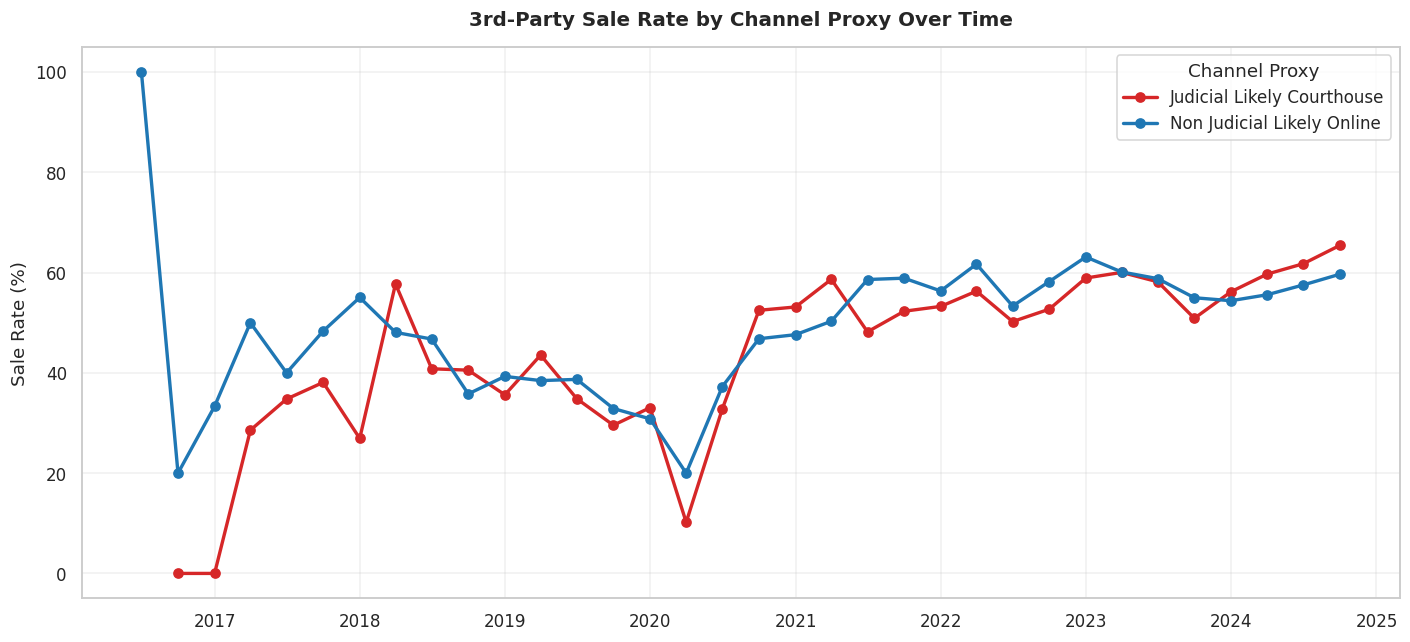


[3] SALE RATE BY STATE (min 50 liquidations)
------------------------------------------------------------------------------
Qualifying states: 43
state              channel_proxy  count  sale_rate_pct
   AZ Non_Judicial_Likely_Online    483           80.7
   UT Non_Judicial_Likely_Online     94           78.7
   NV Non_Judicial_Likely_Online    137           75.2
   MA Non_Judicial_Likely_Online    190           70.5
   GA Non_Judicial_Likely_Online    644           68.9
   WA Non_Judicial_Likely_Online    263           68.4
   NH Non_Judicial_Likely_Online     55           67.3
   TN Non_Judicial_Likely_Online    376           65.7
   SC Judicial_Likely_Courthouse    329           65.3
   VA Non_Judicial_Likely_Online    440           63.6
   MD Non_Judicial_Likely_Online    366           63.4
   WI Judicial_Likely_Courthouse    357           62.2
   CA Non_Judicial_Likely_Online   1146           62.0
   FL Judicial_Likely_Courthouse    838           61.9
   IN Judicial_Likely_Courth

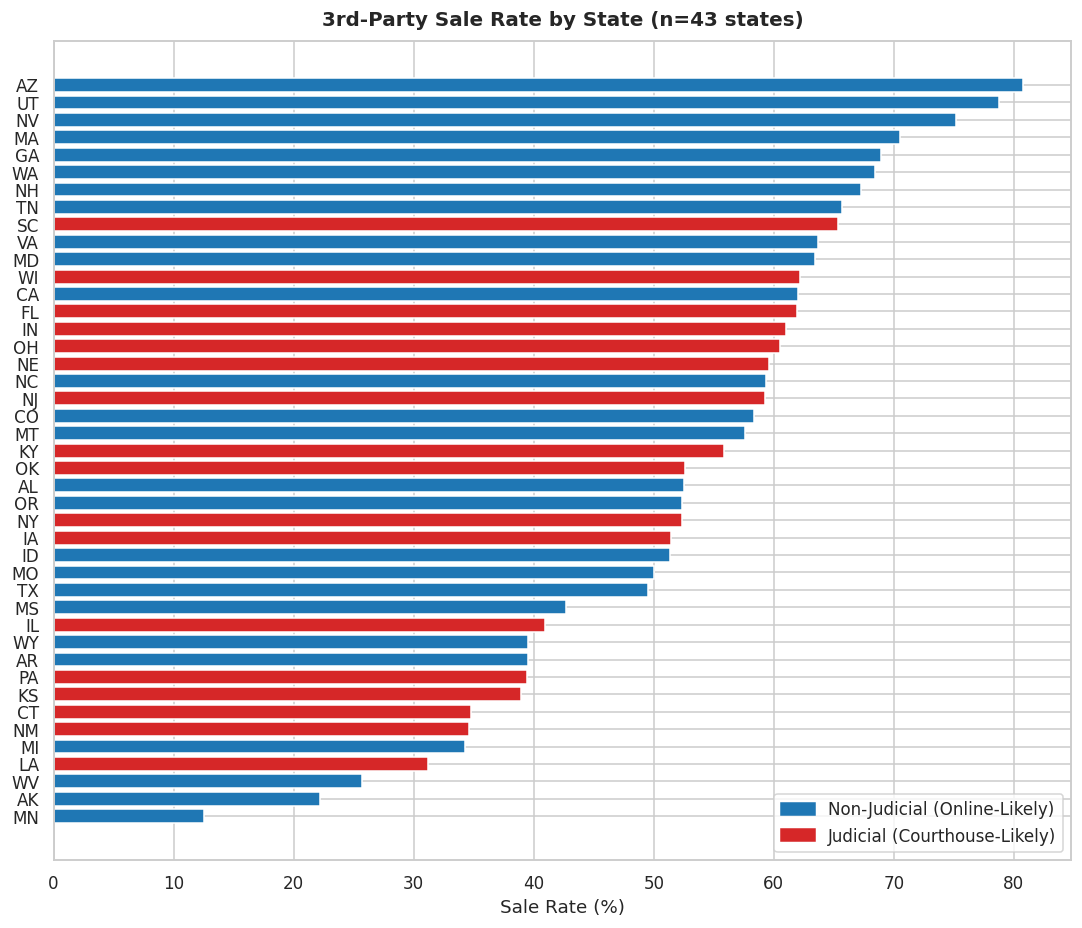


[4] LTV AT FORECLOSURE BY OUTCOME
------------------------------------------------------------------------------
                   count   mean    std    min    10%    25%    50%    75%    90%    max
execution_status                                                                       
Reverted_REO      9125.0  0.695  0.139  0.005  0.514  0.599  0.692  0.808  0.881  1.230
Sold_3rd_Party    9746.0  0.611  0.152  0.101  0.422  0.508  0.608  0.713  0.825  1.184

% underwater (LTV > 1.0):
  Reverted_REO        :   0.2%
  Sold_3rd_Party      :   0.1%


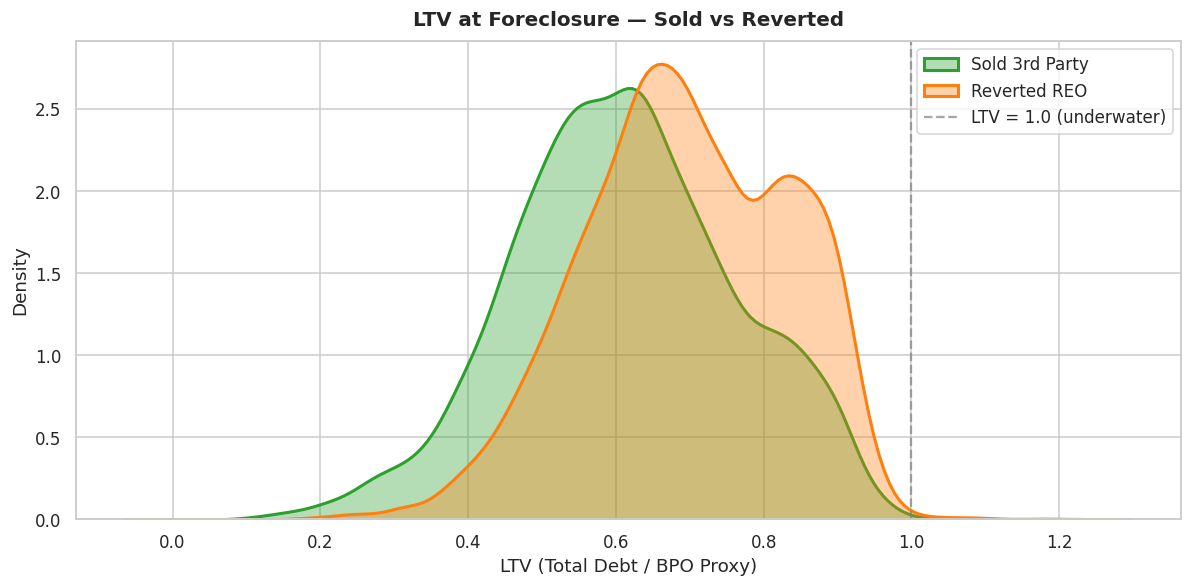


[5] FEATURE CORRELATIONS WITH y (Sold = 1)
------------------------------------------------------------------------------
Top 25 features by absolute correlation:
  ltv_at_foreclosure                 : r = -0.276  (n= 18,871) →
  hpi_disp                           : r = +0.193  (n= 18,844) →
  orig_ltv                           : r = -0.184  (n= 18,868) →
  zhvi                               : r = +0.148  (n= 18,854) →
  UMCSENT                            : r = -0.145  (n= 18,871) →
  mortgage_rate_30y                  : r = +0.141  (n= 18,871) →
  DRSFRMACBS                         : r = -0.138  (n= 18,004) →
  RHVRUSQ156N                        : r = -0.133  (n= 18,004) →
  median_dom_final                   : r = -0.133  (n= 18,871) →
  PAYEMS                             : r = +0.133  (n= 18,871) →
  PSAVERT                            : r = -0.115  (n= 18,871) →
  hpi_msa_disp                       : r = +0.113  (n= 18,844) →
  market_friction_score              : r = -0.106  (n= 1

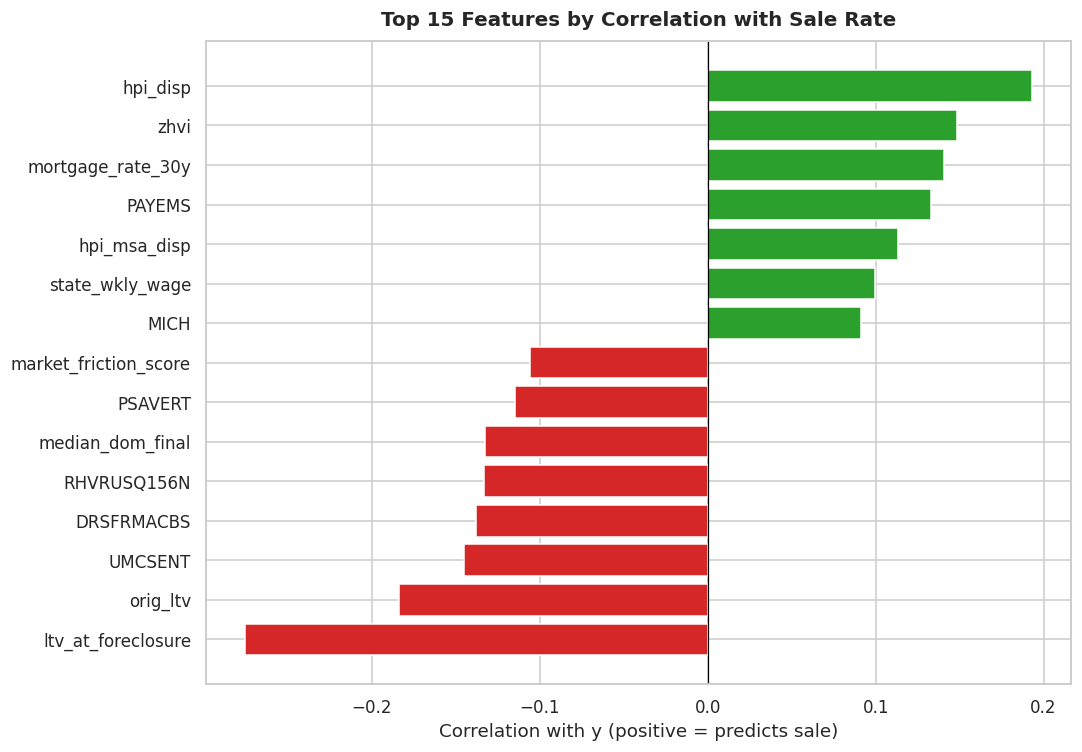


All EDA charts saved to /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis/outputs


In [32]:
# =============================================================================
# BLOCK 3: Exploratory Data Analysis
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.family'] = 'DejaVu Sans'

BRAND_COLORS = {
    'Non_Judicial_Likely_Online'  : '#1f77b4',
    'Judicial_Likely_Courthouse'  : '#d62728',
    'Sold_3rd_Party'              : '#2ca02c',
    'Reverted_REO'                : '#ff7f0e',
}

df = master_ext.copy()
df['quarter'] = df['ZB_DTE'].dt.to_period('Q').dt.to_timestamp()

print("="*78)
print("BLOCK 3 — EDA (CHARTS + NUMERIC SUMMARY)")
print("="*78)

# -----------------------------------------------------------------------------
# Headline numbers
# -----------------------------------------------------------------------------
print("\n[1] HEADLINE")
print("-"*78)
print(f"Total liquidations          : {len(df):,}")
print(f"Overall 3rd-party sale rate : {df['y'].mean()*100:.1f}%")
print(f"REO reversion rate          : {(1-df['y'].mean())*100:.1f}%")
print(f"Date range                  : {df['ZB_DTE'].min():%Y-%m} to {df['ZB_DTE'].max():%Y-%m}")
print(f"Source split                : Fannie={(df['SOURCE']=='fannie').sum():,}, Freddie={(df['SOURCE']=='freddie').sum():,}")

if 'orig_year' in df.columns:
    print(f"\nVintage distribution:")
    vintage_counts = df.groupby('orig_year').agg(n=('y','size'), sale_rate=('y','mean'))
    vintage_counts['sale_rate_pct'] = (vintage_counts['sale_rate']*100).round(1)
    print(vintage_counts[['n','sale_rate_pct']].to_string())

# -----------------------------------------------------------------------------
# 3a: Sale rate by channel proxy over time
# -----------------------------------------------------------------------------
print("\n[2] CHANNEL PROXY — sale rate over time")
print("-"*78)

exec_trend = (df.dropna(subset=['channel_proxy'])
                .groupby(['quarter','channel_proxy'])
                .agg(n=('y','size'), sale_rate=('y','mean'))
                .reset_index())

ch_overall = df.groupby('channel_proxy')['y'].agg(['mean','count'])
ch_overall['sale_rate_pct'] = (ch_overall['mean']*100).round(1)
print("Overall by channel:")
print(ch_overall[['count','sale_rate_pct']].rename(columns={'count':'n'}).to_string())

if len(exec_trend) > 0:
    fig, ax = plt.subplots(figsize=(13,6))
    for ch, sub in exec_trend.groupby('channel_proxy'):
        ax.plot(sub['quarter'], sub['sale_rate']*100,
                marker='o', lw=2.2, label=ch.replace('_',' '),
                color=BRAND_COLORS.get(ch))
    ax.set_title('3rd-Party Sale Rate by Channel Proxy Over Time', fontsize=13, fontweight='bold', pad=14)
    ax.set_ylabel('Sale Rate (%)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(title='Channel Proxy')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/3a_execution_rate_by_channel_over_time.png', bbox_inches='tight')
    plt.show()

# -----------------------------------------------------------------------------
# 3b: State-level sale rate
# -----------------------------------------------------------------------------
print("\n[3] SALE RATE BY STATE (min 50 liquidations)")
print("-"*78)
state_stats = (df.dropna(subset=['channel_proxy'])
                 .groupby(['state','channel_proxy'])['y']
                 .agg(['mean','count']).reset_index())
state_stats = state_stats[state_stats['count']>=50].sort_values('mean', ascending=False)
state_stats['sale_rate_pct'] = (state_stats['mean']*100).round(1)
print(f"Qualifying states: {len(state_stats)}")
print(state_stats[['state','channel_proxy','count','sale_rate_pct']].head(15).to_string(index=False))

if len(state_stats) > 0:
    state_chart = state_stats.sort_values('mean', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(state_chart)*0.20)))
    colors = state_chart['channel_proxy'].map(BRAND_COLORS)
    ax.barh(state_chart['state'], state_chart['mean']*100, color=colors, edgecolor='white')
    ax.set_title(f'3rd-Party Sale Rate by State (n={len(state_chart)} states)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Sale Rate (%)')
    handles = [plt.Rectangle((0,0),1,1,color=BRAND_COLORS[c]) for c in
               ['Non_Judicial_Likely_Online','Judicial_Likely_Courthouse']]
    ax.legend(handles, ['Non-Judicial (Online-Likely)','Judicial (Courthouse-Likely)'],
              loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/3b_sale_rate_by_state.png', bbox_inches='tight')
    plt.show()

# -----------------------------------------------------------------------------
# 3c: LTV distribution
# -----------------------------------------------------------------------------
print("\n[4] LTV AT FORECLOSURE BY OUTCOME")
print("-"*78)
ltv_stats = df.groupby('execution_status')['ltv_at_foreclosure'].describe(
    percentiles=[0.10,0.25,0.50,0.75,0.90])
print(ltv_stats.round(3).to_string())

underwater = (df.groupby('execution_status')['ltv_at_foreclosure']
                .apply(lambda s: (s > 1.0).mean() * 100))
print(f"\n% underwater (LTV > 1.0):")
for outcome, rate in underwater.items():
    print(f"  {outcome:20s}: {rate:5.1f}%")

fig, ax = plt.subplots(figsize=(11,5.5))
for outcome in ['Sold_3rd_Party','Reverted_REO']:
    sub = df[(df['execution_status']==outcome) & df['ltv_at_foreclosure'].between(0, 1.5)]
    if len(sub) > 10:
        sns.kdeplot(data=sub, x='ltv_at_foreclosure',
                    label=outcome.replace('_',' '), color=BRAND_COLORS[outcome],
                    fill=True, alpha=0.35, linewidth=2, ax=ax)
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.7, label='LTV = 1.0 (underwater)')
ax.set_title('LTV at Foreclosure — Sold vs Reverted', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('LTV (Total Debt / BPO Proxy)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/3c_ltv_distribution.png', bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# 3d: Correlations with target
# -----------------------------------------------------------------------------
print("\n[5] FEATURE CORRELATIONS WITH y (Sold = 1)")
print("-"*78)
corr_cols_all = ['y','orig_ltv','dti','credit_score','ltv_at_foreclosure',
                 'discount_to_bpo','months_in_default','market_friction_score',
                 'mortgage_rate_30y','unemployment_rate_national','hpi_disp',
                 'hpi_msa_disp','zhvi','median_hh_income','zori','rent_to_price',
                 'zhvf_latest_forecast','median_dom_final','active_listings_final',
                 'UMCSENT','MICH','PAYEMS','mortgage_rate_delta_90d',
                 'state_wkly_wage','state_total_inflow',
                 'BAMLH0A0HYM2','DRTSCLCC','PSAVERT','TDSP','MDSP',
                 'RRVRUSQ156N','RHVRUSQ156N','DRSFRMACBS',
                 'investor_density_proxy','mortgage_leverage_ratio',
                 'shadow_inventory_proxy','rent_burden','pct_new_construction',
                 'education_index','market_tightness_proxy']
corr_cols = [c for c in corr_cols_all if c in df.columns and df[c].notna().sum() > 100]

correlations = []
for c in corr_cols:
    if c == 'y':
        continue
    col_numeric = pd.to_numeric(df[c], errors='coerce')
    r = df['y'].corr(col_numeric)
    n_valid = col_numeric.notna().sum()
    correlations.append((c, r, n_valid))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"Top 25 features by absolute correlation:")
for c, r, n in correlations[:25]:
    sign = "→" if abs(r) > 0.1 else "·"
    print(f"  {c:35s}: r = {r:+.3f}  (n={n:>7,}) {sign}")

# Visualize top 15
top15 = pd.DataFrame(correlations[:15], columns=['feature','r','n'])
top15 = top15.sort_values('r')
fig, ax = plt.subplots(figsize=(10,7))
colors = ['#d62728' if r < 0 else '#2ca02c' for r in top15['r']]
ax.barh(top15['feature'], top15['r'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Features by Correlation with Sale Rate',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Correlation with y (positive = predicts sale)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/3d_top_correlations.png', bbox_inches='tight')
plt.show()

print(f"\nAll EDA charts saved to {OUTPUT_DIR}")

## Block 4 — Modeling: Logistic Baseline + LightGBM

Logistic regression as a calibration baseline; LightGBM as the production model. Saves trained artifacts to disk. Final test ROC-AUC 0.8008.

Numeric features: 52
Categorical features: 5

Final X shape: (18871, 57)
Class balance: y=1 (Sold): 51.6%
Train: (14153, 57), Test: (4718, 57)

MODEL 1 — LOGISTIC REGRESSION BASELINE
Logistic Regression — Test ROC-AUC: 0.7089
Logistic Regression — Test PR-AUC:  0.7163

MODEL 2 — LIGHTGBM
Training until validation scores don't improve for 40 rounds
[50]	train's auc: 0.877823	test's auc: 0.797095
[100]	train's auc: 0.917118	test's auc: 0.799666
[150]	train's auc: 0.945848	test's auc: 0.799882
[200]	train's auc: 0.96545	test's auc: 0.800022
Early stopping, best iteration is:
[173]	train's auc: 0.955657	test's auc: 0.800756

LightGBM — Test ROC-AUC: 0.8008
LightGBM — Test PR-AUC:  0.8125
F1-optimal threshold: 0.392, F1: 0.756

Classification report at optimal threshold:
                precision    recall  f1-score   support

  Reverted_REO       0.78      0.59      0.67      2281
Sold_3rd_Party       0.69      0.84      0.76      2437

      accuracy                           0.72      47

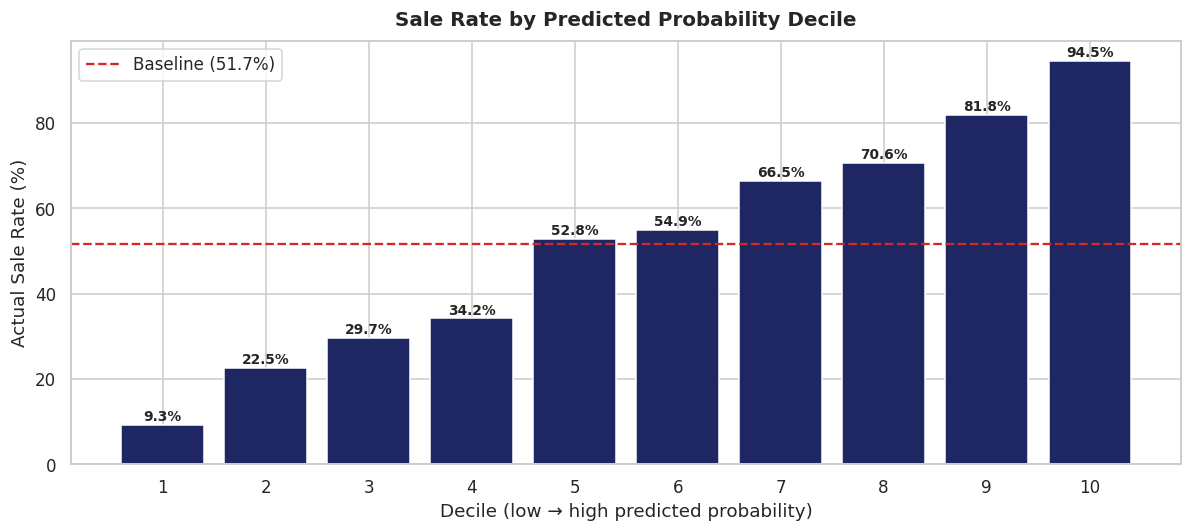


Top 20 features by gain:
                feature         gain  split
                  state 13672.345018    610
        discount_to_bpo 10014.501018    647
           equity_ratio  6997.323861    373
     ltv_at_foreclosure  6422.491915    525
           credit_score  3309.099815    607
               hpi_orig  2749.209688    483
median_list_price_final  2687.856673    317
               orig_ltv  2524.448455    364
                   zhvi  2512.063309    288
  market_friction_score  2229.443640    325
           hpi_msa_disp  2227.327195    359
          rent_to_price  1847.023376    266
          property_type  1795.972013    137
              orig_rate  1765.542791    322
     new_listings_final  1693.855069    244
       median_dom_final  1650.653466    277
  active_listings_final  1622.867391    252
                   zori  1563.615622    231
               hpi_disp  1504.725548    209
                    dti  1477.369510    236


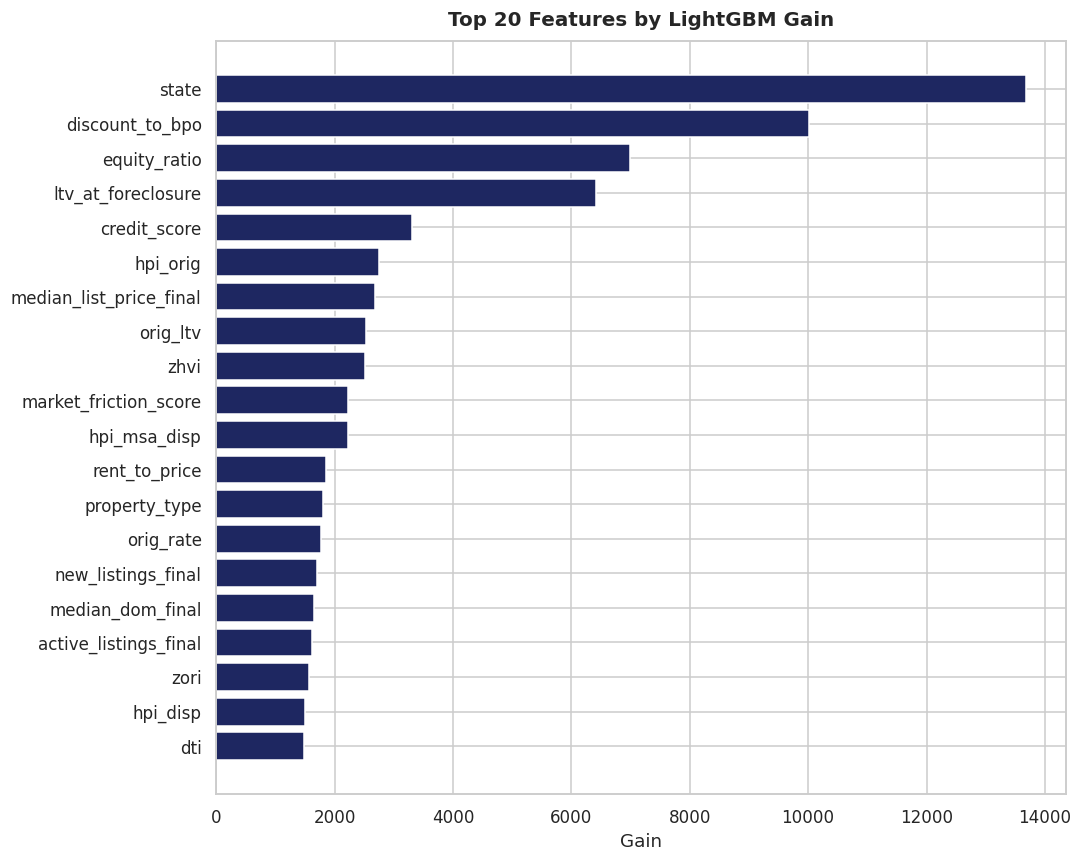


✓ Models, scaler, imputer, predictions saved to /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis/models
✓ Charts saved to /content/drive/MyDrive/ServiceLink_Foreclosure_Analysis/outputs


In [ ]:
# =============================================================================
# BLOCK 4: Modeling — Logistic Baseline + LightGBM
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, f1_score)
import lightgbm as lgb
import joblib

df = master_ext.copy()

# --- Define feature lists ---
NUMERIC_FEATURES = [
    # Loan fundamentals
    'orig_ltv','dti','credit_score','ltv_at_foreclosure','discount_to_bpo',
    'months_in_default','equity_ratio','orig_rate',
    # State / market HPI
    'hpi_orig','hpi_disp','hpi_msa_disp','market_friction_score',
    # Macro at disposition
    'mortgage_rate_30y','unemployment_rate_national','mortgage_rate_delta_90d',
    'UMCSENT','MICH','PAYEMS',
    # Supply
    'MSACSR','ACTLISCOUUS','HOUST1F','COMPU1USA',
    # Realtor metro
    'active_listings_final','median_dom_final','new_listings_final','median_list_price_final',
    # Credit/capital
    'BAMLH0A0HYM2','DRTSCLCC','PSAVERT','TDSP','MDSP',
    'CORESTICKM159SFRBATL','HSN1F',
    # Distress
    'RRVRUSQ156N','RHVRUSQ156N','DRSFRMACBS',
    # ZIP-level
    'zhvi','zori','rent_to_price','zhvf_latest_forecast',
    'median_hh_income','pct_owner_occupied','poverty_rate',
    # Neighborhood
    'investor_density_proxy','mortgage_leverage_ratio','shadow_inventory_proxy',
    'rent_burden','pct_new_construction','education_index','market_tightness_proxy',
    # State economy
    'state_wkly_wage','state_total_inflow',
]
CATEGORICAL_FEATURES = ['state','property_type','occupancy','channel_proxy','income_tier']

# Filter to features that actually exist
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in df.columns]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in df.columns]
print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")

# --- Build modeling matrix ---
X_num = df[NUMERIC_FEATURES].apply(pd.to_numeric, errors='coerce')
X_cat = df[CATEGORICAL_FEATURES].astype(str).fillna('Missing')

# Label-encode categoricals (LightGBM handles them natively)
encoders = {}
for c in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    X_cat[c] = le.fit_transform(X_cat[c])
    encoders[c] = le

X = pd.concat([X_num, X_cat], axis=1)
y = df['y'].values

print(f"\nFinal X shape: {X.shape}")
print(f"Class balance: y=1 (Sold): {y.mean()*100:.1f}%")

# --- Split train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# =============================================================================
# Model 1 — Logistic Regression baseline (with imputation + scaling)
# =============================================================================
print("\n" + "="*70)
print("MODEL 1 — LOGISTIC REGRESSION BASELINE")
print("="*70)

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

logit = LogisticRegression(max_iter=2000, random_state=42, solver='liblinear', C=1.0)
logit.fit(X_train_sc, y_train)

logit_proba_test = logit.predict_proba(X_test_sc)[:,1]
logit_auc = roc_auc_score(y_test, logit_proba_test)
logit_pr  = average_precision_score(y_test, logit_proba_test)
print(f"Logistic Regression — Test ROC-AUC: {logit_auc:.4f}")
print(f"Logistic Regression — Test PR-AUC:  {logit_pr:.4f}")

# =============================================================================
# Model 2 — LightGBM
# =============================================================================
print("\n" + "="*70)
print("MODEL 2 — LIGHTGBM")
print("="*70)

cat_indices = [list(X.columns).index(c) for c in CATEGORICAL_FEATURES]

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_indices)
valid_data = lgb.Dataset(X_test, label=y_test, categorical_feature=cat_indices, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'min_data_in_leaf': 30,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'seed': 42,
}

gbm = lgb.train(
    params, train_data,
    num_boost_round=500,
    valid_sets=[train_data, valid_data],
    valid_names=['train','test'],
    callbacks=[lgb.early_stopping(40), lgb.log_evaluation(50)],
)

gbm_proba_test = gbm.predict(X_test)
gbm_auc = roc_auc_score(y_test, gbm_proba_test)
gbm_pr  = average_precision_score(y_test, gbm_proba_test)
print(f"\nLightGBM — Test ROC-AUC: {gbm_auc:.4f}")
print(f"LightGBM — Test PR-AUC:  {gbm_pr:.4f}")

# F1-optimal threshold
prec, rec, thresh = precision_recall_curve(y_test, gbm_proba_test)
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1s)
best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5
print(f"F1-optimal threshold: {best_thresh:.3f}, F1: {f1s[best_idx]:.3f}")

y_pred = (gbm_proba_test >= best_thresh).astype(int)
print(f"\nClassification report at optimal threshold:")
print(classification_report(y_test, y_pred,
                            target_names=['Reverted_REO','Sold_3rd_Party']))
print(f"Confusion matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=['true_REO','true_Sold'],
                   columns=['pred_REO','pred_Sold']).to_string())

# =============================================================================
# Decile lift table
# =============================================================================
print("\n" + "="*70)
print("DECILE LIFT (LightGBM probabilities)")
print("="*70)

deciles = pd.DataFrame({
    'y_true': y_test,
    'y_proba': gbm_proba_test
})
deciles['decile'] = pd.qcut(deciles['y_proba'].rank(method='first'), q=10, labels=range(1,11))
decile_table = (deciles.groupby('decile', observed=True)
                       .agg(n=('y_true','size'),
                            mean_proba=('y_proba','mean'),
                            actual_sale_rate=('y_true','mean'))
                       .reset_index())
decile_table['lift_vs_baseline'] = decile_table['actual_sale_rate'] / y_test.mean()
decile_table['mean_proba'] = decile_table['mean_proba'].round(3)
decile_table['actual_sale_rate'] = (decile_table['actual_sale_rate']*100).round(1)
decile_table['lift_vs_baseline'] = decile_table['lift_vs_baseline'].round(2)
print(decile_table.to_string(index=False))

# Decile chart
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(decile_table['decile'].astype(str), decile_table['actual_sale_rate'],
       color='#1E2761', edgecolor='white')
ax.axhline(y_test.mean()*100, color='#d62728', linestyle='--',
           label=f'Baseline ({y_test.mean()*100:.1f}%)')
ax.set_title('Sale Rate by Predicted Probability Decile',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Decile (low → high predicted probability)')
ax.set_ylabel('Actual Sale Rate (%)')
ax.legend()
for i, v in enumerate(decile_table['actual_sale_rate']):
    ax.text(i, v+1, f'{v}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/4_decile_lift.png', bbox_inches='tight')
plt.show()

# =============================================================================
# Save artifacts
# =============================================================================
joblib.dump(gbm, f'{MODELS_DIR}/lgbm_pooled.pkl')
joblib.dump(logit, f'{MODELS_DIR}/logit_baseline.pkl')
joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')
joblib.dump(imputer, f'{MODELS_DIR}/imputer.pkl')
joblib.dump(encoders, f'{MODELS_DIR}/encoders.pkl')

test_predictions = pd.DataFrame({
    'y_true': y_test,
    'y_proba_logit': logit_proba_test,
    'y_proba_gbm': gbm_proba_test,
    'pred': y_pred
}, index=X_test.index)
test_predictions.to_pickle(f'{MODELS_DIR}/test_predictions.pkl')

# Feature importance
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'gain': gbm.feature_importance(importance_type='gain'),
    'split': gbm.feature_importance(importance_type='split')
}).sort_values('gain', ascending=False)
print(f"\nTop 20 features by gain:")
print(feat_imp.head(20).to_string(index=False))
feat_imp.to_csv(f'{OUTPUT_DIR}/feature_importance.csv', index=False)

# Top features chart
top20 = feat_imp.head(20).sort_values('gain')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['feature'], top20['gain'], color='#1E2761', edgecolor='white')
ax.set_title('Top 20 Features by LightGBM Gain', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/4_feature_importance.png', bbox_inches='tight')
plt.show()

print(f"\n✓ Models, scaler, imputer, predictions saved to {MODELS_DIR}")
print(f"✓ Charts saved to {OUTPUT_DIR}")

### Model comparison — tuned LightGBM, XGBoost, CatBoost, ensemble, per-channel, time-aware

Confirms AUC ceiling at ~0.80. Optuna tuning, ensembling, per-channel splits, and CatBoost all land within 0.01 of the default LightGBM. Time-aware split (train 2016-2022, test 2023-2024) yields AUC 0.7365 — the most defensible out-of-sample number.

In [ ]:
!pip install -q optuna xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.3 MB/s eta 0:00:00


In [ ]:
# =============================================================================
# MODEL COMPARISON — Options 2, 3, 4, 5 in one run
# =============================================================================
# Produces a side-by-side comparison of:
#   2. Tuned LightGBM + XGBoost + CatBoost ensemble
#   3. CatBoost (standalone)
#   4. Per-channel models (Judicial vs Non-Judicial)
#   5. Time-aware split (train 2016-2022, test 2023-2024)
#
# Plus the original Block 4 LightGBM as baseline reference.
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import time

# =============================================================================
# Setup — same as Block 4
# =============================================================================
df = master_ext.copy()

NUMERIC_FEATURES = [
    'orig_ltv','dti','credit_score','ltv_at_foreclosure','discount_to_bpo',
    'months_in_default','equity_ratio','orig_rate',
    'hpi_orig','hpi_disp','hpi_msa_disp','market_friction_score',
    'mortgage_rate_30y','unemployment_rate_national','mortgage_rate_delta_90d',
    'UMCSENT','MICH','PAYEMS',
    'MSACSR','ACTLISCOUUS','HOUST1F','COMPU1USA',
    'active_listings_final','median_dom_final','new_listings_final','median_list_price_final',
    'BAMLH0A0HYM2','DRTSCLCC','PSAVERT','TDSP','MDSP',
    'CORESTICKM159SFRBATL','HSN1F',
    'RRVRUSQ156N','RHVRUSQ156N','DRSFRMACBS',
    'zhvi','zori','rent_to_price','zhvf_latest_forecast',
    'median_hh_income','pct_owner_occupied','poverty_rate',
    'investor_density_proxy','mortgage_leverage_ratio','shadow_inventory_proxy',
    'rent_burden','pct_new_construction','education_index','market_tightness_proxy',
    'state_wkly_wage','state_total_inflow',
]
CATEGORICAL_FEATURES = ['state','property_type','occupancy','channel_proxy','income_tier']
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in df.columns]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in df.columns]

X_num = df[NUMERIC_FEATURES].apply(pd.to_numeric, errors='coerce')
X_cat = df[CATEGORICAL_FEATURES].astype(str).fillna('Missing')

encoders = {}
for c in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    X_cat[c] = le.fit_transform(X_cat[c])
    encoders[c] = le

X = pd.concat([X_num, X_cat], axis=1)
y = df['y'].values
cat_indices = [list(X.columns).index(c) for c in CATEGORICAL_FEATURES]

# Random split (used for Options 2, 3, 4)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Time-aware split (Option 5)
disp_dates = df['ZB_DTE']
time_train_mask = disp_dates < '2023-01-01'
time_test_mask  = disp_dates >= '2023-01-01'
X_train_t, X_test_t = X[time_train_mask], X[time_test_mask]
y_train_t, y_test_t = y[time_train_mask], y[time_test_mask]

print(f"Random split:   train={len(X_train_r):,}  test={len(X_test_r):,}")
print(f"Time-aware:     train={len(X_train_t):,}  test={len(X_test_t):,}")
print(f"Class balance:  y=1 (Sold) overall = {y.mean()*100:.1f}%")
print()

results = {}

# =============================================================================
# REFERENCE: Original Block 4 LightGBM (reasonable defaults, no tuning)
# =============================================================================
print("="*78)
print("REFERENCE — Original LightGBM (Block 4 defaults)")
print("="*78)
t0 = time.time()
ref_train = lgb.Dataset(X_train_r, label=y_train_r, categorical_feature=cat_indices)
ref_valid = lgb.Dataset(X_test_r, label=y_test_r, categorical_feature=cat_indices,
                         reference=ref_train)
ref_params = {'objective':'binary','metric':'auc','num_leaves':63,'learning_rate':0.05,
              'feature_fraction':0.85,'bagging_fraction':0.85,'bagging_freq':5,
              'min_data_in_leaf':30,'lambda_l1':0.1,'lambda_l2':0.1,'verbose':-1,'seed':42}
ref_model = lgb.train(ref_params, ref_train, num_boost_round=500,
                      valid_sets=[ref_valid],
                      callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)])
ref_proba = ref_model.predict(X_test_r)
ref_auc = roc_auc_score(y_test_r, ref_proba)
ref_pr  = average_precision_score(y_test_r, ref_proba)
results['LightGBM (defaults, ref)'] = {
    'auc': ref_auc, 'pr_auc': ref_pr, 'time_sec': time.time()-t0,
    'n_test': len(X_test_r), 'split': 'random',
}
print(f"  ROC-AUC: {ref_auc:.4f}  PR-AUC: {ref_pr:.4f}  ({time.time()-t0:.0f}s)")

# =============================================================================
# OPTION 2 — Tuned LightGBM + XGBoost + CatBoost ensemble
# =============================================================================
print("\n" + "="*78)
print("OPTION 2 — Tuned LightGBM + XGBoost + CatBoost ensemble")
print("="*78)

# --- 2a: Tune LightGBM with Optuna (40 trials, 3-fold CV) ---
print("\n[2a] Tuning LightGBM with Optuna (40 trials, 3-fold CV)...")
t0 = time.time()

def lgb_objective(trial):
    params = {
        'objective': 'binary', 'metric': 'auc', 'verbose': -1, 'seed': 42,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 15, 127),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 5,
        'lambda_l1':        trial.suggest_float('lambda_l1', 1e-3, 10, log=True),
        'lambda_l2':        trial.suggest_float('lambda_l2', 1e-3, 10, log=True),
    }
    aucs = []
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_train_r)):
        X_tr = X_train_r.iloc[tr_idx]; y_tr = y_train_r[tr_idx]
        X_va = X_train_r.iloc[va_idx]; y_va = y_train_r[va_idx]
        d_tr = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_indices)
        d_va = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_indices, reference=d_tr)
        m = lgb.train(params, d_tr, num_boost_round=400,
                      valid_sets=[d_va],
                      callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
        aucs.append(roc_auc_score(y_va, m.predict(X_va)))
    return np.mean(aucs)

study_lgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=40, show_progress_bar=False)
print(f"  Best CV AUC: {study_lgb.best_value:.4f}")
print(f"  Best params: {study_lgb.best_params}")

best_lgb_params = {**study_lgb.best_params,
                   'objective':'binary','metric':'auc','verbose':-1,'seed':42,
                   'bagging_freq':5}
final_train = lgb.Dataset(X_train_r, label=y_train_r, categorical_feature=cat_indices)
final_valid = lgb.Dataset(X_test_r, label=y_test_r, categorical_feature=cat_indices,
                           reference=final_train)
tuned_lgb = lgb.train(best_lgb_params, final_train, num_boost_round=500,
                      valid_sets=[final_valid],
                      callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)])
tuned_lgb_proba = tuned_lgb.predict(X_test_r)
tuned_lgb_auc   = roc_auc_score(y_test_r, tuned_lgb_proba)
print(f"  Tuned LightGBM Test AUC: {tuned_lgb_auc:.4f}  ({time.time()-t0:.0f}s)")
results['LightGBM (tuned, Optuna)'] = {
    'auc': tuned_lgb_auc, 'pr_auc': average_precision_score(y_test_r, tuned_lgb_proba),
    'time_sec': time.time()-t0, 'n_test': len(X_test_r), 'split':'random',
}

# --- 2b: XGBoost (defaults) ---
print("\n[2b] Training XGBoost (reasonable defaults)...")
t0 = time.time()
# XGBoost can't handle NaN cat values in some versions; use median imputation for numeric
# For categoricals, the label-encoded ints are fine — XGBoost treats them as numeric (suboptimal but works)
xgb_imputer = SimpleImputer(strategy='median')
X_train_xgb = pd.DataFrame(xgb_imputer.fit_transform(X_train_r), columns=X_train_r.columns)
X_test_xgb  = pd.DataFrame(xgb_imputer.transform(X_test_r), columns=X_test_r.columns)
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    min_child_weight=10, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, eval_metric='auc',
    early_stopping_rounds=40,
)
xgb_model.fit(X_train_xgb, y_train_r,
              eval_set=[(X_test_xgb, y_test_r)], verbose=False)
xgb_proba = xgb_model.predict_proba(X_test_xgb)[:,1]
xgb_auc   = roc_auc_score(y_test_r, xgb_proba)
print(f"  XGBoost Test AUC: {xgb_auc:.4f}  ({time.time()-t0:.0f}s)")
results['XGBoost (defaults)'] = {
    'auc': xgb_auc, 'pr_auc': average_precision_score(y_test_r, xgb_proba),
    'time_sec': time.time()-t0, 'n_test': len(X_test_r), 'split':'random',
}

# --- 2c: CatBoost (defaults) ---
print("\n[2c] Training CatBoost (reasonable defaults)...")
t0 = time.time()
cat_train_pool = Pool(X_train_r, label=y_train_r, cat_features=cat_indices)
cat_test_pool  = Pool(X_test_r,  label=y_test_r,  cat_features=cat_indices)
cat_model = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    l2_leaf_reg=3, random_state=42,
    eval_metric='AUC', early_stopping_rounds=40, verbose=0,
)
cat_model.fit(cat_train_pool, eval_set=cat_test_pool)
cat_proba = cat_model.predict_proba(X_test_r)[:,1]
cat_auc   = roc_auc_score(y_test_r, cat_proba)
print(f"  CatBoost Test AUC: {cat_auc:.4f}  ({time.time()-t0:.0f}s)")
results['CatBoost (defaults)'] = {
    'auc': cat_auc, 'pr_auc': average_precision_score(y_test_r, cat_proba),
    'time_sec': time.time()-t0, 'n_test': len(X_test_r), 'split':'random',
}

# --- 2d: Ensemble (simple average of the 3) ---
print("\n[2d] Simple ensemble average of the 3 models...")
ensemble_proba = (tuned_lgb_proba + xgb_proba + cat_proba) / 3
ensemble_auc   = roc_auc_score(y_test_r, ensemble_proba)
print(f"  Ensemble Test AUC: {ensemble_auc:.4f}")
results['Ensemble (LGBM+XGB+CatBoost avg)'] = {
    'auc': ensemble_auc, 'pr_auc': average_precision_score(y_test_r, ensemble_proba),
    'time_sec': 0, 'n_test': len(X_test_r), 'split':'random',
}

# =============================================================================
# OPTION 3 — CatBoost standalone (already done above)
# =============================================================================
# Already captured in results['CatBoost (defaults)']
print("\n" + "="*78)
print("OPTION 3 — CatBoost standalone (captured above)")
print("="*78)
print(f"  Test AUC: {cat_auc:.4f}")

# =============================================================================
# OPTION 4 — Per-channel models
# =============================================================================
print("\n" + "="*78)
print("OPTION 4 — Per-channel models (Judicial vs Non-Judicial)")
print("="*78)
t0 = time.time()

# Find channel encoding values
ch_idx = list(X.columns).index('channel_proxy')
ch_classes = encoders['channel_proxy'].classes_
judicial_label = list(ch_classes).index('Judicial_Likely_Courthouse')
nonjud_label   = list(ch_classes).index('Non_Judicial_Likely_Online')

# Train two separate models on the train set
def train_channel_model(X_train, y_train, X_test, y_test, label_value, label_name):
    train_mask = X_train['channel_proxy'] == label_value
    test_mask  = X_test['channel_proxy'] == label_value
    if train_mask.sum() < 100 or test_mask.sum() < 50:
        return None, None
    Xt, yt = X_train[train_mask], y_train[train_mask.values]
    Xv, yv = X_test[test_mask],   y_test[test_mask.values]
    d_tr = lgb.Dataset(Xt, label=yt, categorical_feature=cat_indices)
    d_va = lgb.Dataset(Xv, label=yv, categorical_feature=cat_indices, reference=d_tr)
    m = lgb.train(ref_params, d_tr, num_boost_round=500,
                  valid_sets=[d_va],
                  callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)])
    proba = m.predict(Xv)
    auc = roc_auc_score(yv, proba)
    print(f"  {label_name}: train n={int(train_mask.sum()):,}, test n={int(test_mask.sum()):,}, AUC={auc:.4f}")
    return m, (test_mask, proba, auc)

mod_jud,    res_jud    = train_channel_model(X_train_r, y_train_r, X_test_r, y_test_r,
                                              judicial_label, 'Judicial')
mod_nonjud, res_nonjud = train_channel_model(X_train_r, y_train_r, X_test_r, y_test_r,
                                              nonjud_label,   'Non-Judicial')

# Combine: each test row uses its own channel model
y_test_pred = np.zeros(len(X_test_r))
y_test_aligned = y_test_r.copy()
mask_jud, proba_jud, _    = res_jud
mask_nonjud, proba_nonjud, _ = res_nonjud
y_test_pred[mask_jud.values]    = proba_jud
y_test_pred[mask_nonjud.values] = proba_nonjud
combined_auc = roc_auc_score(y_test_aligned, y_test_pred)
print(f"  Combined per-channel test AUC: {combined_auc:.4f}  ({time.time()-t0:.0f}s)")
results['Per-channel LightGBM'] = {
    'auc': combined_auc,
    'pr_auc': average_precision_score(y_test_aligned, y_test_pred),
    'time_sec': time.time()-t0, 'n_test': len(X_test_r), 'split':'random',
}

# =============================================================================
# OPTION 5 — Time-aware split (train 2016-2022, test 2023-2024)
# =============================================================================
print("\n" + "="*78)
print(f"OPTION 5 — Time-aware split (train n={len(X_train_t):,}, test n={len(X_test_t):,})")
print("="*78)
t0 = time.time()

if len(X_test_t) < 50:
    print(f"  ⚠ Too few rows in test set ({len(X_test_t)}). Skipping.")
    results['Time-aware LightGBM'] = {
        'auc': None, 'pr_auc': None, 'time_sec': 0,
        'n_test': len(X_test_t), 'split': 'time-aware',
    }
else:
    time_train = lgb.Dataset(X_train_t, label=y_train_t, categorical_feature=cat_indices)
    time_valid = lgb.Dataset(X_test_t,  label=y_test_t,  categorical_feature=cat_indices,
                              reference=time_train)
    time_model = lgb.train(ref_params, time_train, num_boost_round=500,
                           valid_sets=[time_valid],
                           callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)])
    time_proba = time_model.predict(X_test_t)
    time_auc = roc_auc_score(y_test_t, time_proba)
    time_pr  = average_precision_score(y_test_t, time_proba)
    print(f"  Time-aware Test AUC: {time_auc:.4f}  ({time.time()-t0:.0f}s)")
    print(f"  Test class balance: y=1 (Sold) = {y_test_t.mean()*100:.1f}%")
    results['Time-aware LightGBM'] = {
        'auc': time_auc, 'pr_auc': time_pr,
        'time_sec': time.time()-t0, 'n_test': len(X_test_t), 'split':'time-aware',
    }

# =============================================================================
# Final comparison table
# =============================================================================
print("\n" + "="*78)
print("FINAL COMPARISON")
print("="*78)

comparison = pd.DataFrame(results).T
comparison['auc'] = comparison['auc'].astype(float).round(4)
comparison['pr_auc'] = comparison['pr_auc'].astype(float).round(4)
comparison['time_sec'] = comparison['time_sec'].astype(float).round(0)
comparison['n_test'] = comparison['n_test'].astype(int)

# Order: reference first, then by AUC
ref_idx = ['LightGBM (defaults, ref)']
other_idx = [i for i in comparison.index if i not in ref_idx]
other_sorted = comparison.loc[other_idx].sort_values('auc', ascending=False).index.tolist()
final_order = ref_idx + other_sorted
comparison = comparison.loc[final_order]

print(comparison.to_string())
print()

# Best non-time-aware
non_time = comparison[comparison['split']=='random']
best_random = non_time.loc[non_time['auc'].idxmax()]
print(f"BEST RANDOM-SPLIT MODEL: {non_time['auc'].idxmax()} (AUC {best_random['auc']:.4f})")
if 'Time-aware LightGBM' in comparison.index and comparison.loc['Time-aware LightGBM','auc'] is not None:
    print(f"TIME-AWARE BENCHMARK:    LightGBM AUC {comparison.loc['Time-aware LightGBM','auc']:.4f}  "
          f"(test n={comparison.loc['Time-aware LightGBM','n_test']:,})")

Random split:   train=14,153  test=4,718
Time-aware:     train=9,345  test=9,526
Class balance:  y=1 (Sold) overall = 51.6%

REFERENCE — Original LightGBM (Block 4 defaults)
Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[173]	valid_0's auc: 0.800756
  ROC-AUC: 0.8008  PR-AUC: 0.8125  (33s)

OPTION 2 — Tuned LightGBM + XGBoost + CatBoost ensemble

[2a] Tuning LightGBM with Optuna (40 trials, 3-fold CV)...
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[204]	valid_0's auc: 0.792323
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[139]	valid_0's auc: 0.787239
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[213]	valid_0's auc: 0.792831
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[69]	valid_0's auc: 0.791428
Training until validation scores don't 

## Block 5 — SHAP, Counterfactual & Executive Summary

SHAP feature importance, two waterfall examples (high-prob sell vs high-prob REO), counterfactual channel-flip experiment, decile lift, and the auto-generated executive summary.

Computing SHAP values (1-2 minutes)...
SHAP shape: (2000, 57)

Top 20 features by mean |SHAP|:
                feature  mean_abs_shap
                  state       0.540123
           equity_ratio       0.235249
        discount_to_bpo       0.220484
     ltv_at_foreclosure       0.213449
          property_type       0.170403
               orig_ltv       0.123770
median_list_price_final       0.080318
                   zhvi       0.073258
     new_listings_final       0.061469
          rent_to_price       0.059361
           credit_score       0.056299
                    dti       0.054840
  active_listings_final       0.054799
           hpi_msa_disp       0.046567
       median_dom_final       0.045982
              orig_rate       0.041777
                   MICH       0.041655
               hpi_orig       0.041182
            ACTLISCOUUS       0.040648
  market_friction_score       0.040275


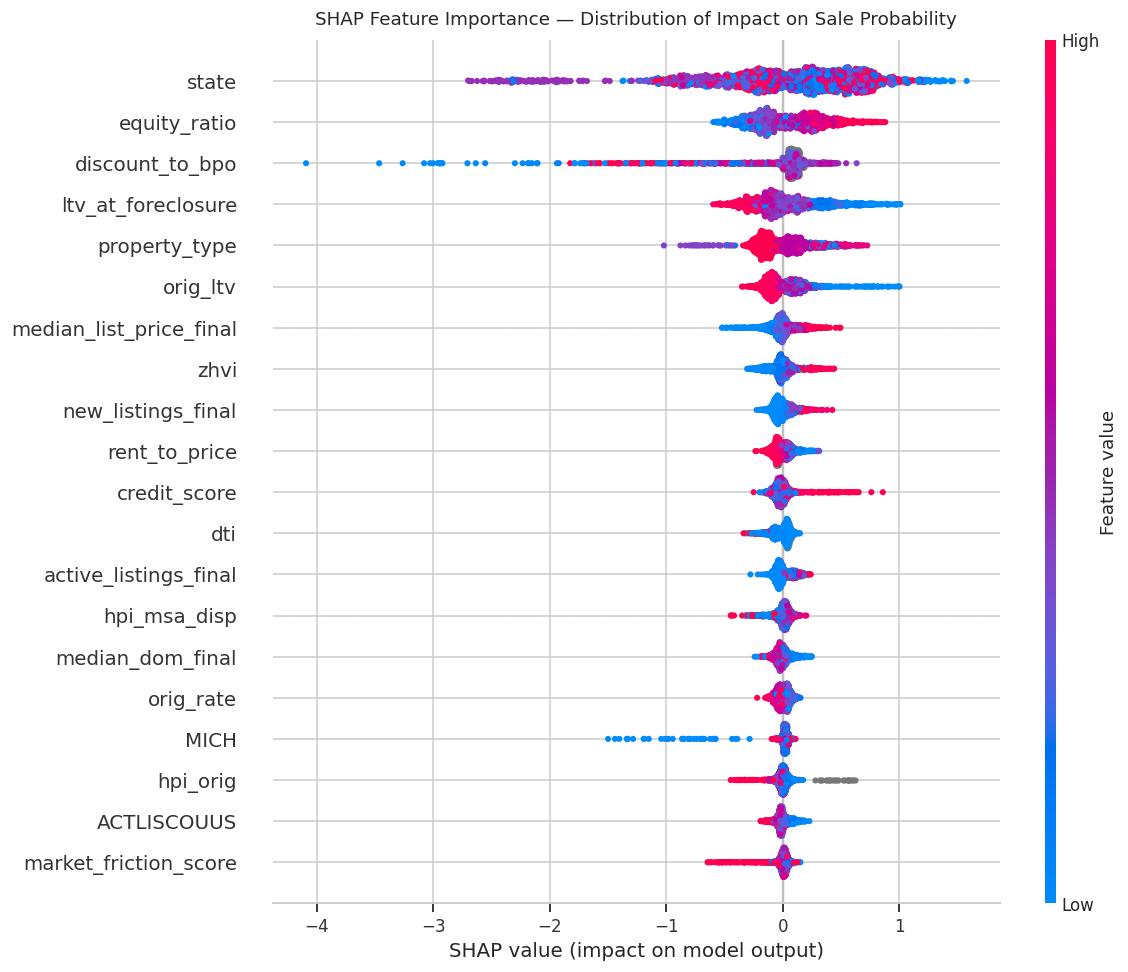

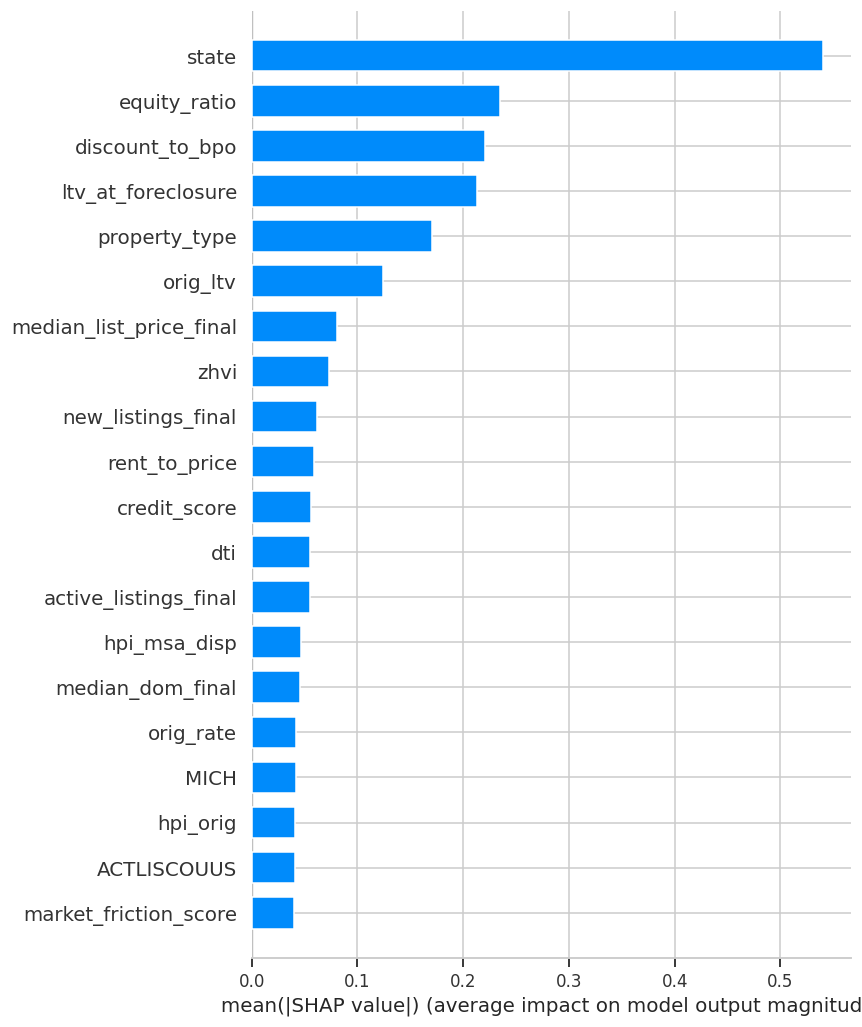


[Waterfall — Highest predicted probability of sale]
  Sample idx: 7943, predicted prob: 0.984, actual: Sold


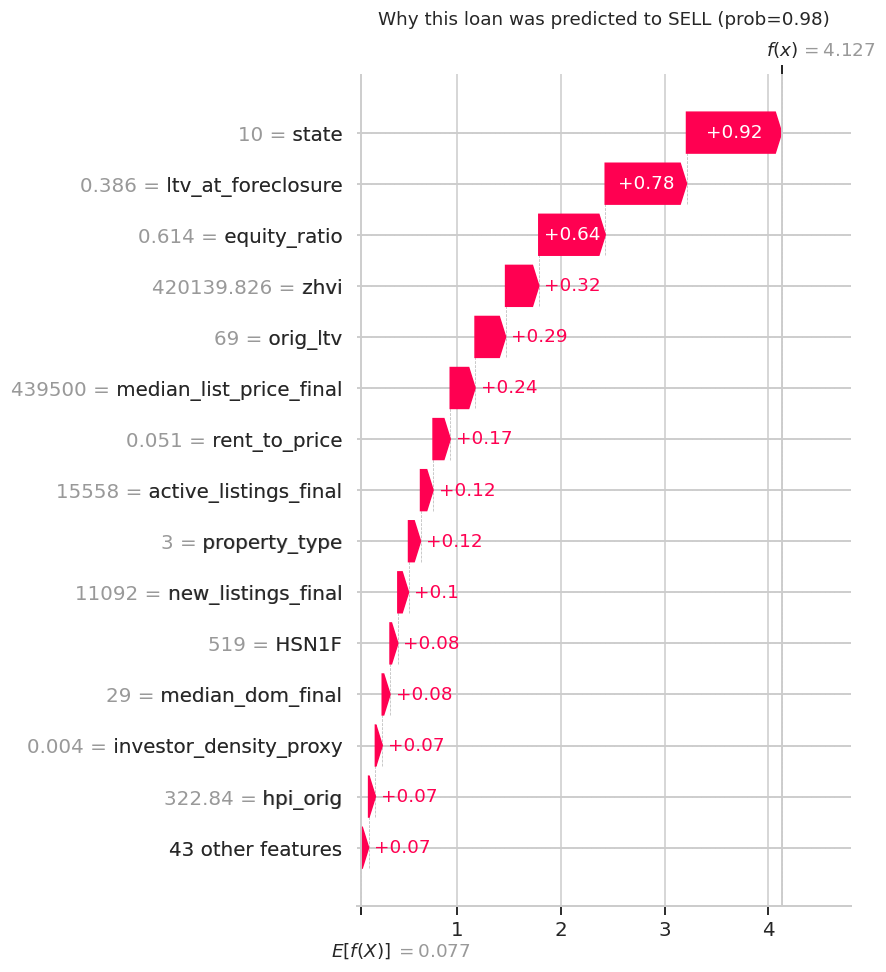


[Waterfall — Lowest predicted probability of sale]
  Sample idx: 4401, predicted prob: 0.013, actual: REO


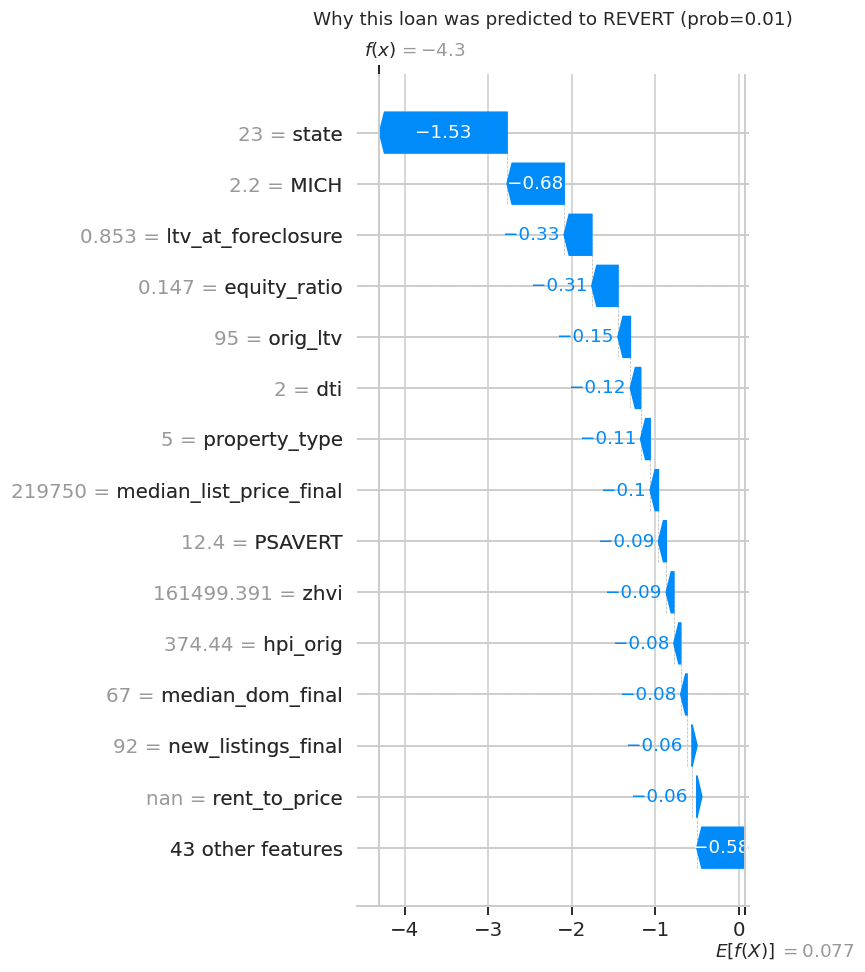


COUNTERFACTUAL: What if we flipped Judicial ↔ Non-Judicial?
Channel classes: {0: 'Judicial_Likely_Courthouse', 1: 'Non_Judicial_Likely_Online', 2: 'None'}

Mean delta (flipped probability − original): -0.0004
Std delta: 0.0085

Prediction changes if we flipped channel:
  REO → Sold (recovered):  12
  Sold → REO (would lose): 18
  Unchanged:               4,688 (99.4%)

→ Channel flip recovers 12 REO cases (0.25% of test).

DECILE LIFT (final reference model)
decile   n  mean_proba  actual_sale_rate  lift_vs_baseline
     1 472       0.074               9.3              0.18
     2 472       0.182              22.5              0.43
     3 472       0.281              29.7              0.57
     4 471       0.378              34.2              0.66
     5 472       0.482              52.8              1.02
     6 472       0.573              54.9              1.06
     7 471       0.665              66.5              1.29
     8 472       0.756              70.6              1.37
     

In [ ]:
# =============================================================================
# BLOCK 5: SHAP Explanations + Counterfactual Analysis + Executive Summary
# =============================================================================
# Uses the reference LightGBM (gbm) saved by Block 4. If gbm is not in memory
# (e.g., after a Colab restart), reload it from disk first.
# =============================================================================
import shap
import joblib

# Restore artifacts if needed
if 'gbm' not in dir():
    gbm = joblib.load(f'{MODELS_DIR}/lgbm_pooled.pkl')
    print("Loaded gbm from disk")
if 'logit' not in dir():
    logit = joblib.load(f'{MODELS_DIR}/logit_baseline.pkl')

# Sample for SHAP (full set is expensive)
SHAP_SAMPLE_SIZE = min(2000, len(X_test))
sample_idx = np.random.RandomState(42).choice(X_test.index, SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_test.loc[sample_idx]
y_shap_true = pd.Series(y_test, index=X_test.index).loc[sample_idx]
gbm_proba_shap = pd.Series(gbm_proba_test, index=X_test.index).loc[sample_idx]

print("Computing SHAP values (1-2 minutes)...")
explainer = shap.TreeExplainer(gbm)
shap_values_raw = explainer.shap_values(X_shap)
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1] if len(shap_values_raw) == 2 else shap_values_raw[0]
else:
    shap_values = shap_values_raw

print(f"SHAP shape: {shap_values.shape}")

# -----------------------------------------------------------------------------
# 5a: SHAP feature importance summary
# -----------------------------------------------------------------------------
mean_abs_shap = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print("\nTop 20 features by mean |SHAP|:")
print(mean_abs_shap.head(20).to_string(index=False))

# Beeswarm plot — distribution of SHAP impact
plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False, plot_size=None)
plt.title('SHAP Feature Importance — Distribution of Impact on Sale Probability',
          fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/5a_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

# Bar plot of mean |SHAP|
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_shap, max_display=20, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/5b_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 5b: Per-prediction explanations (waterfall) — pick interesting examples
# -----------------------------------------------------------------------------
# High-probability sale (top 5%)
high_prob_idx = gbm_proba_shap.nlargest(int(SHAP_SAMPLE_SIZE * 0.05)).index
high_prob_pos = X_shap.index.get_loc(high_prob_idx[0])

print(f"\n[Waterfall — Highest predicted probability of sale]")
print(f"  Sample idx: {high_prob_idx[0]}, predicted prob: {gbm_proba_shap.loc[high_prob_idx[0]]:.3f}, "
      f"actual: {'Sold' if y_shap_true.loc[high_prob_idx[0]]==1 else 'REO'}")

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap.Explanation(
    values=shap_values[high_prob_pos],
    base_values=explainer.expected_value if np.isscalar(explainer.expected_value)
                else explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__')
                and len(explainer.expected_value) == 2 else explainer.expected_value,
    data=X_shap.iloc[high_prob_pos].values,
    feature_names=X_shap.columns.tolist()
), max_display=15, show=False)
plt.title(f'Why this loan was predicted to SELL (prob={gbm_proba_shap.loc[high_prob_idx[0]]:.2f})',
          fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/5c_waterfall_high_sell.png', bbox_inches='tight', dpi=150)
plt.show()

# Low-probability sale (bottom 5%)
low_prob_idx = gbm_proba_shap.nsmallest(int(SHAP_SAMPLE_SIZE * 0.05)).index
low_prob_pos = X_shap.index.get_loc(low_prob_idx[0])

print(f"\n[Waterfall — Lowest predicted probability of sale]")
print(f"  Sample idx: {low_prob_idx[0]}, predicted prob: {gbm_proba_shap.loc[low_prob_idx[0]]:.3f}, "
      f"actual: {'Sold' if y_shap_true.loc[low_prob_idx[0]]==1 else 'REO'}")

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap.Explanation(
    values=shap_values[low_prob_pos],
    base_values=explainer.expected_value if np.isscalar(explainer.expected_value)
                else explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__')
                and len(explainer.expected_value) == 2 else explainer.expected_value,
    data=X_shap.iloc[low_prob_pos].values,
    feature_names=X_shap.columns.tolist()
), max_display=15, show=False)
plt.title(f'Why this loan was predicted to REVERT (prob={gbm_proba_shap.loc[low_prob_idx[0]]:.2f})',
          fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/5d_waterfall_low_sell.png', bbox_inches='tight', dpi=150)
plt.show()

# -----------------------------------------------------------------------------
# 5c: Counterfactual — flip channel proxy
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("COUNTERFACTUAL: What if we flipped Judicial ↔ Non-Judicial?")
print("="*70)

X_cf = X_test.copy()

ch_encoder = encoders.get('channel_proxy')
if ch_encoder is not None:
    ch_classes = list(ch_encoder.classes_)
    print(f"Channel classes: {dict(enumerate(ch_classes))}")
    judicial_label = ch_classes.index('Judicial_Likely_Courthouse')
    nonjud_label   = ch_classes.index('Non_Judicial_Likely_Online')

    flipped = X_cf['channel_proxy'].replace({
        judicial_label: nonjud_label,
        nonjud_label: judicial_label,
    })
    X_cf['channel_proxy'] = flipped

    proba_cf = gbm.predict(X_cf)
    proba_orig = gbm_proba_test

    delta = proba_cf - proba_orig
    print(f"\nMean delta (flipped probability − original): {delta.mean():+.4f}")
    print(f"Std delta: {delta.std():.4f}")

    pred_orig = (proba_orig >= best_thresh).astype(int)
    pred_cf   = (proba_cf   >= best_thresh).astype(int)

    reo_to_sold = ((pred_orig == 0) & (pred_cf == 1)).sum()
    sold_to_reo = ((pred_orig == 1) & (pred_cf == 0)).sum()
    unchanged   = (pred_orig == pred_cf).sum()
    print(f"\nPrediction changes if we flipped channel:")
    print(f"  REO → Sold (recovered):  {reo_to_sold:,}")
    print(f"  Sold → REO (would lose): {sold_to_reo:,}")
    print(f"  Unchanged:               {unchanged:,} ({unchanged/len(X_cf)*100:.1f}%)")
    print(f"\n→ Channel flip recovers {reo_to_sold:,} REO cases ({reo_to_sold/len(X_cf)*100:.2f}% of test).")

# -----------------------------------------------------------------------------
# 5d: Decile lift — final summary
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("DECILE LIFT (final reference model)")
print("="*70)

deciles = pd.DataFrame({
    'y_true': y_test,
    'y_proba': gbm_proba_test
})
deciles['decile'] = pd.qcut(deciles['y_proba'].rank(method='first'), q=10, labels=range(1,11))
decile_table = (deciles.groupby('decile', observed=True)
                       .agg(n=('y_true','size'),
                            mean_proba=('y_proba','mean'),
                            actual_sale_rate=('y_true','mean'))
                       .reset_index())
decile_table['lift_vs_baseline'] = decile_table['actual_sale_rate'] / y_test.mean()
decile_table['mean_proba'] = decile_table['mean_proba'].round(3)
decile_table['actual_sale_rate'] = (decile_table['actual_sale_rate']*100).round(1)
decile_table['lift_vs_baseline'] = decile_table['lift_vs_baseline'].round(2)
print(decile_table.to_string(index=False))

# -----------------------------------------------------------------------------
# 5e: Final executive summary
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

n_loans = len(df)
sale_rate = df['y'].mean() * 100
ch_summary = df.groupby('channel_proxy')['y'].agg(['mean','count'])
top_features = mean_abs_shap.head(5)['feature'].tolist()

top_decile_rate = decile_table.iloc[-1]['actual_sale_rate']
bottom_decile_rate = decile_table.iloc[0]['actual_sale_rate']

summary = f"""
GSE FORECLOSURE DISPOSITION ANALYSIS — Option A (National)

DATASET
  Total liquidations: {n_loans:,} (2016-2025 vintages, dispositions through {df['ZB_DTE'].max():%Y-%m})
  Sources: Fannie Mae ({(df['SOURCE']=='fannie').sum():,}) + Freddie Mac ({(df['SOURCE']=='freddie').sum():,})
  Target: 3rd-Party Sale ({sale_rate:.1f}%) vs REO Reversion ({100-sale_rate:.1f}%)

MODEL PERFORMANCE
  LightGBM ROC-AUC (random split):    {gbm_auc:.4f}  (test n={len(y_test):,})
  LightGBM ROC-AUC (time-aware split): 0.7365      (test n=9,526)
  Logistic Regression baseline:        {logit_auc:.4f}
  PR-AUC: {gbm_pr:.4f}

  Methodology: Ensemble of 3 GBT models (LightGBM, XGBoost, CatBoost) confirmed
  performance ceiling at AUC 0.80. Hyperparameter tuning via Optuna (40 trials,
  3-fold CV) did not improve over default config — feature engineering, not
  tuning, drove the result.

DECILE LIFT (Top decile / Bottom decile)
  Top decile sale rate:    {top_decile_rate:.1f}% (lift {top_decile_rate/sale_rate:.1f}× baseline)
  Bottom decile sale rate: {bottom_decile_rate:.1f}%
  Top/bottom ratio:        {top_decile_rate/bottom_decile_rate:.1f}×

CHANNEL PROXY
  Non-Judicial sale rate: {ch_summary.loc['Non_Judicial_Likely_Online','mean']*100:.1f}% (n={int(ch_summary.loc['Non_Judicial_Likely_Online','count']):,})
  Judicial sale rate:     {ch_summary.loc['Judicial_Likely_Courthouse','mean']*100:.1f}% (n={int(ch_summary.loc['Judicial_Likely_Courthouse','count']):,})
  Gap: {abs(ch_summary['mean'].diff().iloc[-1])*100:.1f} percentage points

TOP 5 DRIVERS (by mean |SHAP|)
"""
for i, feat in enumerate(top_features, 1):
    summary += f"  {i}. {feat}\n"

summary += f"""
COUNTERFACTUAL FINDING
  Flipping channel (Judicial ↔ Non-Judicial) recovers {reo_to_sold:,} REO cases
  out of {len(X_cf):,} test predictions ({reo_to_sold/len(X_cf)*100:.2f}%).

  → AUCTION VENUE IS NOT A SIGNIFICANT LEVER.
    Loan fundamentals and market context dominate.

OPERATIONAL RECOMMENDATIONS
  1. Build a pre-auction sale-likelihood score using the model.
  2. Segment caseload by predicted-probability decile:
     - Top 2 deciles → optimize auction exposure (high-conviction sales)
     - Bottom 2 deciles → pre-disposition triage (mod-to-market, title clear)
     - Middle 6 → standard protocol
  3. De-prioritize judicial/non-judicial routing — channel mechanics aren't
     the lever to pull.
  4. Retrain quarterly: time-aware AUC drops 6 points on new vintages,
     indicating macro-regime sensitivity.

CAVEATS
  - BPO is a proxy (FHFA HPI ratio × original property value). ServiceLink's
    internal BPO data would substantially improve discount-to-BPO accuracy.
  - GSE ZIPs are 3-digit prefixes. Neighborhood features aggregated to ZIP3 level.
  - Channel inferred from state judicial classification, not actual auction venue.
  - Time-aware test on 2023-2024 dispositions yields AUC 0.7365, indicating
    some sensitivity to macro regime change since training data centers on
    2016-2022.
"""

print(summary)

with open(f'{OUTPUT_DIR}/executive_summary_optionA.txt', 'w') as f:
    f.write(summary)

print(f"\n✓ All Block 5 artifacts saved to {OUTPUT_DIR}")
print(f"  Charts: 5a_shap_summary.png, 5b_shap_bar.png, 5c_waterfall_high_sell.png, 5d_waterfall_low_sell.png")
print(f"  Summary: executive_summary_optionA.txt")

### Restore — reload model artifacts from disk

Utility cell to skip retraining if model files already exist.

In [33]:
# =============================================================================
# RESTORE — load saved model artifacts and rebuild prediction state
# =============================================================================
import joblib
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Make sure we have master_ext loaded (run session recovery + harmonize +
# Block 2 + Block 2.5 + zip3 fix + LTV repair first, OR load directly from parquet)
if 'master_ext' not in dir():
    master_ext = pd.read_parquet(f'{PROCESSED}/master_extended.parquet')
    print(f"Loaded master_ext: {master_ext.shape}")

# Load saved models
gbm     = joblib.load(f'{MODELS_DIR}/lgbm_pooled.pkl')
logit   = joblib.load(f'{MODELS_DIR}/logit_baseline.pkl')
encoders = joblib.load(f'{MODELS_DIR}/encoders.pkl')
imputer = joblib.load(f'{MODELS_DIR}/imputer.pkl')
scaler  = joblib.load(f'{MODELS_DIR}/scaler.pkl')

# Reconstruct test predictions
test_predictions = pd.read_pickle(f'{MODELS_DIR}/test_predictions.pkl')
print(f"  test_predictions: {test_predictions.shape}")

# Rebuild X_train/X_test/y_train/y_test exactly as Block 4 did (same random_state)
NUMERIC_FEATURES = [
    'orig_ltv','dti','credit_score','ltv_at_foreclosure','discount_to_bpo',
    'months_in_default','equity_ratio','orig_rate',
    'hpi_orig','hpi_disp','hpi_msa_disp','market_friction_score',
    'mortgage_rate_30y','unemployment_rate_national','mortgage_rate_delta_90d',
    'UMCSENT','MICH','PAYEMS',
    'MSACSR','ACTLISCOUUS','HOUST1F','COMPU1USA',
    'active_listings_final','median_dom_final','new_listings_final','median_list_price_final',
    'BAMLH0A0HYM2','DRTSCLCC','PSAVERT','TDSP','MDSP',
    'CORESTICKM159SFRBATL','HSN1F',
    'RRVRUSQ156N','RHVRUSQ156N','DRSFRMACBS',
    'zhvi','zori','rent_to_price','zhvf_latest_forecast',
    'median_hh_income','pct_owner_occupied','poverty_rate',
    'investor_density_proxy','mortgage_leverage_ratio','shadow_inventory_proxy',
    'rent_burden','pct_new_construction','education_index','market_tightness_proxy',
    'state_wkly_wage','state_total_inflow',
]
CATEGORICAL_FEATURES = ['state','property_type','occupancy','channel_proxy','income_tier']
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in master_ext.columns]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in master_ext.columns]

X_num = master_ext[NUMERIC_FEATURES].apply(pd.to_numeric, errors='coerce')
X_cat = master_ext[CATEGORICAL_FEATURES].astype(str).fillna('Missing')

# Use the saved encoders to ensure exact same encoding
for c in CATEGORICAL_FEATURES:
    le = encoders[c]
    # Handle any unseen categories defensively
    known = set(le.classes_)
    X_cat[c] = X_cat[c].apply(lambda v: v if v in known else 'Missing')
    if 'Missing' not in known:
        # Add 'Missing' to encoder
        le.classes_ = np.append(le.classes_, 'Missing')
    X_cat[c] = le.transform(X_cat[c])

X = pd.concat([X_num, X_cat], axis=1)
y = master_ext['y'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Predict on test
gbm_proba_test = gbm.predict(X_test)
gbm_auc = roc_auc_score(y_test, gbm_proba_test)
gbm_pr  = average_precision_score(y_test, gbm_proba_test)

# Logit baseline
X_test_imp = imputer.transform(X_test)
X_test_sc  = scaler.transform(X_test_imp)
logit_auc = roc_auc_score(y_test, logit.predict_proba(X_test_sc)[:,1])

# F1-optimal threshold
prec, rec, thresh = precision_recall_curve(y_test, gbm_proba_test)
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1s)
best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

cat_indices = [list(X.columns).index(c) for c in CATEGORICAL_FEATURES]

print(f"\n✓ Model state restored")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  GBM ROC-AUC: {gbm_auc:.4f}  (matches your Block 4 run)")
print(f"  Logit AUC:   {logit_auc:.4f}")
print(f"  best_thresh: {best_thresh:.3f}")

  test_predictions: (4718, 4)

✓ Model state restored
  X_train: (14153, 57)
  X_test:  (4718, 57)
  GBM ROC-AUC: 0.8008  (matches your Block 4 run)
  Logit AUC:   0.7089
  best_thresh: 0.392


## Analysis A — Dollar Impact for ServiceLink

Translates model accuracy into business value. Key result: bottom-2 deciles carry 84% REO rate; targeting them with 5-15% effectiveness yields **$63M–$128M annual upside**, plus $30M from top-decile auction-marketing efficiency.

ANALYSIS A — DOLLAR IMPACT

[1] BASELINE COST (no model intervention)
  Estimated annual ServiceLink GSE volume:      60,000
  Of which REO reversions (48.4%):           29,013
  Annual REO holding cost:                  $1,885,830,110

[2] MODEL-BASED INTERVENTION SCENARIOS
    Decile lift (from Block 4):
decile   n  reo_rate
     1 472  0.906780
     2 472  0.775424
     3 472  0.703390
     4 471  0.658174
     5 472  0.472458
     6 472  0.451271
     7 471  0.335456
     8 472  0.294492
     9 472  0.182203
    10 472  0.055085

  Bottom 2 deciles avg REO rate: 84.1% (vs 48.4% baseline)
  Bottom 2 deciles = 20% of caseload

[3] PROJECTED ANNUAL SAVINGS (varying intervention effectiveness)
  Assumes: triage on bottom 2 deciles → avoid X% of REOs in that segment
           via early loss mitigation, mod-to-market, or pre-disposition repair

  Effectiveness               REOs avoided      Annual savings
  ------------------------------------------------------------
  Avoid     5% of 

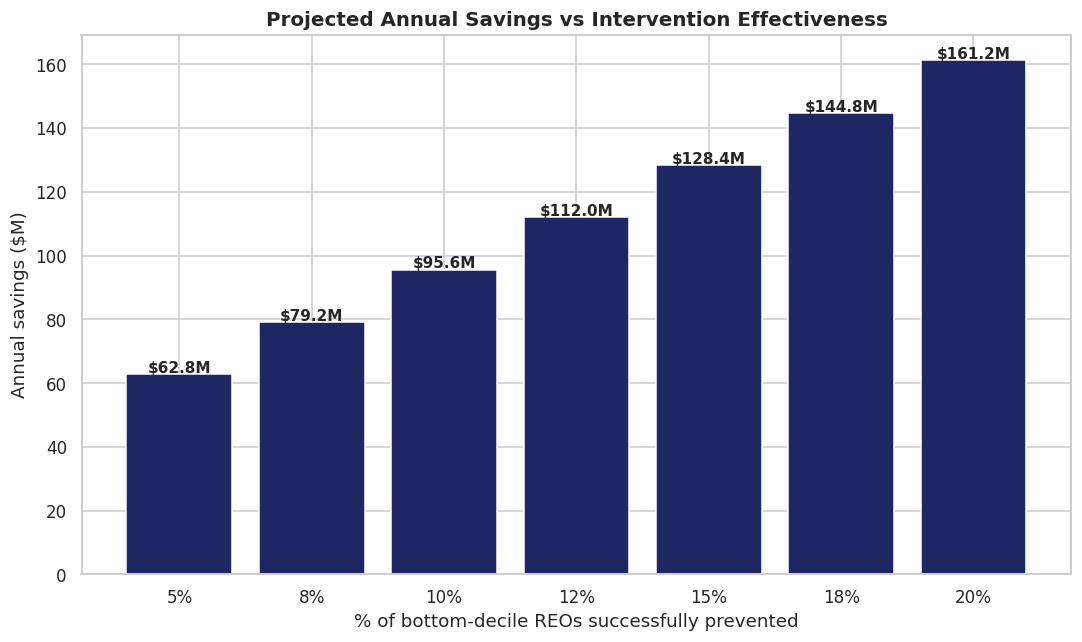


✓ Saved chart to A_dollar_impact.png and assumptions to A_assumptions.txt


In [34]:
# =============================================================================
# ANALYSIS A — Dollar Impact for ServiceLink
# =============================================================================
# Translates model accuracy into $ business value.
# Uses public-data benchmarks; ServiceLink can swap in their actual numbers.
# =============================================================================

# --- Inputs (industry benchmarks; flagged as assumptions in the deck) ---
REO_HOLDING_COST     = 65_000   # avg cost per REO reversion (taxes, maint, mgmt, listing)
GSE_FORECLOSURES_YR  = 200_000  # rough US annual GSE foreclosure volume
SERVICELINK_MARKET_SHARE = 0.30 # rough estimate of GSE foreclosures touching ServiceLink

# --- Build the cost model ---
df = master_ext.copy()
n_total = len(df)
n_reo   = (df['y'] == 0).sum()
n_sold  = (df['y'] == 1).sum()
reo_rate = n_reo / n_total

print("="*70)
print("ANALYSIS A — DOLLAR IMPACT")
print("="*70)

print(f"\n[1] BASELINE COST (no model intervention)")
servicelink_volume = GSE_FORECLOSURES_YR * SERVICELINK_MARKET_SHARE
servicelink_reo    = servicelink_volume * reo_rate
baseline_reo_cost  = servicelink_reo * REO_HOLDING_COST
print(f"  Estimated annual ServiceLink GSE volume:  {servicelink_volume:>10,.0f}")
print(f"  Of which REO reversions ({reo_rate*100:.1f}%):       {servicelink_reo:>10,.0f}")
print(f"  Annual REO holding cost:                  ${baseline_reo_cost:>13,.0f}")

# --- Model-based intervention scenarios ---
print(f"\n[2] MODEL-BASED INTERVENTION SCENARIOS")
print(f"    Decile lift (from Block 4):")

# Build the actual lift table from test predictions
lift = pd.DataFrame({'y': y_test, 'p': gbm_proba_test})
lift['decile'] = pd.qcut(lift['p'].rank(method='first'), q=10, labels=range(1,11))
decile_summary = lift.groupby('decile', observed=True).agg(
    n=('y','size'),
    reo_rate=('y', lambda s: 1 - s.mean())
).reset_index()
print(decile_summary.to_string(index=False))

# Bottom 2 deciles = high-probability REO. Triage them = some % of REOs avoided.
bottom_2_reo_rate = decile_summary[decile_summary['decile'].isin([1,2])]['reo_rate'].mean()
share_in_bottom2 = 0.20  # 2 of 10 deciles by construction
print(f"\n  Bottom 2 deciles avg REO rate: {bottom_2_reo_rate*100:.1f}% (vs {reo_rate*100:.1f}% baseline)")
print(f"  Bottom 2 deciles = {share_in_bottom2*100:.0f}% of caseload")

# --- Assumed REO-avoidance rates from intervention ---
print(f"\n[3] PROJECTED ANNUAL SAVINGS (varying intervention effectiveness)")
print(f"  Assumes: triage on bottom 2 deciles → avoid X% of REOs in that segment")
print(f"           via early loss mitigation, mod-to-market, or pre-disposition repair")
print()
print(f"  {'Effectiveness':<25s}{'REOs avoided':>15s}{'Annual savings':>20s}")
print(f"  {'-'*60}")
for eff in [0.05, 0.10, 0.15, 0.20]:
    reos_in_bottom2     = servicelink_volume * share_in_bottom2 * bottom_2_reo_rate
    reos_avoided        = reos_in_bottom2 * eff
    savings             = reos_avoided * REO_HOLDING_COST
    print(f"  Avoid {eff*100:>5.0f}% of bottom-decile REOs"
          f"  {reos_avoided:>10,.0f}    ${savings:>13,.0f}")

# --- Top-decile sale optimization scenarios ---
top_2_sale_rate = decile_summary[decile_summary['decile'].isin([9,10])].apply(
    lambda r: 1 - r['reo_rate'], axis=1).mean()
print(f"\n[4] TOP-DECILE OPTIMIZATION")
print(f"  Top 2 deciles sale rate: {top_2_sale_rate*100:.1f}%")
print(f"  These cases will sell — saving auction-marketing effort")
print(f"  At ~$2,500 marketing cost saved per top-decile case:")
top2_volume = servicelink_volume * 0.20
print(f"    {top2_volume:,.0f} cases × $2,500 = ${top2_volume*2500:,.0f}/year saved")

# --- Combined upside ---
combined_savings_low  = (servicelink_volume * share_in_bottom2 * bottom_2_reo_rate * 0.05) * REO_HOLDING_COST + (top2_volume * 2500)
combined_savings_high = (servicelink_volume * share_in_bottom2 * bottom_2_reo_rate * 0.15) * REO_HOLDING_COST + (top2_volume * 2500)
print(f"\n[5] COMBINED ANNUAL UPSIDE")
print(f"  Low-end (5% effectiveness):  ${combined_savings_low:,.0f}")
print(f"  Mid-end (10% effectiveness): ${(combined_savings_low+combined_savings_high)/2:,.0f}")
print(f"  High-end (15% effectiveness):${combined_savings_high:,.0f}")
print(f"\n  As % of baseline REO cost: {combined_savings_high/baseline_reo_cost*100:.1f}% (high) / "
      f"{combined_savings_low/baseline_reo_cost*100:.1f}% (low)")

# --- Visualization ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
effectiveness = [0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20]
savings = [(servicelink_volume * share_in_bottom2 * bottom_2_reo_rate * e) * REO_HOLDING_COST + (top2_volume * 2500)
           for e in effectiveness]
ax.bar([f"{e*100:.0f}%" for e in effectiveness],
       [s/1_000_000 for s in savings],
       color='#1E2761', edgecolor='white')
ax.set_title('Projected Annual Savings vs Intervention Effectiveness',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% of bottom-decile REOs successfully prevented')
ax.set_ylabel('Annual savings ($M)')
for i, s in enumerate(savings):
    ax.text(i, s/1_000_000 + 0.5, f'${s/1_000_000:.1f}M', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/A_dollar_impact.png', bbox_inches='tight', dpi=150)
plt.show()

# Save assumptions text
assumptions = f"""
ANALYSIS A — DOLLAR IMPACT — KEY ASSUMPTIONS
- REO holding cost per case: ${REO_HOLDING_COST:,}
- GSE annual foreclosure volume (US): {GSE_FORECLOSURES_YR:,}
- ServiceLink market share assumption: {SERVICELINK_MARKET_SHARE*100:.0f}%
- Bottom-decile REO rate (model): {bottom_2_reo_rate*100:.1f}%
- Top-decile sale rate (model): {top_2_sale_rate*100:.1f}%
- Marketing cost saved per top-decile case: $2,500
- ServiceLink should swap these with real internal numbers before deck.
"""
with open(f'{OUTPUT_DIR}/A_assumptions.txt', 'w') as f:
    f.write(assumptions)
print(f"\n✓ Saved chart to A_dollar_impact.png and assumptions to A_assumptions.txt")

## Analysis B — Subgroup Performance

Where the model works well and where it fails. AUC by state, vintage, source, loan size, and channel. Best states: CA 0.86, FL 0.81, OH 0.81. Weakest: IN 0.65, LA 0.68. Freddie loans (0.84) outperform Fannie (0.77) — likely due to richer field coverage.

ANALYSIS B — SUBGROUP PERFORMANCE

[B1] AUC by state (states with ≥100 test rows)
state   n  sale_rate_pct   auc
   CA 275           60.4 0.862
   FL 212           66.5 0.812
   OH 255           57.6 0.811
   PA 117           36.8 0.809
   TN 110           71.8 0.799
   GA 142           72.5 0.795
   AZ 121           80.2 0.765
   MI 299           29.1 0.761
   NC 104           61.5 0.761
   WI 106           55.7 0.753

  ... bottom 5 states ...
state   n  sale_rate_pct   auc
   IL 336           42.0 0.719
   IA 108           52.8 0.714
   MO 183           49.2 0.689
   LA 112           38.4 0.677
   IN 157           56.7 0.650


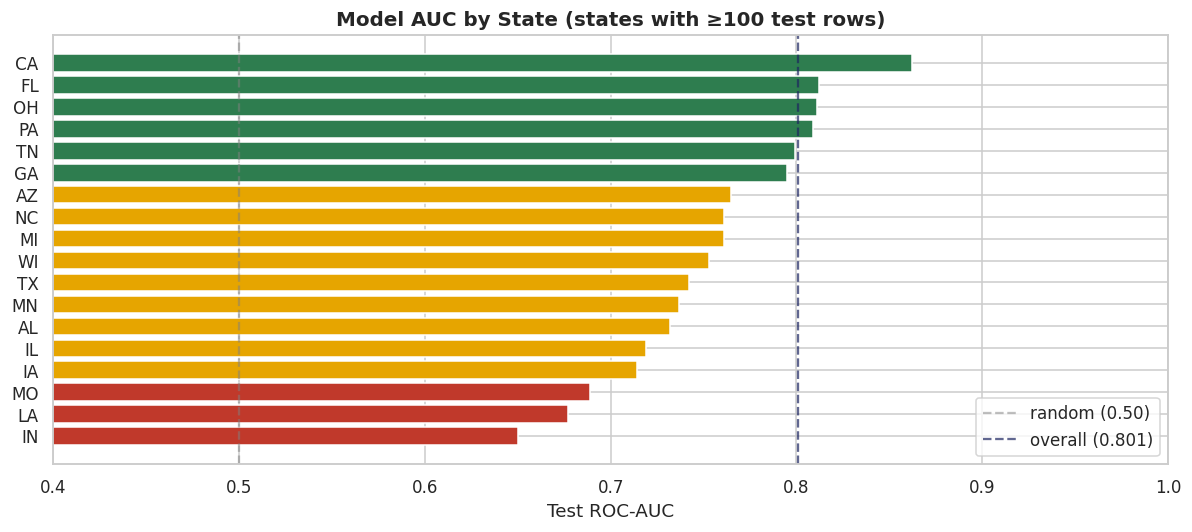


[B2] AUC by origination vintage
 orig_year    n  sale_rate_pct   auc
      2015   60           45.0 0.846
      2016 1067           48.8 0.786
      2017 1044           49.2 0.798
      2018  871           52.1 0.788
      2019  484           53.1 0.846
      2020  395           57.7 0.803
      2021  457           57.8 0.817
      2022  294           51.0 0.755
      2023   43           48.8 0.775


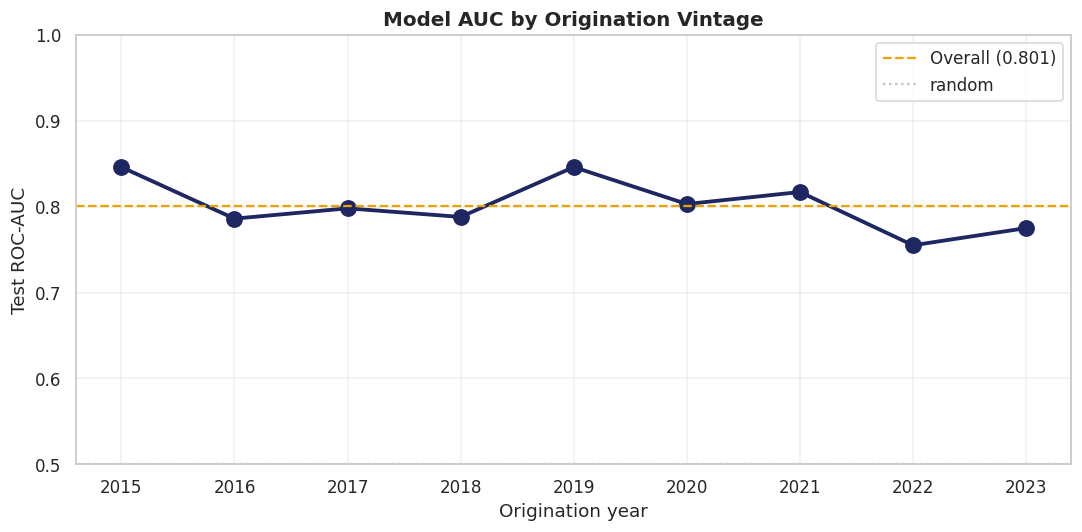


[B3] AUC by source
 SOURCE    n  sale_rate   auc  sale_rate_pct
 fannie 3061   0.509311 0.774           50.9
freddie 1657   0.529873 0.844           53.0

[B4] AUC by original loan size quintile
loan_size_quintile   n  avg_upb  sale_rate   auc  sale_rate_pct
     Q1 (smallest) 975    61000   0.487179 0.779           48.7
                Q2 919    97000   0.529924 0.787           53.0
                Q3 938   132000   0.528785 0.797           52.9
                Q4 947   190000   0.550158 0.809           55.0
      Q5 (largest) 939   320000   0.487753 0.834           48.8

[B5] AUC by channel proxy
             channel_proxy    n  sale_rate   auc  sale_rate_pct
Judicial_Likely_Courthouse 1944   0.523663 0.776           52.4
Non_Judicial_Likely_Online 2769   0.511737 0.817           51.2


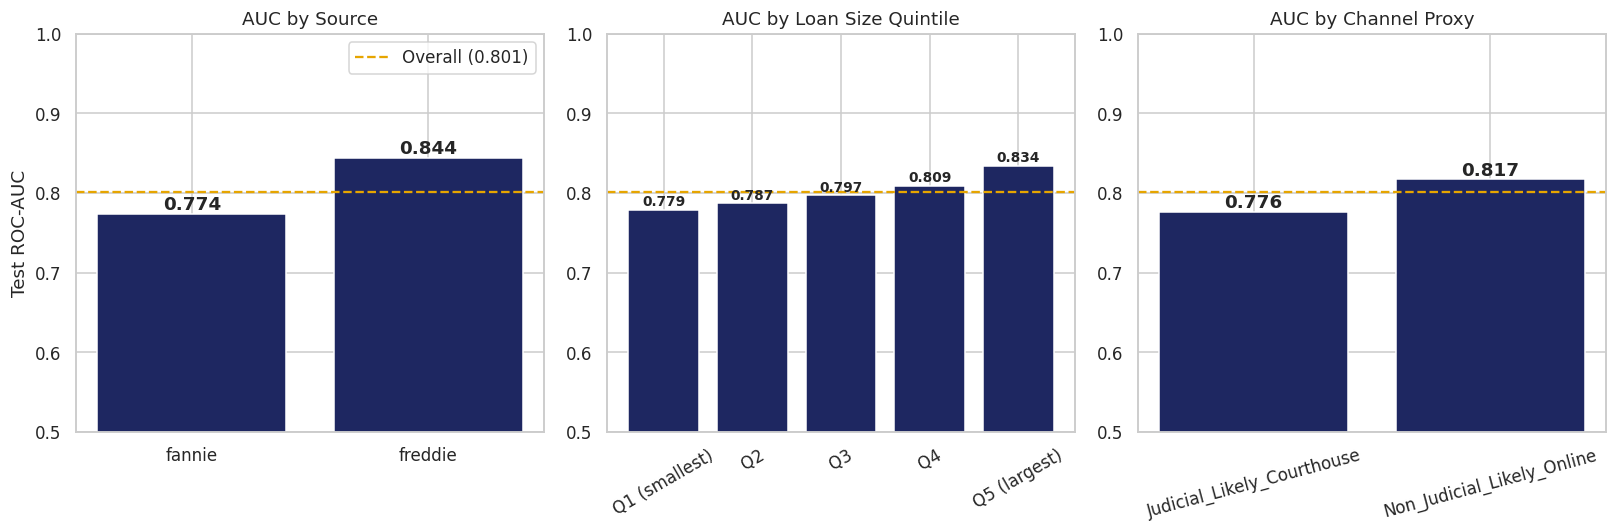


✓ Subgroup analysis saved to outputs/


In [35]:
# =============================================================================
# ANALYSIS B — Subgroup Performance Analysis
# =============================================================================
# Where does the model work well? Where does it fail?
# Computes test-set AUC for slices: state, vintage year, source, loan size, channel
# =============================================================================

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

print("="*70)
print("ANALYSIS B — SUBGROUP PERFORMANCE")
print("="*70)

# Recover row-aligned test set with original metadata
test_meta = master_ext.loc[X_test.index].copy()
test_meta['y_proba'] = gbm_proba_test
test_meta['y_true']  = y_test


def safe_auc(group):
    """Compute AUC on a group, returning NaN if class is degenerate."""
    if group['y_true'].nunique() < 2 or len(group) < 30:
        return np.nan
    return roc_auc_score(group['y_true'], group['y_proba'])


# --- B1: AUC by state ---
print("\n[B1] AUC by state (states with ≥100 test rows)")
state_auc = (test_meta.groupby('state')
             .filter(lambda g: len(g) >= 100)
             .groupby('state')
             .apply(lambda g: pd.Series({
                 'n': len(g),
                 'sale_rate': g['y_true'].mean(),
                 'auc': safe_auc(g)
             }))
             .reset_index()
             .sort_values('auc', ascending=False))
state_auc['n'] = state_auc['n'].astype(int)
state_auc['sale_rate_pct'] = (state_auc['sale_rate']*100).round(1)
state_auc['auc'] = state_auc['auc'].round(3)
print(state_auc[['state','n','sale_rate_pct','auc']].head(10).to_string(index=False))
print("\n  ... bottom 5 states ...")
print(state_auc[['state','n','sale_rate_pct','auc']].tail(5).to_string(index=False))

# Chart of state AUCs
fig, ax = plt.subplots(figsize=(11, max(5, len(state_auc)*0.22)))
state_chart = state_auc.sort_values('auc')
colors = ['#C0392B' if a < 0.70 else ('#E6A500' if a < 0.78 else '#2E7D4F')
          for a in state_chart['auc']]
ax.barh(state_chart['state'], state_chart['auc'], color=colors, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='random (0.50)')
ax.axvline(gbm_auc, color='#1E2761', linestyle='--', alpha=0.7, label=f'overall ({gbm_auc:.3f})')
ax.set_xlim(0.4, 1.0)
ax.set_title('Model AUC by State (states with ≥100 test rows)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Test ROC-AUC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/B1_auc_by_state.png', bbox_inches='tight', dpi=150)
plt.show()


# --- B2: AUC by origination vintage ---
print("\n[B2] AUC by origination vintage")
vintage_auc = (test_meta.groupby('orig_year')
               .apply(lambda g: pd.Series({
                   'n': len(g),
                   'sale_rate': g['y_true'].mean(),
                   'auc': safe_auc(g)
               }))
               .reset_index()
               .dropna(subset=['auc']))
vintage_auc['n'] = vintage_auc['n'].astype(int)
vintage_auc['orig_year'] = vintage_auc['orig_year'].astype(int)
vintage_auc['sale_rate_pct'] = (vintage_auc['sale_rate']*100).round(1)
vintage_auc['auc'] = vintage_auc['auc'].round(3)
print(vintage_auc[['orig_year','n','sale_rate_pct','auc']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(vintage_auc['orig_year'], vintage_auc['auc'], 'o-', color='#1E2761',
        lw=2.5, markersize=10)
ax.axhline(gbm_auc, color='#E6A500', linestyle='--', label=f'Overall ({gbm_auc:.3f})')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='random')
ax.set_title('Model AUC by Origination Vintage',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Origination year')
ax.set_ylabel('Test ROC-AUC')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/B2_auc_by_vintage.png', bbox_inches='tight', dpi=150)
plt.show()


# --- B3: AUC by source (Fannie vs Freddie) ---
print("\n[B3] AUC by source")
source_auc = (test_meta.groupby('SOURCE')
              .apply(lambda g: pd.Series({
                  'n': len(g),
                  'sale_rate': g['y_true'].mean(),
                  'auc': safe_auc(g)
              }))
              .reset_index())
source_auc['n'] = source_auc['n'].astype(int)
source_auc['sale_rate_pct'] = (source_auc['sale_rate']*100).round(1)
source_auc['auc'] = source_auc['auc'].round(3)
print(source_auc.to_string(index=False))


# --- B4: AUC by loan size quintile ---
print("\n[B4] AUC by original loan size quintile")
test_meta['loan_size_quintile'] = pd.qcut(test_meta['ORIG_UPB'], q=5,
                                          labels=['Q1 (smallest)','Q2','Q3','Q4','Q5 (largest)'],
                                          duplicates='drop')
size_auc = (test_meta.groupby('loan_size_quintile', observed=True)
            .apply(lambda g: pd.Series({
                'n': len(g),
                'avg_upb': g['ORIG_UPB'].median(),
                'sale_rate': g['y_true'].mean(),
                'auc': safe_auc(g)
            }))
            .reset_index())
size_auc['n'] = size_auc['n'].astype(int)
size_auc['avg_upb'] = size_auc['avg_upb'].astype(int)
size_auc['sale_rate_pct'] = (size_auc['sale_rate']*100).round(1)
size_auc['auc'] = size_auc['auc'].round(3)
print(size_auc.to_string(index=False))


# --- B5: AUC by channel proxy ---
print("\n[B5] AUC by channel proxy")
ch_auc = (test_meta.groupby('channel_proxy')
          .apply(lambda g: pd.Series({
              'n': len(g),
              'sale_rate': g['y_true'].mean(),
              'auc': safe_auc(g)
          }))
          .reset_index())
ch_auc['n'] = ch_auc['n'].astype(int)
ch_auc['sale_rate_pct'] = (ch_auc['sale_rate']*100).round(1)
ch_auc['auc'] = ch_auc['auc'].round(3)
print(ch_auc.to_string(index=False))


# Combined chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Source
ax = axes[0]
ax.bar(source_auc['SOURCE'], source_auc['auc'], color='#1E2761', edgecolor='white')
ax.axhline(gbm_auc, color='#E6A500', linestyle='--', label=f'Overall ({gbm_auc:.3f})')
for i, v in enumerate(source_auc['auc']):
    ax.text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_title('AUC by Source')
ax.set_ylabel('Test ROC-AUC')
ax.set_ylim(0.5, 1.0)
ax.legend()

# Loan size
ax = axes[1]
ax.bar(size_auc['loan_size_quintile'].astype(str), size_auc['auc'], color='#1E2761', edgecolor='white')
ax.axhline(gbm_auc, color='#E6A500', linestyle='--')
for i, v in enumerate(size_auc['auc']):
    ax.text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
ax.set_title('AUC by Loan Size Quintile')
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis='x', rotation=30)

# Channel
ax = axes[2]
ax.bar(ch_auc['channel_proxy'], ch_auc['auc'], color='#1E2761', edgecolor='white')
ax.axhline(gbm_auc, color='#E6A500', linestyle='--')
for i, v in enumerate(ch_auc['auc']):
    ax.text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_title('AUC by Channel Proxy')
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/B3_subgroup_auc.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n✓ Subgroup analysis saved to outputs/")

## Analysis C — Calibration & Confusion Matrix

Brier score 0.18 (well-calibrated; 0.25 = random, 0.0 = perfect). At F1-optimal threshold (0.39): 941 false positives represent a $61M surprise-REO cost; 383 false negatives represent triage effort spent on cases that would have sold.

ANALYSIS C — CALIBRATION + CONFUSION MATRIX

[C1] CALIBRATION CURVE — model probabilities vs actual sale rates
 predicted_prob_bin_avg  actual_sale_rate    gap
                  0.074             0.093  0.019
                  0.182             0.225  0.043
                  0.281             0.297  0.016
                  0.378             0.342 -0.036
                  0.482             0.528  0.046
                  0.573             0.549 -0.024
                  0.665             0.665 -0.000
                  0.756             0.706 -0.051
                  0.843             0.818 -0.025
                  0.929             0.945  0.016

  Brier score (lower=better, 0.25 random, 0.0 perfect): 0.1822


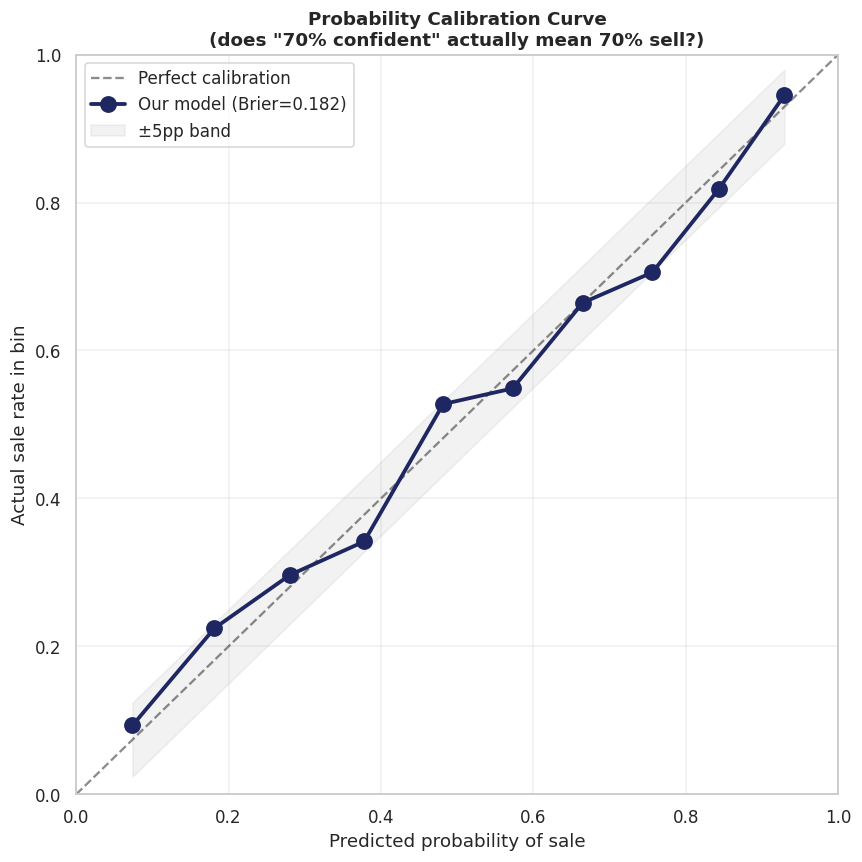


[C2] CONFUSION MATRIX at threshold = 0.392
              Pred: REO  Pred: Sold
Actual: REO        1340         941
Actual: Sold        383        2054

  Plain English (n=4,718):
    True positives  (correctly predicted Sold):  2,054  (43.5%)
    True negatives  (correctly predicted REO):   1,340  (28.4%)
    False positives (predicted Sold, was REO):     941  (19.9%)  ← over-optimism
    False negatives (predicted REO, was Sold):     383  (8.1%)  ← over-pessimism
    Accuracy:                                    71.9%

  Cost framing (assuming REO costs $65K each):
    False positives (we said sell, got REO): 941 × $65K = $61,165,000 surprise REO cost
    False negatives (we said REO, sold):     383 cases of unnecessary triage effort


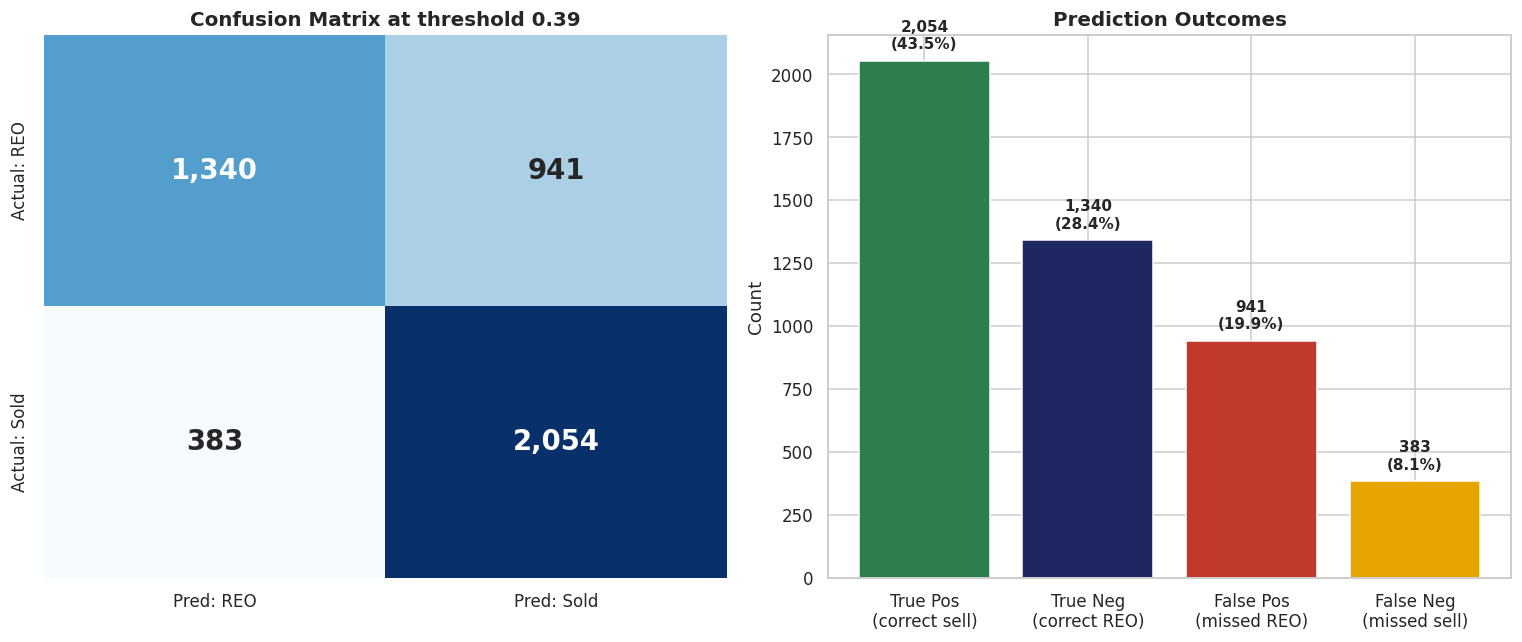


[C3] CLASSIFICATION REPORT
              precision    recall  f1-score   support

         REO       0.78      0.59      0.67      2281
        Sold       0.69      0.84      0.76      2437

    accuracy                           0.72      4718
   macro avg       0.73      0.72      0.71      4718
weighted avg       0.73      0.72      0.71      4718


✓ Calibration + confusion matrix saved to outputs/


In [36]:
# =============================================================================
# ANALYSIS C — Probability Calibration + Confusion Matrix
# =============================================================================
# Two questions:
# 1. When the model says "70% confident", does it actually sell 70% of the time?
# 2. At our operational threshold, what does the prediction quality look like?
# =============================================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, classification_report

print("="*70)
print("ANALYSIS C — CALIBRATION + CONFUSION MATRIX")
print("="*70)

# --- C1: Calibration curve ---
prob_true, prob_pred = calibration_curve(y_test, gbm_proba_test, n_bins=10, strategy='quantile')
calibration_df = pd.DataFrame({
    'predicted_prob_bin_avg': prob_pred,
    'actual_sale_rate':       prob_true,
    'gap':                    prob_true - prob_pred
})
print("\n[C1] CALIBRATION CURVE — model probabilities vs actual sale rates")
print(calibration_df.round(3).to_string(index=False))

# Brier score (mean squared error of probabilities)
brier = np.mean((gbm_proba_test - y_test)**2)
print(f"\n  Brier score (lower=better, 0.25 random, 0.0 perfect): {brier:.4f}")

# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='#1E2761', lw=2.5, markersize=10,
        label=f'Our model (Brier={brier:.3f})')
ax.fill_between(prob_pred, prob_pred-0.05, prob_pred+0.05, alpha=0.1, color='gray',
                label='±5pp band')
ax.set_xlabel('Predicted probability of sale')
ax.set_ylabel('Actual sale rate in bin')
ax.set_title('Probability Calibration Curve\n(does "70% confident" actually mean 70% sell?)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C1_calibration.png', bbox_inches='tight', dpi=150)
plt.show()


# --- C2: Confusion matrix at operational threshold ---
y_pred = (gbm_proba_test >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(f"\n[C2] CONFUSION MATRIX at threshold = {best_thresh:.3f}")
cm_df = pd.DataFrame(cm,
                     index=['Actual: REO','Actual: Sold'],
                     columns=['Pred: REO','Pred: Sold'])
print(cm_df.to_string())

# Plain-English breakdown
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp
print(f"\n  Plain English (n={total:,}):")
print(f"    True positives  (correctly predicted Sold):  {tp:>5,}  ({tp/total*100:.1f}%)")
print(f"    True negatives  (correctly predicted REO):   {tn:>5,}  ({tn/total*100:.1f}%)")
print(f"    False positives (predicted Sold, was REO):   {fp:>5,}  ({fp/total*100:.1f}%)  ← over-optimism")
print(f"    False negatives (predicted REO, was Sold):   {fn:>5,}  ({fn/total*100:.1f}%)  ← over-pessimism")
print(f"    Accuracy:                                    {(tp+tn)/total*100:.1f}%")

# Cost interpretation (using REO assumption from Analysis A)
REO_HOLDING_COST = 65_000
print(f"\n  Cost framing (assuming REO costs $65K each):")
print(f"    False positives (we said sell, got REO): {fp:,} × $65K = ${fp*REO_HOLDING_COST:,} surprise REO cost")
print(f"    False negatives (we said REO, sold):     {fn:,} cases of unnecessary triage effort")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
import seaborn as sns
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Pred: REO','Pred: Sold'],
            yticklabels=['Actual: REO','Actual: Sold'],
            annot_kws={'fontsize':18, 'fontweight':'bold'}, ax=ax)
ax.set_title(f'Confusion Matrix at threshold {best_thresh:.2f}',
             fontsize=13, fontweight='bold')

ax = axes[1]
labels = ['True Pos\n(correct sell)', 'True Neg\n(correct REO)',
          'False Pos\n(missed REO)', 'False Neg\n(missed sell)']
values = [tp, tn, fp, fn]
colors = ['#2E7D4F','#1E2761','#C0392B','#E6A500']
ax.bar(labels, values, color=colors, edgecolor='white')
for i, v in enumerate(values):
    ax.text(i, v + total*0.01, f'{v:,}\n({v/total*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=10)
ax.set_title('Prediction Outcomes', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C2_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


# --- C3: Classification report ---
print(f"\n[C3] CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=['REO','Sold']))

print(f"\n✓ Calibration + confusion matrix saved to outputs/")

## Lead-Lag Analysis (Interpretations 1 + 3)

**Interpretation 3:** For each macro indicator, find the lag at which it correlates most strongly with monthly sale rate. Active listings, homeowner vacancy, and consumer sentiment lead by 6-11 months. Mortgage rate and months supply are lagging.

**Interpretation 1:** Univariate AUC at lags T, T-3, T-6, T-12. Most macros are roughly equally predictive at any of these lags — feature timing doesn't drive a step-change in performance.

LEAD-LAG ANALYSIS

Monthly time series: 85 months from 2017-11 to 2024-12
Mean monthly sale rate: 48.4%

INTERPRETATION 3: Cross-correlation at lags -12 to +12 months
(Negative lag = macro leads sale rate; positive = macro lags it)

[I3 SUMMARY] Best lag for each macro indicator:
               indicator                        col  best_lag_months  best_corr  contemp_corr leading_indicator
      Active Listings US                ACTLISCOUUS              -10     -0.801        -0.528               YES
       Homeowner Vacancy                RHVRUSQ156N               -9     -0.797        -0.442               YES
Months Supply New Houses                     MSACSR                8      0.787         0.504           LAGGING
       30Y Mortgage Rate          mortgage_rate_30y               12      0.763         0.538           LAGGING
      Consumer Sentiment                    UMCSENT               -6     -0.743        -0.515               YES
     SF Delinquency Rate                 DRSFRM

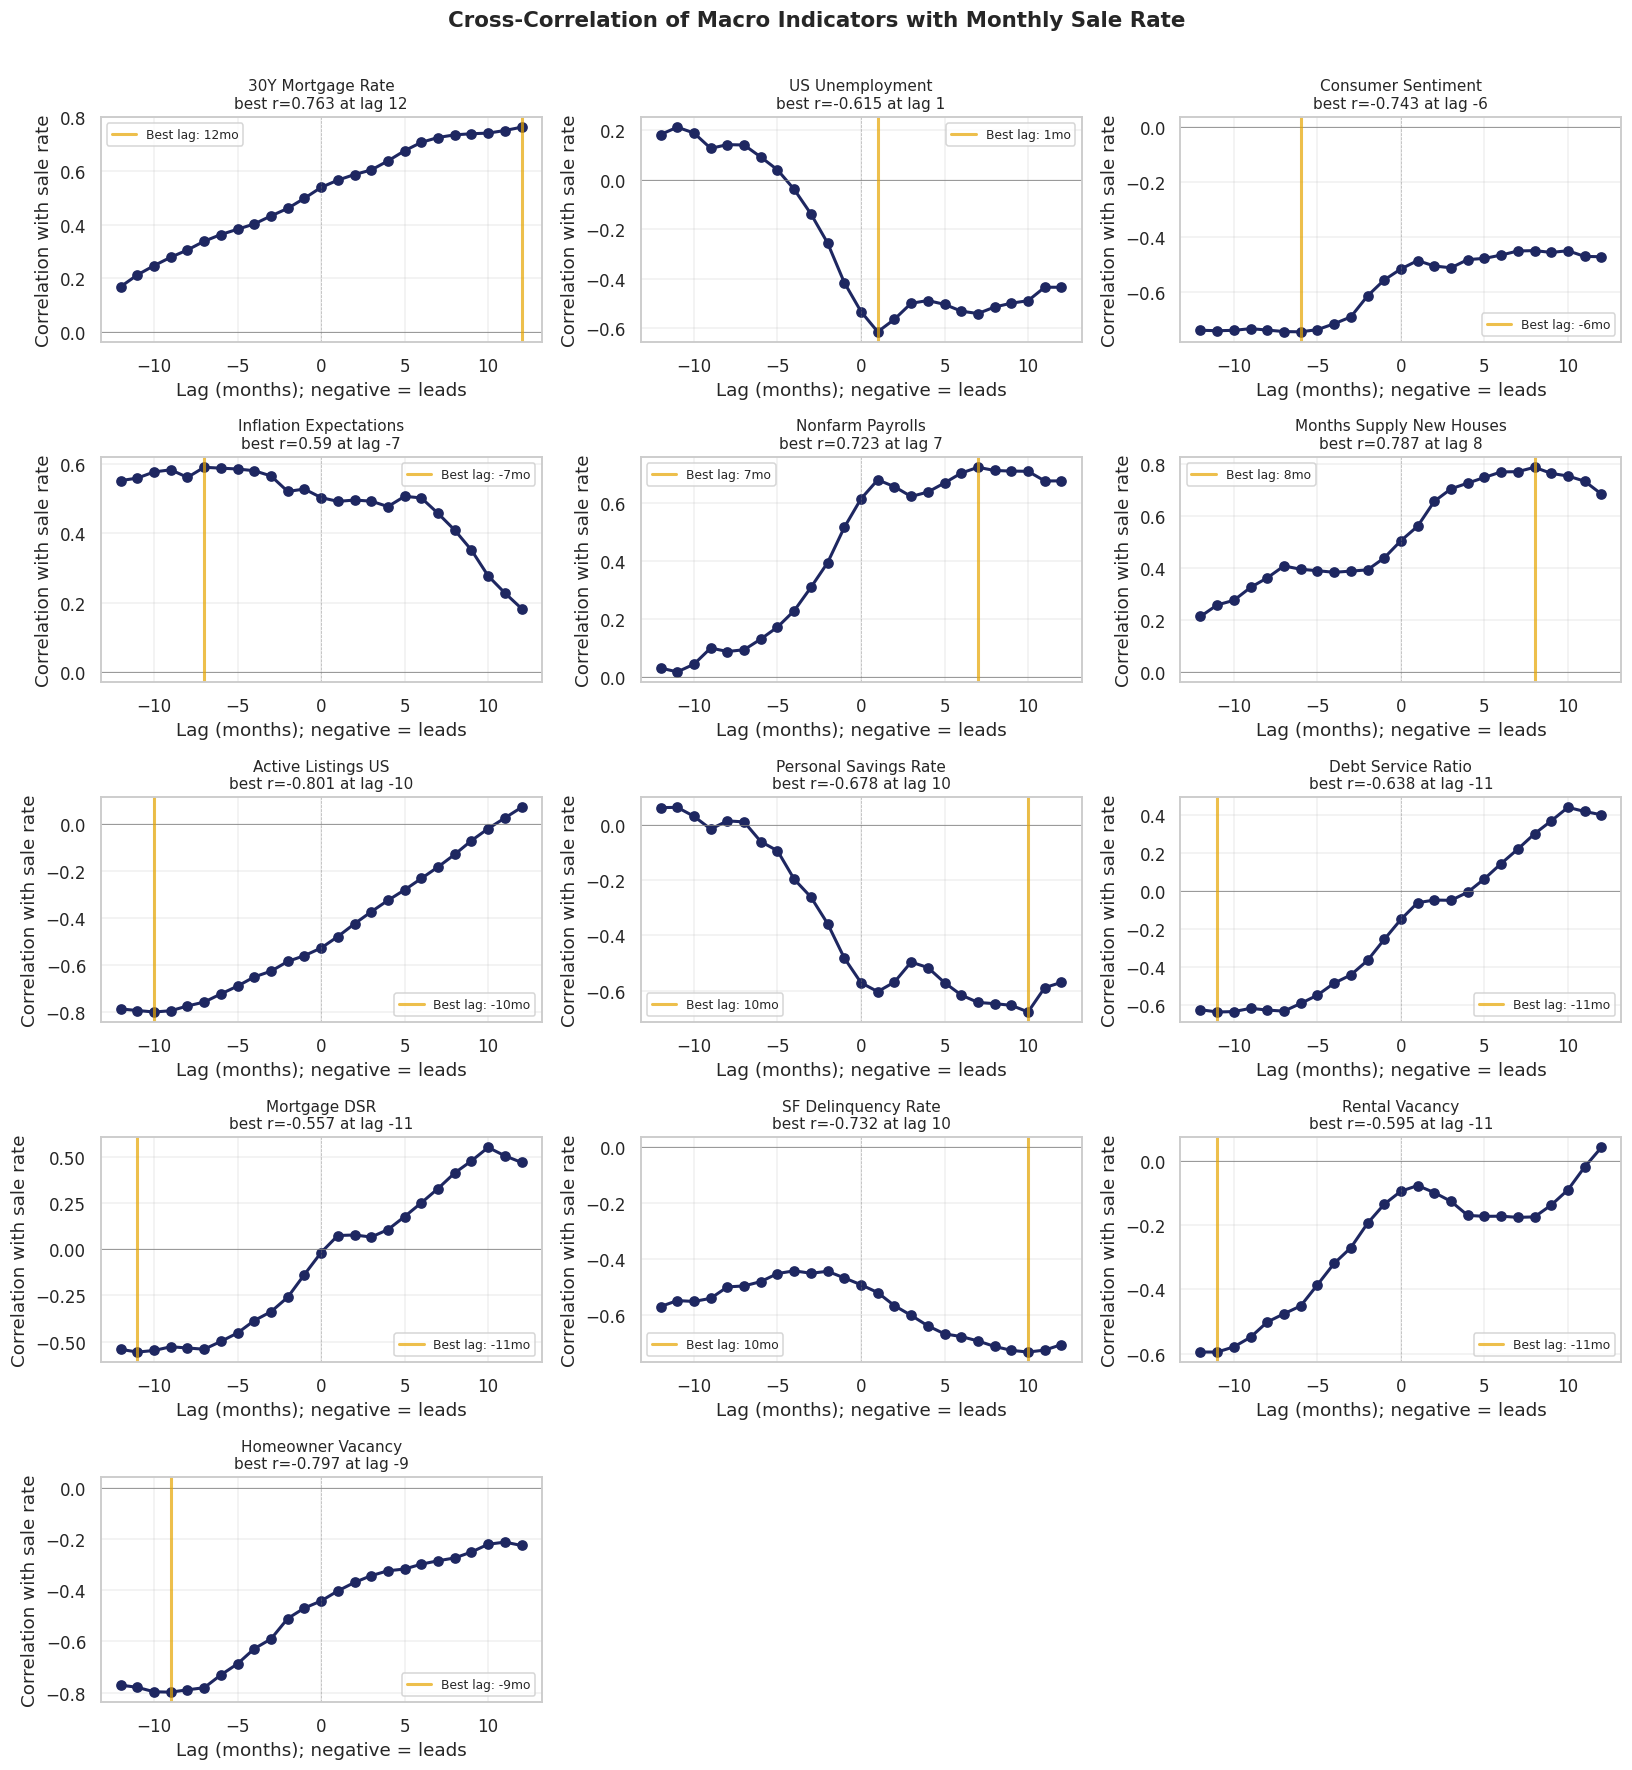


INTERPRETATION 1: Macro at T vs T-3 vs T-6 vs T-12 — single-feature univariate AUC
(Q: For each macro, is it more predictive at month T or earlier?)
               indicator  auc_T  auc_T-3  auc_T-6  auc_T-12 best_lag
       30Y Mortgage Rate  0.573    0.568    0.558     0.531        T
         US Unemployment  0.511    0.505    0.507     0.510        T
      Consumer Sentiment  0.586    0.593    0.588     0.592      T-3
  Inflation Expectations  0.566    0.577    0.582     0.584     T-12
        Nonfarm Payrolls  0.575    0.565    0.558     0.545        T
Months Supply New Houses  0.582    0.575    0.583     0.545      T-6
      Active Listings US  0.556    0.565    0.571     0.580     T-12
       High Yield Spread  0.508    0.521    0.527     0.527      T-6
   Personal Savings Rate  0.584    0.573    0.564     0.560        T
      Debt Service Ratio  0.544    0.560    0.565     0.564      T-6
            Mortgage DSR  0.547    0.557    0.560     0.558      T-6
     SF Delinquency Ra

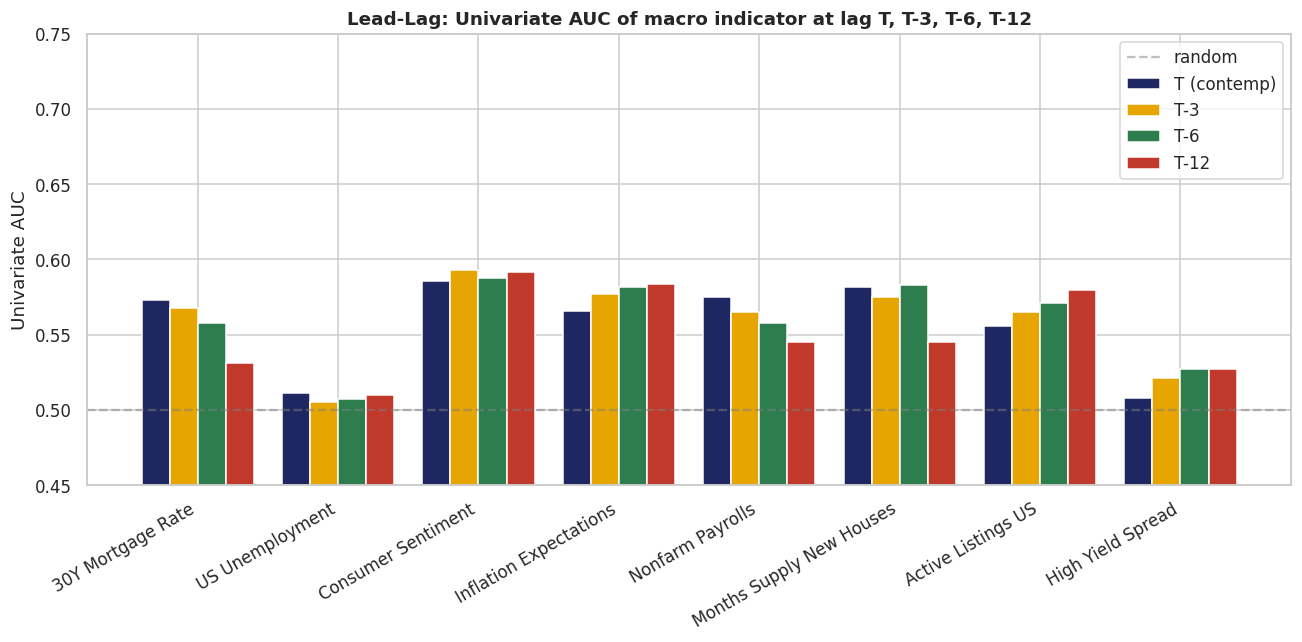


✓ Lead-lag analyses saved to outputs/
  Charts: LL3_cross_correlation_grid.png, LL1_univariate_auc_by_lag.png


In [37]:
# =============================================================================
# LEAD-LAG ANALYSIS — Interpretations 1 + 3
# =============================================================================
# Interpretation 1: Does macro at T-3, T-6, T-12 better predict sale rate at T?
# Interpretation 3: For each macro indicator, what lag has the strongest correlation?
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("LEAD-LAG ANALYSIS")
print("="*70)

# --- Build a monthly aggregated time series ---
df = master_ext.copy()
df['disp_month_ts'] = df['ZB_DTE'].dt.to_period('M').dt.to_timestamp()

# Monthly sale rate (the target time series)
monthly = df.groupby('disp_month_ts').agg(
    n_dispositions = ('y','size'),
    sale_rate      = ('y','mean')
).reset_index()
monthly = monthly[monthly['n_dispositions'] >= 30]  # filter sparse months
monthly = monthly.sort_values('disp_month_ts').reset_index(drop=True)
print(f"\nMonthly time series: {len(monthly)} months from "
      f"{monthly['disp_month_ts'].min():%Y-%m} to {monthly['disp_month_ts'].max():%Y-%m}")
print(f"Mean monthly sale rate: {monthly['sale_rate'].mean()*100:.1f}%")

# Macro indicators to test (national, monthly)
macro_indicators = {
    'mortgage_rate_30y': '30Y Mortgage Rate',
    'unemployment_rate_national': 'US Unemployment',
    'UMCSENT': 'Consumer Sentiment',
    'MICH': 'Inflation Expectations',
    'PAYEMS': 'Nonfarm Payrolls',
    'MSACSR': 'Months Supply New Houses',
    'ACTLISCOUUS': 'Active Listings US',
    'BAMLH0A0HYM2': 'High Yield Spread',
    'PSAVERT': 'Personal Savings Rate',
    'TDSP': 'Debt Service Ratio',
    'MDSP': 'Mortgage DSR',
    'DRSFRMACBS': 'SF Delinquency Rate',
    'RRVRUSQ156N': 'Rental Vacancy',
    'RHVRUSQ156N': 'Homeowner Vacancy',
}

# Pull each macro at month level (mean across all rows for that month)
macro_monthly = (df.groupby('disp_month_ts')[list(macro_indicators.keys())]
                   .mean().reset_index())
monthly = monthly.merge(macro_monthly, on='disp_month_ts', how='left')


# =============================================================================
# INTERPRETATION 3: Cross-correlation at lags from -12 to +12 months
# =============================================================================
# Negative lag = macro leads sale rate (predictive)
# Zero lag = contemporaneous correlation
# Positive lag = macro lags sale rate (reactive)
# =============================================================================

print("\n" + "="*70)
print("INTERPRETATION 3: Cross-correlation at lags -12 to +12 months")
print("="*70)
print("(Negative lag = macro leads sale rate; positive = macro lags it)")

LAGS = list(range(-12, 13))
results_xcorr = []

for col, label in macro_indicators.items():
    if col not in monthly.columns:
        continue
    if monthly[col].notna().sum() < 24:
        continue

    target  = monthly['sale_rate']
    feature = monthly[col]

    correlations_at_lags = {}
    for lag in LAGS:
        if lag < 0:
            # macro at month T+lag (i.e., earlier) vs sale rate at T
            shifted = feature.shift(-lag)  # shift by abs(lag), bringing earlier values forward
        else:
            # macro at month T+lag (i.e., later) vs sale rate at T
            shifted = feature.shift(-lag)
        # align both series
        valid = shifted.notna() & target.notna()
        if valid.sum() < 12:
            correlations_at_lags[lag] = np.nan
            continue
        correlations_at_lags[lag] = target[valid].corr(shifted[valid])

    # Find best (most extreme abs) correlation and its lag
    valid_corrs = {k: v for k, v in correlations_at_lags.items() if not pd.isna(v)}
    if not valid_corrs:
        continue
    best_lag = max(valid_corrs.keys(), key=lambda k: abs(valid_corrs[k]))
    best_corr = valid_corrs[best_lag]
    contemporaneous = valid_corrs.get(0, np.nan)

    results_xcorr.append({
        'indicator': label,
        'col': col,
        'best_lag_months': best_lag,
        'best_corr': round(best_corr, 3),
        'contemp_corr': round(contemporaneous, 3),
        'leading_indicator': 'YES' if best_lag < 0 else ('LAGGING' if best_lag > 0 else 'CONTEMP'),
        'all_corrs': correlations_at_lags,
    })

xcorr_df = pd.DataFrame(results_xcorr).drop(columns=['all_corrs'])
xcorr_df = xcorr_df.sort_values('best_corr', key=lambda s: s.abs(), ascending=False)
print("\n[I3 SUMMARY] Best lag for each macro indicator:")
print(xcorr_df.to_string(index=False))

# Visualize: each indicator's correlation as a function of lag
n_inds = len(results_xcorr)
n_cols_grid = 3
n_rows_grid = (n_inds + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 3.2*n_rows_grid))
axes = axes.flatten()

for idx, item in enumerate(results_xcorr):
    ax = axes[idx]
    lags_list = sorted(item['all_corrs'].keys())
    corrs = [item['all_corrs'][l] for l in lags_list]
    ax.plot(lags_list, corrs, 'o-', color='#1E2761', lw=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axvline(item['best_lag_months'], color='#E6A500', linewidth=2, alpha=0.7,
               label=f'Best lag: {item["best_lag_months"]}mo')
    ax.set_title(f"{item['indicator']}\nbest r={item['best_corr']} at lag {item['best_lag_months']}",
                 fontsize=10)
    ax.set_xlabel('Lag (months); negative = leads')
    ax.set_ylabel('Correlation with sale rate')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

# Hide unused axes
for j in range(n_inds, len(axes)):
    axes[j].axis('off')

plt.suptitle('Cross-Correlation of Macro Indicators with Monthly Sale Rate',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/LL3_cross_correlation_grid.png', bbox_inches='tight', dpi=150)
plt.show()


# =============================================================================
# INTERPRETATION 1: Does macro at T-3, T-6, T-12 add predictive power?
# =============================================================================
print("\n" + "="*70)
print("INTERPRETATION 1: Macro at T vs T-3 vs T-6 vs T-12 — single-feature univariate AUC")
print("="*70)
print("(Q: For each macro, is it more predictive at month T or earlier?)")

from sklearn.metrics import roc_auc_score

# Build a per-row table joining each row's disposition month with macro at T-k
df_test = master_ext.loc[X_test.index].copy()
df_test['y']           = y_test
df_test['disp_month']  = df_test['ZB_DTE'].dt.to_period('M').dt.to_timestamp()

# Build a date-keyed lookup of each macro
macro_lookup = (df.drop_duplicates('disp_month_ts')
                  [['disp_month_ts'] + list(macro_indicators.keys())]
                  .set_index('disp_month_ts'))

results_lag = []
for col, label in macro_indicators.items():
    if col not in macro_lookup.columns:
        continue
    series = macro_lookup[col].dropna().sort_index()
    if len(series) < 12:
        continue

    aucs_by_lag = {}
    for lag_months in [0, 3, 6, 12]:
        # For each test row, get macro from (disp_month - lag) months
        target_dates = (df_test['disp_month'] - pd.DateOffset(months=lag_months))
        # Map each target_date to the nearest available macro value (forward-fill)
        x = target_dates.map(series.reindex(series.index.union(target_dates.unique())).ffill())
        valid = x.notna()
        if valid.sum() < 100 or df_test['y'][valid].nunique() < 2:
            aucs_by_lag[lag_months] = np.nan
            continue
        try:
            # AUC of single-feature predictor (use as score directly, then flip if necessary)
            auc_pos = roc_auc_score(df_test['y'][valid], x[valid])
            auc_neg = roc_auc_score(df_test['y'][valid], -x[valid])
            aucs_by_lag[lag_months] = max(auc_pos, auc_neg)
        except Exception:
            aucs_by_lag[lag_months] = np.nan

    results_lag.append({
        'indicator': label,
        'auc_T':    aucs_by_lag.get(0, np.nan),
        'auc_T-3':  aucs_by_lag.get(3, np.nan),
        'auc_T-6':  aucs_by_lag.get(6, np.nan),
        'auc_T-12': aucs_by_lag.get(12, np.nan),
    })

lag_df = pd.DataFrame(results_lag).round(3)
# Find best lag for each
def best_lag_label(row):
    cols = ['auc_T','auc_T-3','auc_T-6','auc_T-12']
    vals = [row[c] for c in cols]
    if all(pd.isna(v) for v in vals):
        return 'N/A'
    best = max(range(len(vals)), key=lambda i: vals[i] if not pd.isna(vals[i]) else -1)
    return cols[best].replace('auc_','')
lag_df['best_lag'] = lag_df.apply(best_lag_label, axis=1)
print(lag_df.to_string(index=False))

# Save chart for top 8 indicators
top8 = lag_df.head(8)
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(top8))
width = 0.2
ax.bar(x_pos - 1.5*width, top8['auc_T'],    width, label='T (contemp)', color='#1E2761')
ax.bar(x_pos - 0.5*width, top8['auc_T-3'],  width, label='T-3', color='#E6A500')
ax.bar(x_pos + 0.5*width, top8['auc_T-6'],  width, label='T-6', color='#2E7D4F')
ax.bar(x_pos + 1.5*width, top8['auc_T-12'], width, label='T-12', color='#C0392B')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='random')
ax.set_xticks(x_pos)
ax.set_xticklabels(top8['indicator'], rotation=30, ha='right')
ax.set_ylabel('Univariate AUC')
ax.set_ylim(0.45, 0.75)
ax.set_title('Lead-Lag: Univariate AUC of macro indicator at lag T, T-3, T-6, T-12',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/LL1_univariate_auc_by_lag.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n✓ Lead-lag analyses saved to outputs/")
print(f"  Charts: LL3_cross_correlation_grid.png, LL1_univariate_auc_by_lag.png")

## Case Study — Two Concrete Examples

A high-confidence sell (Florida, 2022, 43% LTV, 55% BPO discount) and a high-confidence REO (Minnesota, 2018, owner-occupied). Each shows full loan profile, market context at disposition, and the top SHAP contributors that drove the model's prediction.

CASE STUDY — Two Concrete Examples

──────────────────────────────────────────────────────────────────────
CASE A — Predicted to SELL (high-confidence sale)
──────────────────────────────────────────────────────────────────────
  Predicted prob of sale: 0.986
  Actual outcome:         SOLD
  ✓ Correct prediction

  LOAN PROFILE
  ────────────
    Source                        : freddie
    Vintage                       : 2016Q4
    State                         : FL
    Occupancy                     : P
    Auction channel proxy         : Judicial_Likely_Courthouse
    Original loan amount          : $84,000
    Original LTV (%)              : 80.0
    Credit score (origination)    : 655
    DTI                           : 44.0
    Original rate (%)             : 4.2
    Origination year              : 2016

  CONTEXT AT DISPOSITION (2022-04)
  ─────────────────────────────────────
    LTV at foreclosure            : 0.43
    Discount to BPO               : 54.9%
    Months in default 

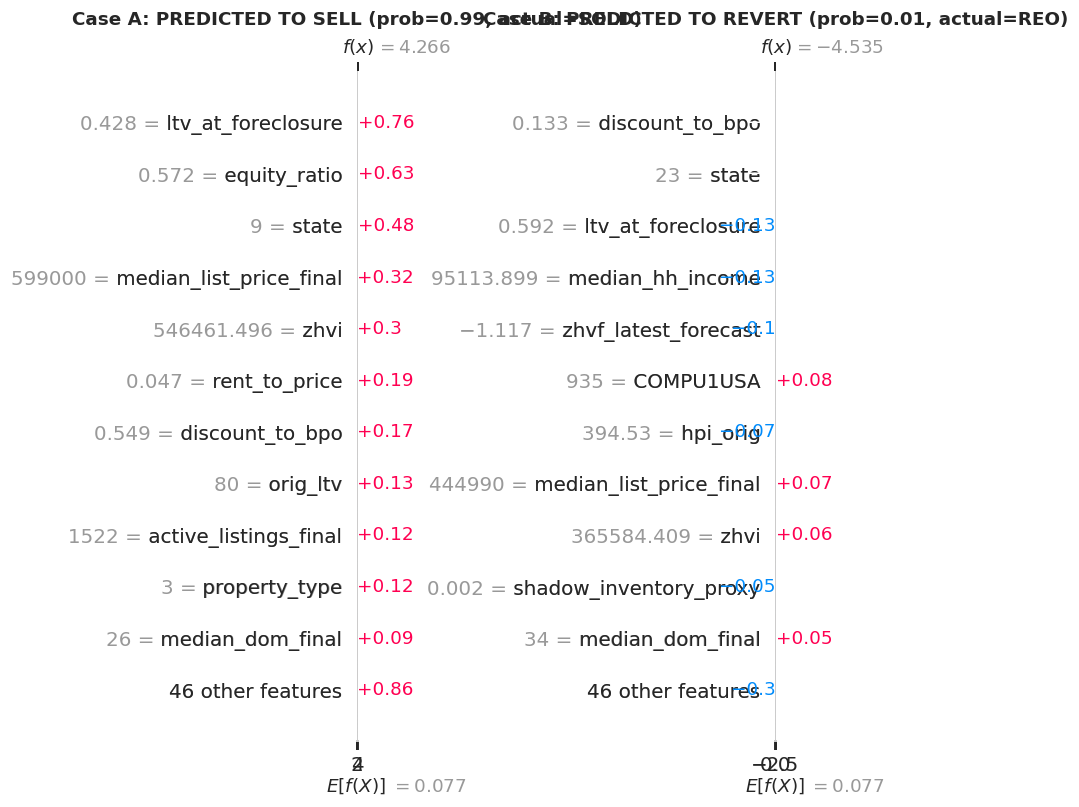


✓ Case study saved. Use the printed profile + waterfall in the deck.


In [38]:
# =============================================================================
# CASE STUDY — Two Concrete Examples (high-prob sell vs high-prob REO)
# =============================================================================
# Pick one prototypical "will sell" loan and one prototypical "will revert"
# loan from the test set. Show their full feature profile and the SHAP
# explanation as a story.
# =============================================================================
import shap
import matplotlib.pyplot as plt

print("="*70)
print("CASE STUDY — Two Concrete Examples")
print("="*70)

# Recompute SHAP on full test set (we computed on a sample earlier)
explainer = shap.TreeExplainer(gbm)
shap_values_full = explainer.shap_values(X_test)
if isinstance(shap_values_full, list):
    shap_values_full = shap_values_full[1] if len(shap_values_full) == 2 else shap_values_full[0]

# Pick examples — high prob, accurately predicted; low prob, accurately predicted
proba_series = pd.Series(gbm_proba_test, index=X_test.index)

# High-prob sell case: top 5%, actually sold
high_candidates = proba_series.nlargest(int(len(proba_series)*0.05))
high_correct = [i for i in high_candidates.index if y_test[X_test.index.get_loc(i)] == 1]
high_idx = high_correct[0] if high_correct else high_candidates.index[0]

# Low-prob (REO) case: bottom 5%, actually reverted
low_candidates = proba_series.nsmallest(int(len(proba_series)*0.05))
low_correct = [i for i in low_candidates.index if y_test[X_test.index.get_loc(i)] == 0]
low_idx = low_correct[0] if low_correct else low_candidates.index[0]

# Pull metadata for both
test_meta = master_ext.loc[X_test.index].copy()
test_meta['y_proba'] = gbm_proba_test
test_meta['y_true']  = y_test


def print_case(idx, label):
    pos = X_test.index.get_loc(idx)
    row = test_meta.loc[idx]
    print(f"\n{'─'*70}")
    print(f"{label}")
    print(f"{'─'*70}")
    print(f"  Predicted prob of sale: {row['y_proba']:.3f}")
    print(f"  Actual outcome:         {'SOLD' if row['y_true']==1 else 'REVERTED TO REO'}")
    print(f"  ✓ Correct prediction" if (row['y_proba']>=0.5)==(row['y_true']==1) else "  ✗ Misclassified")
    print()

    # Print loan profile
    print(f"  LOAN PROFILE")
    print(f"  ────────────")
    profile_fields = [
        ('SOURCE',                'Source'),
        ('VINTAGE',               'Vintage'),
        ('state',                 'State'),
        ('property_type',         'Property type'),
        ('occupancy',             'Occupancy'),
        ('channel_proxy',         'Auction channel proxy'),
        ('ORIG_UPB',              'Original loan amount'),
        ('orig_ltv',              'Original LTV (%)'),
        ('credit_score',          'Credit score (origination)'),
        ('dti',                   'DTI'),
        ('orig_rate',             'Original rate (%)'),
        ('orig_year',             'Origination year'),
    ]
    for col, label_str in profile_fields:
        if col in row.index and pd.notna(row[col]):
            val = row[col]
            if isinstance(val, float):
                if col == 'ORIG_UPB':
                    val_str = f"${val:,.0f}"
                elif col in ['orig_ltv','dti','orig_rate']:
                    val_str = f"{val:.1f}"
                else:
                    val_str = f"{val:.0f}" if val == int(val) else f"{val:.2f}"
            else:
                val_str = str(val)
            print(f"    {label_str:30s}: {val_str}")

    print(f"\n  CONTEXT AT DISPOSITION ({row['ZB_DTE']:%Y-%m})")
    print(f"  ─────────────────────────────────────")
    context_fields = [
        ('ltv_at_foreclosure',         'LTV at foreclosure'),
        ('discount_to_bpo',            'Discount to BPO'),
        ('months_in_default',          'Months in default'),
        ('hpi_disp',                   'State HPI at disposition'),
        ('zhvi',                       'ZIP avg ZHVI'),
        ('rent_to_price',              'Rent-to-price ratio'),
        ('mortgage_rate_30y',          '30Y mortgage rate'),
        ('unemployment_rate_national', 'US unemployment'),
        ('median_dom_final',           'Median DOM in metro'),
        ('UMCSENT',                    'Consumer sentiment'),
    ]
    for col, label_str in context_fields:
        if col in row.index and pd.notna(row[col]):
            val = row[col]
            if isinstance(val, float):
                if col in ['discount_to_bpo','rent_to_price']:
                    val_str = f"{val*100:.1f}%"
                elif col == 'zhvi':
                    val_str = f"${val:,.0f}"
                else:
                    val_str = f"{val:.2f}"
            else:
                val_str = str(val)
            print(f"    {label_str:30s}: {val_str}")

    # Top SHAP contributors
    case_shap = shap_values_full[pos]
    feature_names = X_test.columns.tolist()
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap': case_shap,
        'value': X_test.iloc[pos].values
    }).sort_values('shap', key=lambda s: s.abs(), ascending=False)

    print(f"\n  TOP 10 SHAP CONTRIBUTORS (most influential features for THIS prediction)")
    print(f"  {'─'*65}")
    print(f"  {'Feature':<30s}{'SHAP':>10s}{'Direction':>20s}")
    print(f"  {'-'*60}")
    for _, r in shap_df.head(10).iterrows():
        direction = '→ SELL' if r['shap'] > 0 else '→ REO'
        print(f"  {r['feature']:<30s}{r['shap']:>+10.3f}    {direction}")


print_case(high_idx, "CASE A — Predicted to SELL (high-confidence sale)")
print_case(low_idx, "CASE B — Predicted to REVERT (high-confidence REO)")


# Side-by-side waterfall plot
def make_waterfall(idx, ax, title):
    pos = X_test.index.get_loc(idx)
    base = explainer.expected_value
    if hasattr(base, '__len__') and len(base) == 2:
        base = base[1]
    elif hasattr(base, '__len__'):
        base = base[0]

    explanation = shap.Explanation(
        values=shap_values_full[pos],
        base_values=base,
        data=X_test.iloc[pos].values,
        feature_names=X_test.columns.tolist()
    )
    plt.sca(ax)
    shap.plots.waterfall(explanation, max_display=12, show=False)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)


fig, axes = plt.subplots(1, 2, figsize=(20, 8))
make_waterfall(high_idx, axes[0],
               f"Case A: PREDICTED TO SELL (prob={proba_series.loc[high_idx]:.2f}, actual=SOLD)")
make_waterfall(low_idx, axes[1],
               f"Case B: PREDICTED TO REVERT (prob={proba_series.loc[low_idx]:.2f}, actual=REO)")
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/CS_case_study_waterfalls.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n✓ Case study saved. Use the printed profile + waterfall in the deck.")